# Dragon Fruit Plant Image Optimizer Study 

This notebook implements the Dragon Fruit binary classification experiment with VGG19 and EfficientNetB3 active.

Project setup retained:
- Binary classification: `comdoença` / `Comdoenca` = with disease, `semdoença` / `Endoenca` = without disease
- Input size: 256 × 256
- Batch size: 32
- Epochs: 50
- Dense head: 256 → 128 → 64
- Dropout: 0.6 → 0.4 → 0.3
- Optimizers: Adam, Adagrad, Adamax, Adadelta, SGD, RMSprop
- Learning rates: 0.0001, 0.00001, 0.000001


In [2]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import unicodedata

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.applications import VGG19, EfficientNetB3, ResNet50, DenseNet121
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [3]:
DATASET_DIR = Path("Dataset")
TRAIN_DIR = DATASET_DIR / "train"
VAL_DIR = DATASET_DIR / "validation"
TEST_DIR = DATASET_DIR / "test"

IMG_SIZE = (256, 256)
BATCH_SIZE = 32
EPOCHS = 50

SUMMARY_DIR = Path("outputs_summaries")
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)

def get_output_dirs(model_name):
    output_dir = Path(f"outputs_{model_name}")
    plots_dir = output_dir / "plots"
    reports_dir = output_dir / "reports"
    confusion_dir = output_dir / "confusion_matrices"

    output_dir.mkdir(parents=True, exist_ok=True)
    plots_dir.mkdir(parents=True, exist_ok=True)
    reports_dir.mkdir(parents=True, exist_ok=True)
    confusion_dir.mkdir(parents=True, exist_ok=True)

    return output_dir, plots_dir, reports_dir, confusion_dir

for required_dir in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if not required_dir.exists():
        raise FileNotFoundError(f"Missing directory: {required_dir}")


In [4]:
for dirname, _, filenames in os.walk(DATASET_DIR):
    for filename in filenames[:5]:
        print(os.path.join(dirname, filename))


Dataset\test\comdoença\cd (1).jpg
Dataset\test\comdoença\cd (10).jpg
Dataset\test\comdoença\cd (11).jpg
Dataset\test\comdoença\cd (12).jpg
Dataset\test\comdoença\cd (13).jpg
Dataset\test\semdoença\sd (1).jpg
Dataset\test\semdoença\sd (10).jpg
Dataset\test\semdoença\sd (11).jpg
Dataset\test\semdoença\sd (12).jpg
Dataset\test\semdoença\sd (13).jpg
Dataset\train\comdoença\cd (144).jpg
Dataset\train\comdoença\cd (145).jpg
Dataset\train\comdoença\cd (146).jpg
Dataset\train\comdoença\cd (147).jpg
Dataset\train\comdoença\cd (148).jpg
Dataset\train\semdoença\sd (144).jpg
Dataset\train\semdoença\sd (145).jpg
Dataset\train\semdoença\sd (146).jpg
Dataset\train\semdoença\sd (147).jpg
Dataset\train\semdoença\sd (148).jpg
Dataset\validation\comdoença\cd (100).jpg
Dataset\validation\comdoença\cd (101).jpg
Dataset\validation\comdoença\cd (102).jpg
Dataset\validation\comdoença\cd (103).jpg
Dataset\validation\comdoença\cd (104).jpg
Dataset\validation\semdoença\sd (100).jpg
Dataset\validation\semdoença\s

## Data Generators

Training uses augmentation and normalization. Validation and test use normalization only. Test is set to `shuffle=False` so predictions line up with `test.classes`.


In [5]:
image_generatorFullAugment = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.15,
    shear_range=0.3,
    zoom_range=0.30,
    horizontal_flip=True,
    samplewise_center=True,
    samplewise_std_normalization=True,
)

image_generatorNoAugment = ImageDataGenerator(
    samplewise_center=True,
    samplewise_std_normalization=True,
)


In [6]:
train = image_generatorFullAugment.flow_from_directory(
    TRAIN_DIR,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    target_size=IMG_SIZE,
    shuffle=True,
    seed=SEED,
)

validation = image_generatorNoAugment.flow_from_directory(
    VAL_DIR,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    target_size=IMG_SIZE,
    shuffle=False,
)

test = image_generatorNoAugment.flow_from_directory(
    TEST_DIR,
    batch_size=1,
    class_mode="binary",
    target_size=IMG_SIZE,
    shuffle=False,
)

print("Class indices:", train.class_indices)


Found 315 images belonging to 2 classes.
Found 105 images belonging to 2 classes.
Found 180 images belonging to 2 classes.
Class indices: {'comdoença': 0, 'semdoença': 1}


## Experiment Settings


In [7]:
LEARNING_RATES = [0.0001, 0.00001, 0.000001]
OPTIMIZERS = ["adam", "adagrad", "adamax", "adadelta", "sgd", "rmsprop"]

MODELS_TO_RUN = [
    "vgg19",
    "efficientnetb3",
    # "resnet50",
    # "densenet121",
]

POSITIVE_CLASS_NAMES = [
    "Comdoenca",
    "comdoenca",
    "comdoença",
    "With Disease",
    "with disease",
]


def normalize_class_name(name):
    name = name.lower().strip()
    name = unicodedata.normalize("NFKD", name)
    name = "".join(char for char in name if not unicodedata.combining(char))
    return name


def get_positive_class_index(generator):
    normalized_positive_names = [
        normalize_class_name(name) for name in POSITIVE_CLASS_NAMES
    ]

    for class_name, class_index in generator.class_indices.items():
        if normalize_class_name(class_name) in normalized_positive_names:
            return class_index

    raise ValueError(
        f"Positive disease class was not found. Available classes: {generator.class_indices}"
    )


def get_disease_scores(raw_prob_class_1, positive_class_index):
    if positive_class_index == 1:
        return raw_prob_class_1

    return 1.0 - raw_prob_class_1


In [8]:
def get_optimizer(optimizer_name, lr):
    optimizer_name = optimizer_name.lower()

    optimizers = {
        "adam": tf.keras.optimizers.Adam,
        "adagrad": tf.keras.optimizers.Adagrad,
        "adamax": tf.keras.optimizers.Adamax,
        "adadelta": tf.keras.optimizers.Adadelta,
        "sgd": tf.keras.optimizers.SGD,
        "rmsprop": tf.keras.optimizers.RMSprop,
    }

    if optimizer_name not in optimizers:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")

    return optimizers[optimizer_name](learning_rate=lr)


def get_base_model(model_name):
    model_name = model_name.lower()

    if model_name == "vgg19":
        return VGG19(include_top=False, weights="imagenet", input_shape=IMG_SIZE + (3,))

    if model_name == "efficientnetb3":
        return EfficientNetB3(include_top=False, weights="imagenet", input_shape=IMG_SIZE + (3,))

    if model_name == "resnet50":
        return ResNet50(include_top=False, weights="imagenet", input_shape=IMG_SIZE + (3,))

    if model_name == "densenet121":
        return DenseNet121(include_top=False, weights="imagenet", input_shape=IMG_SIZE + (3,))

    raise ValueError(f"Unsupported model: {model_name}")


def build_model(model_name, lr, optimizer_name):
    tf.keras.backend.clear_session()

    base_model = get_base_model(model_name)
    base_model.trainable = False

    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(256, activation="relu"),
        BatchNormalization(),
        Dropout(0.6),
        Dense(128, activation="relu"),
        BatchNormalization(),
        Dropout(0.4),
        Dense(64, activation="relu"),
        BatchNormalization(),
        Dropout(0.3),
        Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer=get_optimizer(optimizer_name, lr),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc"),
        ],
    )

    return model


In [9]:
def safe_divide(numerator, denominator):
    return numerator / denominator if denominator != 0 else 0.0


def evaluate_predictions(test_generator, raw_prob_class_1, model_name, optimizer_name, lr):
    positive_class_index = get_positive_class_index(test_generator)

    y_true = (test_generator.classes == positive_class_index).astype(int)
    y_score = get_disease_scores(raw_prob_class_1, positive_class_index)
    y_pred = (y_score >= 0.5).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    metrics = {
        "model": model_name,
        "optimizer": optimizer_name,
        "learning_rate": lr,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "specificity": safe_divide(tn, tn + fp),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "auc": roc_auc_score(y_true, y_score),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

    report = classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=["Without Disease", "With Disease"],
        output_dict=True,
        zero_division=0,
    )

    return metrics, pd.DataFrame(report).transpose(), y_true, y_score, y_pred


In [10]:
def plot_training_history(history, run_name, plots_dir):
    history_dict = history.history

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].plot(history_dict.get("loss", []), label="Loss")
    axes[0, 0].plot(history_dict.get("val_loss", []), label="Val_Loss")
    axes[0, 0].set_title("Loss Evolution")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("Loss")
    axes[0, 0].legend()

    axes[0, 1].plot(history_dict.get("accuracy", []), label="Accuracy")
    axes[0, 1].plot(history_dict.get("val_accuracy", []), label="Val_Accuracy")
    axes[0, 1].set_title("Accuracy Evolution")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].set_ylabel("Accuracy")
    axes[0, 1].legend()

    axes[1, 0].plot(history_dict.get("auc", []), label="AUC")
    axes[1, 0].plot(history_dict.get("val_auc", []), label="Val_AUC")
    axes[1, 0].set_title("AUC Evolution")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("AUC")
    axes[1, 0].legend()

    axes[1, 1].axis("off")

    fig.suptitle(run_name)
    fig.tight_layout()

    path = plots_dir / f"{run_name}_history.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    return path

def plot_roc_curve(y_true, y_score, run_name, plots_dir):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc_value = roc_auc_score(y_true, y_score)

    fig = plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, label=f"AUC = {auc_value:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
    plt.title(f"ROC Curve — {run_name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.tight_layout()

    path = plots_dir / f"{run_name}_roc.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    return path


In [11]:
def run_experiment(model_name, optimizer_name, lr):
    output_dir, plots_dir, reports_dir, confusion_dir = get_output_dirs(model_name)

    run_name = f"{model_name}_{optimizer_name}_lr_{lr:g}".replace(".", "p")
    print()
    print(f"Running: {run_name}")

    model = build_model(model_name, lr, optimizer_name)

    history = model.fit(
        train,
        epochs=EPOCHS,
        validation_data=validation,
        verbose=1,
    )

    test.reset()
    raw_prob_class_1 = model.predict(test, verbose=0).ravel()

    metrics, report_df, y_true, y_score, y_pred = evaluate_predictions(
        test,
        raw_prob_class_1,
        model_name,
        optimizer_name,
        lr,
    )

    history_plot_path = plot_training_history(history, run_name, plots_dir)
    roc_plot_path = plot_roc_curve(y_true, y_score, run_name, plots_dir)

    report_path = reports_dir / f"{run_name}_classification_report.csv"
    report_df.to_csv(report_path)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    confusion_df = pd.DataFrame(
        cm,
        index=["Actual Without Disease", "Actual With Disease"],
        columns=["Predicted Without Disease", "Predicted With Disease"],
    )

    confusion_path = confusion_dir / f"{run_name}_confusion_matrix.csv"
    confusion_df.to_csv(confusion_path)

    metrics["history_plot"] = str(history_plot_path)
    metrics["roc_plot"] = str(roc_plot_path)
    metrics["classification_report"] = str(report_path)
    metrics["confusion_matrix"] = str(confusion_path)

    print("Confusion matrix using With Disease as positive class:")
    display(confusion_df)
    display(pd.DataFrame([metrics]))
    display(report_df)

    return metrics

Skipping completed run: vgg19_adam_lr_0p0001
Skipping completed run: vgg19_adam_lr_1e-05
Skipping completed run: vgg19_adam_lr_1e-06
Skipping completed run: vgg19_adagrad_lr_0p0001
Skipping completed run: vgg19_adagrad_lr_1e-05
Skipping completed run: vgg19_adagrad_lr_1e-06
Skipping completed run: vgg19_adamax_lr_0p0001
Skipping completed run: vgg19_adamax_lr_1e-05
Skipping completed run: vgg19_adamax_lr_1e-06
Skipping completed run: vgg19_adadelta_lr_0p0001
Incomplete or missing run, will run: vgg19_adadelta_lr_1e-05
Missing: outputs_vgg19\plots\vgg19_adadelta_lr_1e-05_history.png
Missing: outputs_vgg19\plots\vgg19_adadelta_lr_1e-05_roc.png
Missing: outputs_vgg19\reports\vgg19_adadelta_lr_1e-05_classification_report.csv
Missing: outputs_vgg19\confusion_matrices\vgg19_adadelta_lr_1e-05_confusion_matrix.csv

Running: vgg19_adadelta_lr_1e-05

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 47s 5s/step - accuracy: 0.5048 - auc: 0.5190 - loss: 0.9180 - precision: 0.5061 - recall: 0.5253 - val_accura

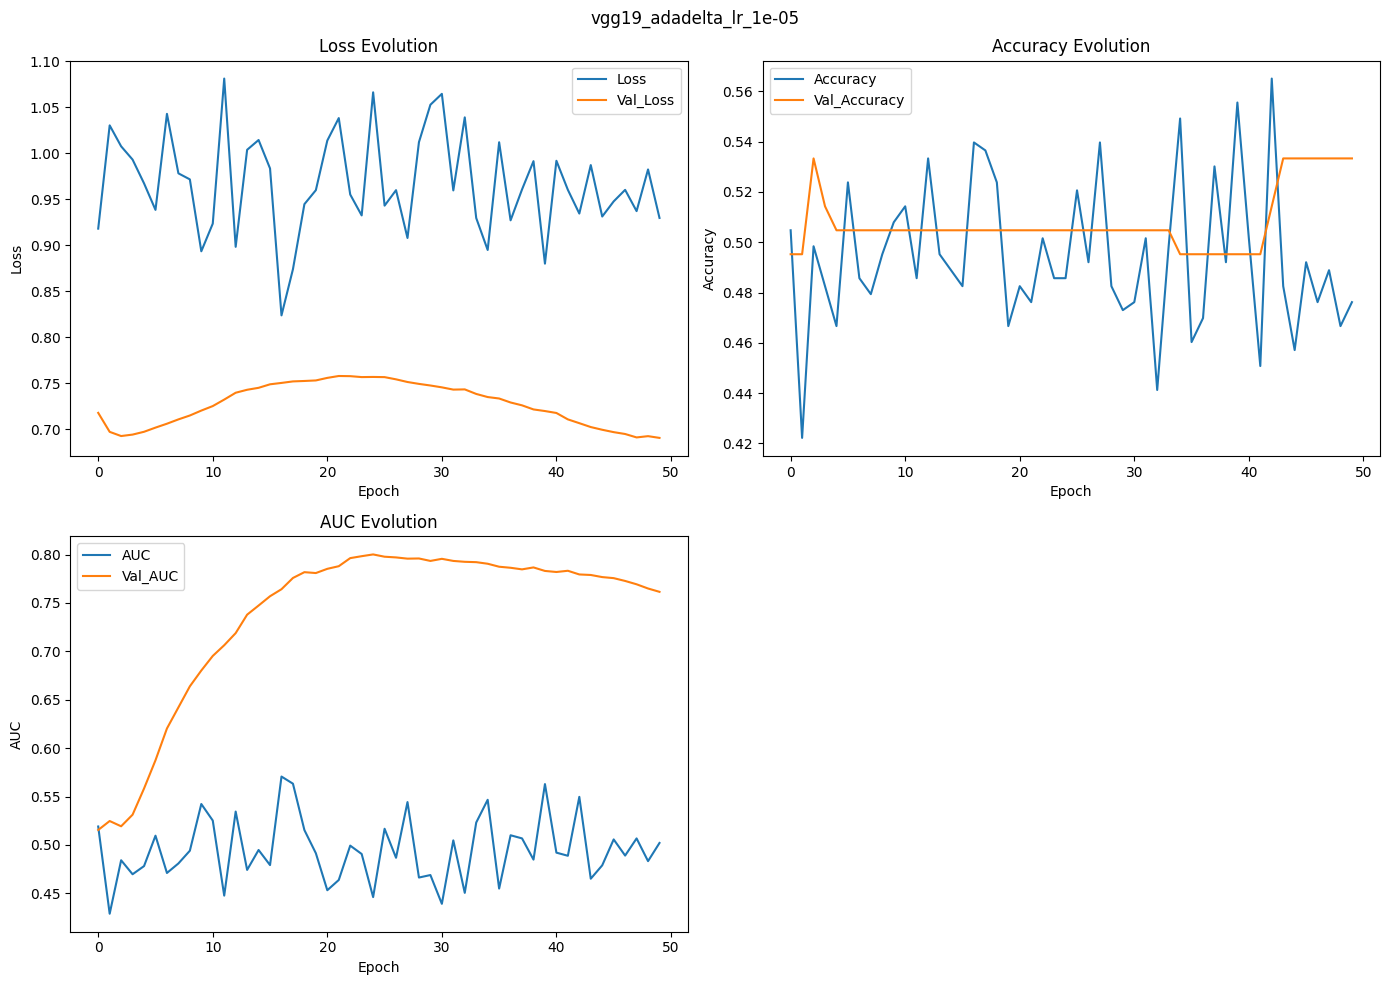

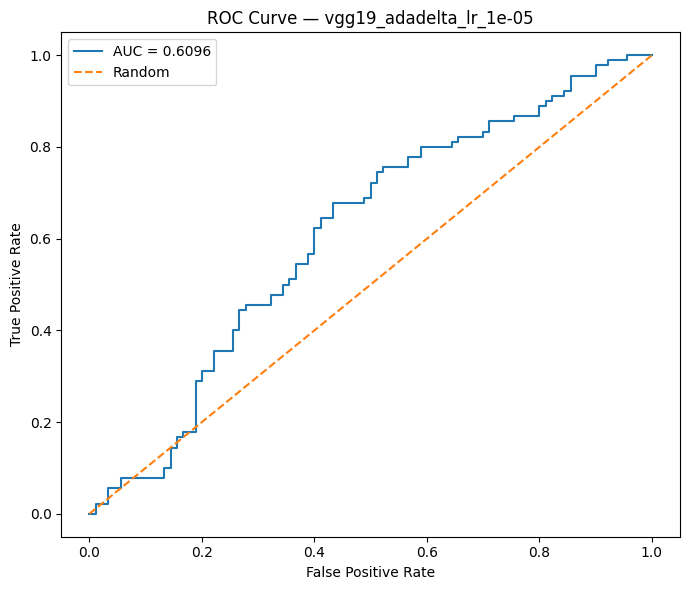

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,9,81
Actual With Disease,4,86


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,vgg19,adadelta,0.00001,0.527778,0.51497,0.955556,0.1,0.669261,0.60963,9,81,4,86,outputs_vgg19\plots\vgg19_adadelta_lr_1e-05_hi...,outputs_vgg19\plots\vgg19_adadelta_lr_1e-05_ro...,outputs_vgg19\reports\vgg19_adadelta_lr_1e-05_...,outputs_vgg19\confusion_matrices\vgg19_adadelt...


,precision,recall,f1-score,support
Without Disease,0.692308,0.100000,0.174757,90.000000
With Disease,0.514970,0.955556,0.669261,90.000000
accuracy,0.527778,0.527778,0.527778,0.527778
macro avg,0.603639,0.527778,0.422009,180.000000
weighted avg,0.603639,0.527778,0.422009,180.000000


Incomplete or missing run, will run: vgg19_adadelta_lr_1e-06
Missing: outputs_vgg19\plots\vgg19_adadelta_lr_1e-06_history.png
Missing: outputs_vgg19\plots\vgg19_adadelta_lr_1e-06_roc.png
Missing: outputs_vgg19\reports\vgg19_adadelta_lr_1e-06_classification_report.csv
Missing: outputs_vgg19\confusion_matrices\vgg19_adadelta_lr_1e-06_confusion_matrix.csv

Running: vgg19_adadelta_lr_1e-06
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 44s 4s/step - accuracy: 0.5683 - auc: 0.5741 - loss: 0.8612 - precision: 0.5671 - recall: 0.5886 - val_accuracy: 0.5048 - val_auc: 0.3217 - val_loss: 0.7314 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 38s 4s/step - accuracy: 0.5238 - auc: 0.5077 - loss: 0.9982 - precision: 0.5233 - recall: 0.5696 - val_accuracy: 0.5048 - val_auc: 0.3253 - val_loss: 0.7235 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 39s 4s/step - accuracy: 0.5016 - auc: 0.5151 - loss: 0.9505 - precision: 0.50

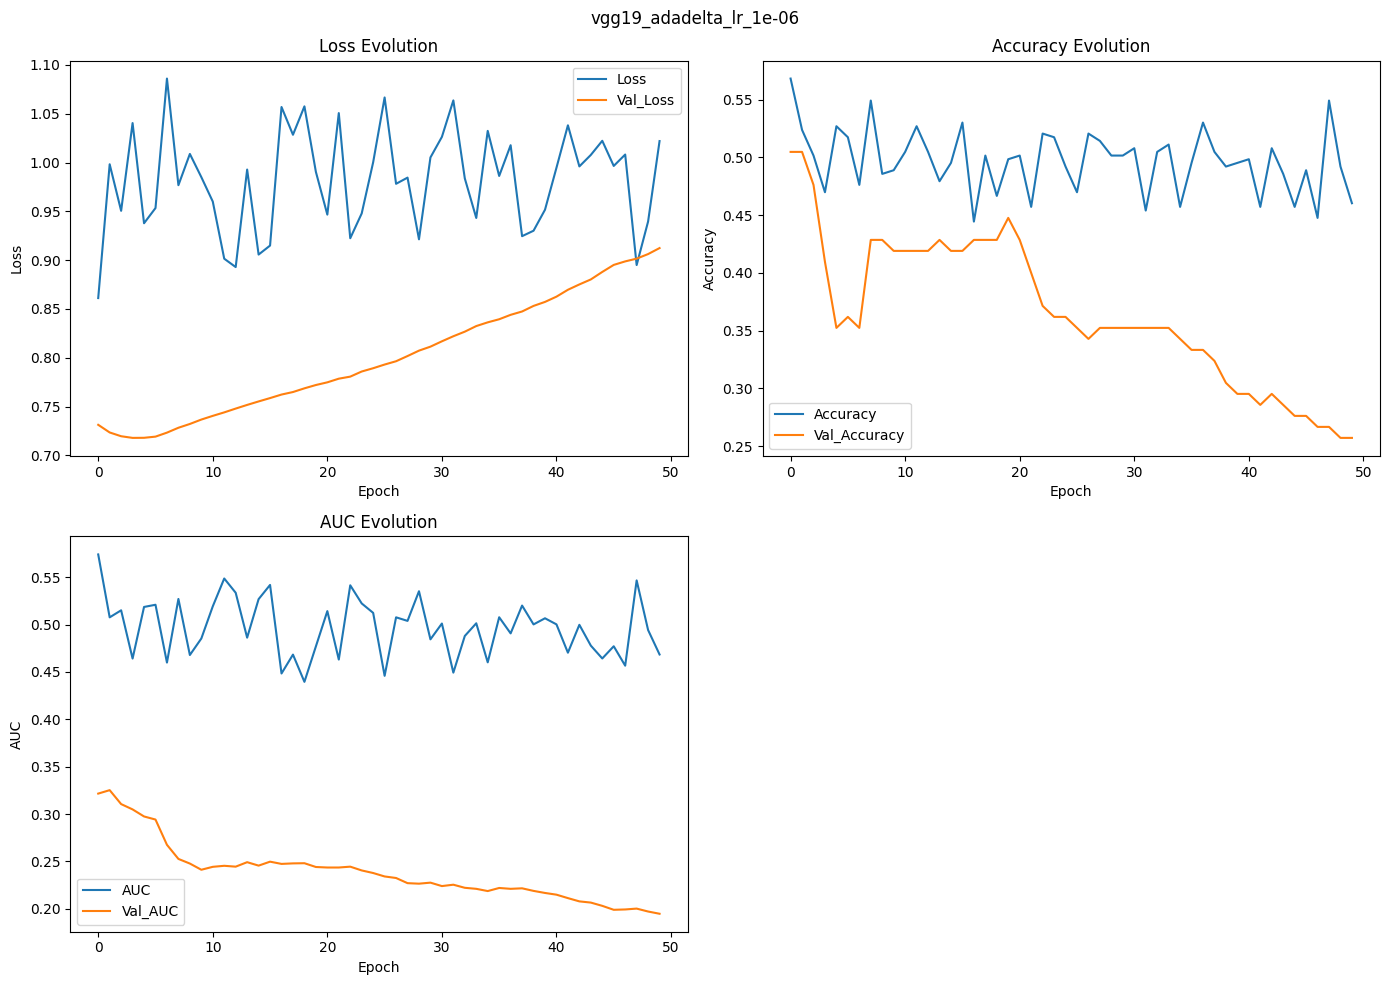

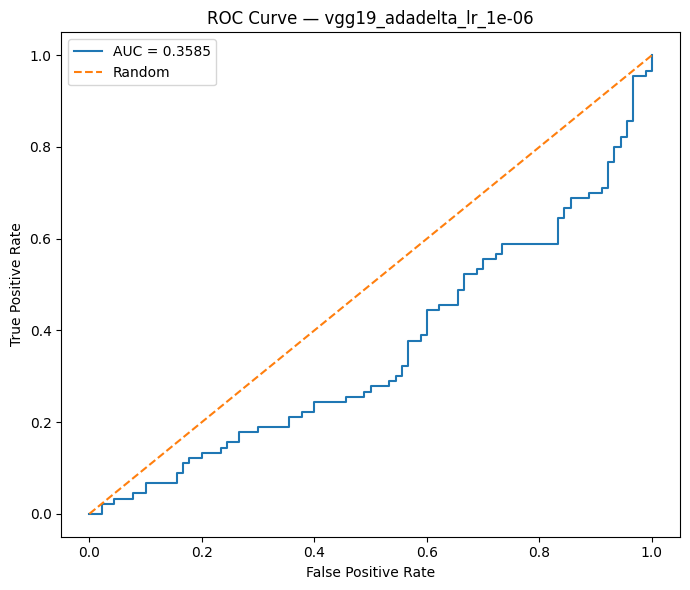

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,40,50
Actual With Disease,63,27


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,vgg19,adadelta,0.000001,0.372222,0.350649,0.3,0.444444,0.323353,0.358519,40,50,63,27,outputs_vgg19\plots\vgg19_adadelta_lr_1e-06_hi...,outputs_vgg19\plots\vgg19_adadelta_lr_1e-06_ro...,outputs_vgg19\reports\vgg19_adadelta_lr_1e-06_...,outputs_vgg19\confusion_matrices\vgg19_adadelt...


,precision,recall,f1-score,support
Without Disease,0.388350,0.444444,0.414508,90.000000
With Disease,0.350649,0.300000,0.323353,90.000000
accuracy,0.372222,0.372222,0.372222,0.372222
macro avg,0.369499,0.372222,0.368931,180.000000
weighted avg,0.369499,0.372222,0.368931,180.000000


Incomplete or missing run, will run: vgg19_sgd_lr_0p0001
Missing: outputs_vgg19\plots\vgg19_sgd_lr_0p0001_history.png
Missing: outputs_vgg19\plots\vgg19_sgd_lr_0p0001_roc.png
Missing: outputs_vgg19\reports\vgg19_sgd_lr_0p0001_classification_report.csv
Missing: outputs_vgg19\confusion_matrices\vgg19_sgd_lr_0p0001_confusion_matrix.csv

Running: vgg19_sgd_lr_0p0001
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 42s 4s/step - accuracy: 0.4603 - auc: 0.4695 - loss: 1.0367 - precision: 0.4600 - recall: 0.4367 - val_accuracy: 0.4952 - val_auc: 0.6845 - val_loss: 0.7529 - val_precision: 0.4952 - val_recall: 1.0000
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 42s 4s/step - accuracy: 0.5460 - auc: 0.5591 - loss: 0.8950 - precision: 0.5503 - recall: 0.5190 - val_accuracy: 0.4952 - val_auc: 0.6860 - val_loss: 0.7348 - val_precision: 0.4952 - val_recall: 1.0000
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 38s 4s/step - accuracy: 0.5333 - auc: 0.4921 - loss: 1.0088 - precision: 0.5350 - recall: 0.5316 - val_accuracy: 0.49

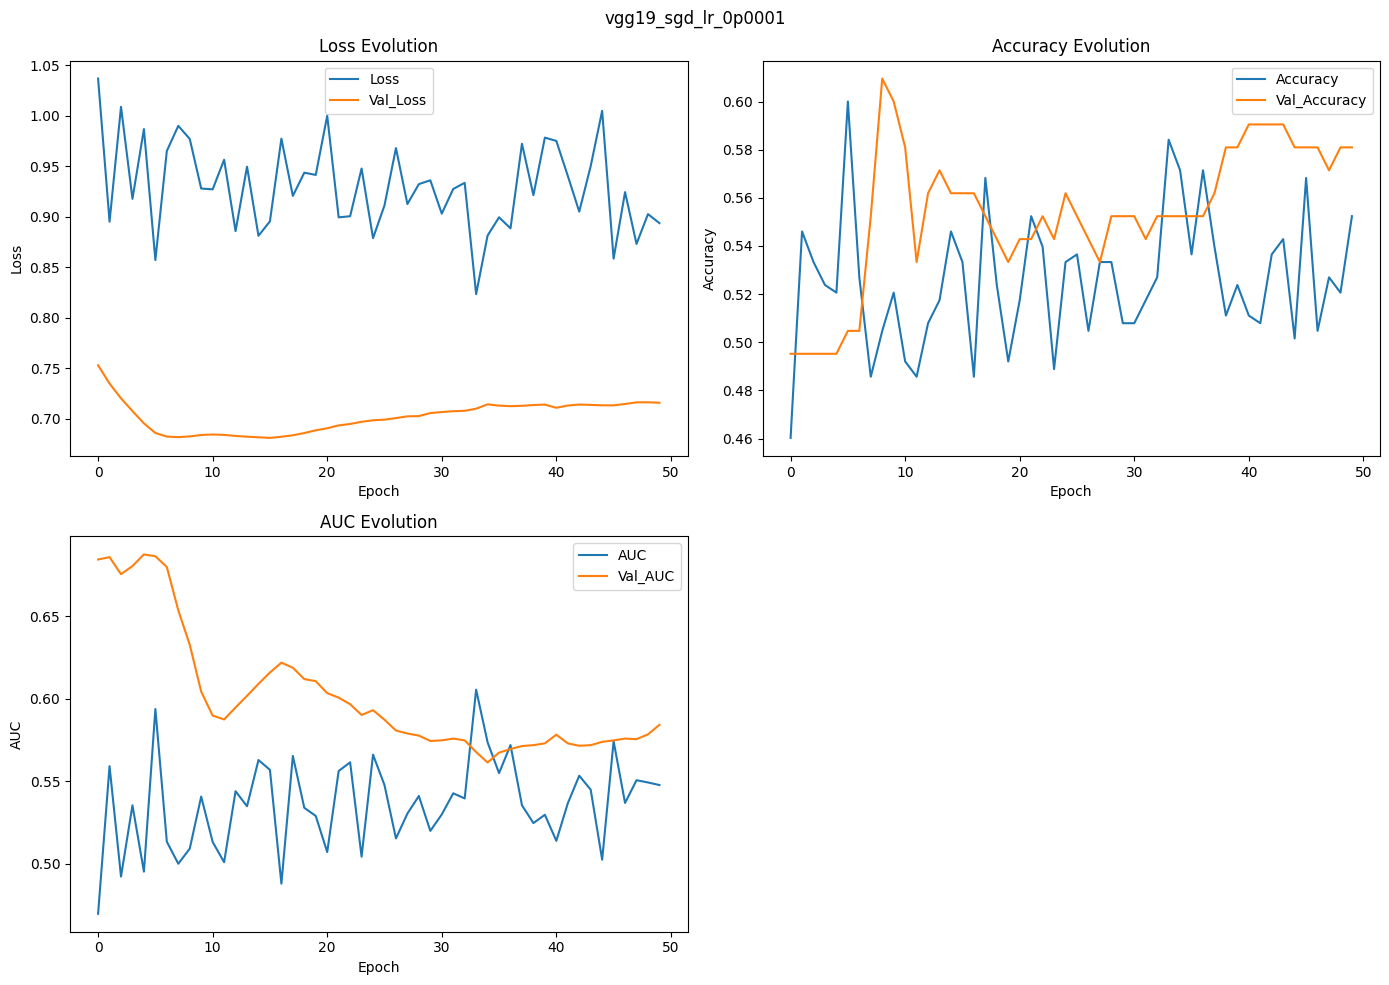

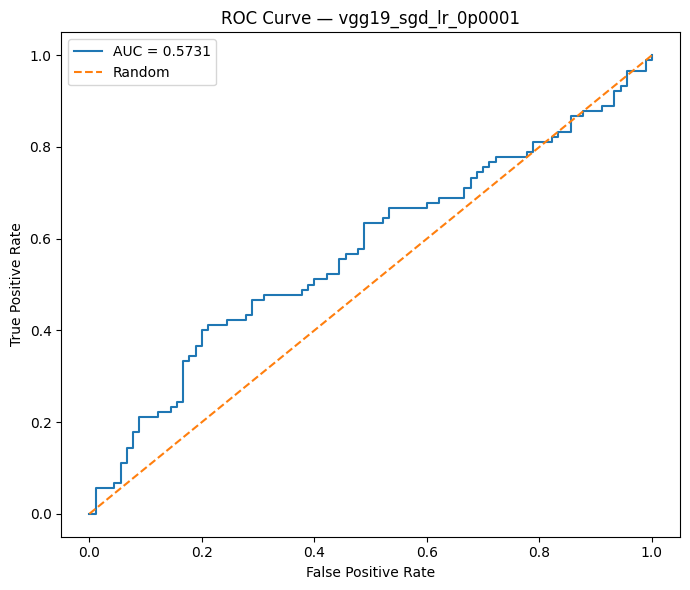

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,14,76
Actual With Disease,15,75


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,vgg19,sgd,0.0001,0.494444,0.496689,0.833333,0.155556,0.622407,0.573086,14,76,15,75,outputs_vgg19\plots\vgg19_sgd_lr_0p0001_histor...,outputs_vgg19\plots\vgg19_sgd_lr_0p0001_roc.png,outputs_vgg19\reports\vgg19_sgd_lr_0p0001_clas...,outputs_vgg19\confusion_matrices\vgg19_sgd_lr_...


,precision,recall,f1-score,support
Without Disease,0.482759,0.155556,0.235294,90.000000
With Disease,0.496689,0.833333,0.622407,90.000000
accuracy,0.494444,0.494444,0.494444,0.494444
macro avg,0.489724,0.494444,0.428850,180.000000
weighted avg,0.489724,0.494444,0.428850,180.000000


Incomplete or missing run, will run: vgg19_sgd_lr_1e-05
Missing: outputs_vgg19\plots\vgg19_sgd_lr_1e-05_history.png
Missing: outputs_vgg19\plots\vgg19_sgd_lr_1e-05_roc.png
Missing: outputs_vgg19\reports\vgg19_sgd_lr_1e-05_classification_report.csv
Missing: outputs_vgg19\confusion_matrices\vgg19_sgd_lr_1e-05_confusion_matrix.csv

Running: vgg19_sgd_lr_1e-05
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 44s 4s/step - accuracy: 0.4857 - auc: 0.5002 - loss: 0.9836 - precision: 0.4873 - recall: 0.4873 - val_accuracy: 0.5048 - val_auc: 0.6038 - val_loss: 0.6971 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 42s 4s/step - accuracy: 0.4825 - auc: 0.4746 - loss: 1.0200 - precision: 0.4847 - recall: 0.5000 - val_accuracy: 0.5048 - val_auc: 0.6265 - val_loss: 0.6935 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 38s 4s/step - accuracy: 0.4698 - auc: 0.4697 - loss: 1.0274 - precision: 0.4724 - recall: 0.4873 - val_accu

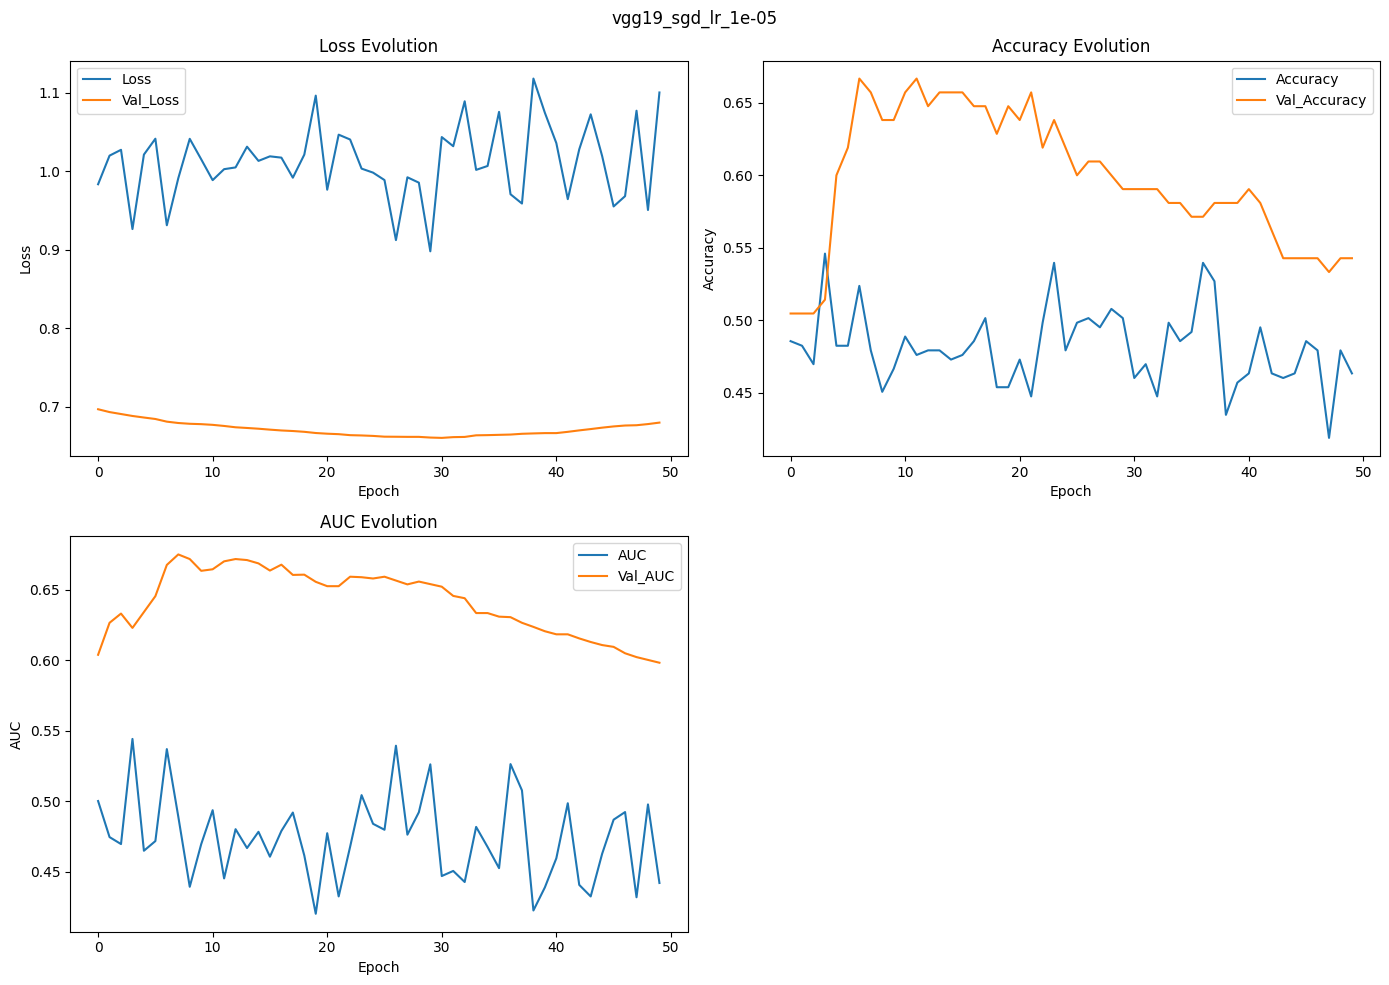

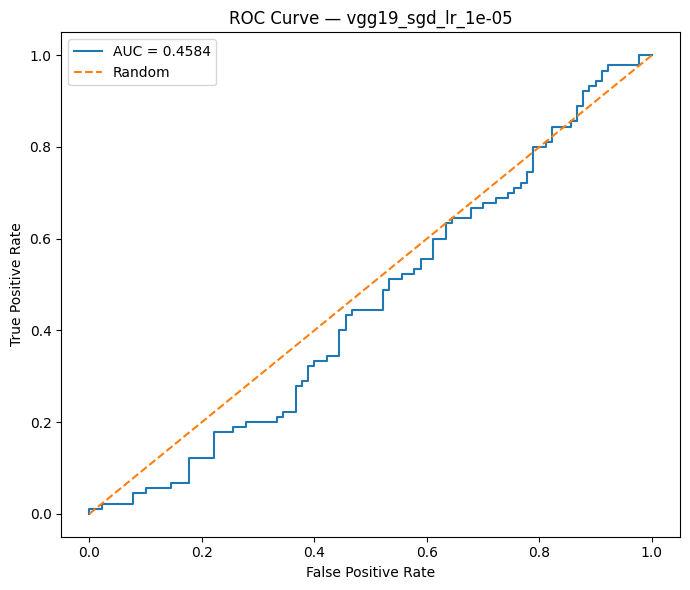

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,43,47
Actual With Disease,48,42


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,vgg19,sgd,0.00001,0.472222,0.47191,0.466667,0.477778,0.469274,0.458395,43,47,48,42,outputs_vgg19\plots\vgg19_sgd_lr_1e-05_history...,outputs_vgg19\plots\vgg19_sgd_lr_1e-05_roc.png,outputs_vgg19\reports\vgg19_sgd_lr_1e-05_class...,outputs_vgg19\confusion_matrices\vgg19_sgd_lr_...


,precision,recall,f1-score,support
Without Disease,0.472527,0.477778,0.475138,90.000000
With Disease,0.471910,0.466667,0.469274,90.000000
accuracy,0.472222,0.472222,0.472222,0.472222
macro avg,0.472219,0.472222,0.472206,180.000000
weighted avg,0.472219,0.472222,0.472206,180.000000


Incomplete or missing run, will run: vgg19_sgd_lr_1e-06
Missing: outputs_vgg19\plots\vgg19_sgd_lr_1e-06_history.png
Missing: outputs_vgg19\plots\vgg19_sgd_lr_1e-06_roc.png
Missing: outputs_vgg19\reports\vgg19_sgd_lr_1e-06_classification_report.csv
Missing: outputs_vgg19\confusion_matrices\vgg19_sgd_lr_1e-06_confusion_matrix.csv

Running: vgg19_sgd_lr_1e-06
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 42s 4s/step - accuracy: 0.4889 - auc: 0.4952 - loss: 1.0397 - precision: 0.4901 - recall: 0.4684 - val_accuracy: 0.4762 - val_auc: 0.5024 - val_loss: 0.6928 - val_precision: 0.4835 - val_recall: 0.8462
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 39s 4s/step - accuracy: 0.4794 - auc: 0.4941 - loss: 1.0285 - precision: 0.4812 - recall: 0.4873 - val_accuracy: 0.4381 - val_auc: 0.4653 - val_loss: 0.6951 - val_precision: 0.4521 - val_recall: 0.6346
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 45s 5s/step - accuracy: 0.5111 - auc: 0.5598 - loss: 0.8946 - precision: 0.5127 - recall: 0.5127 - val_accuracy: 0.3810 - v

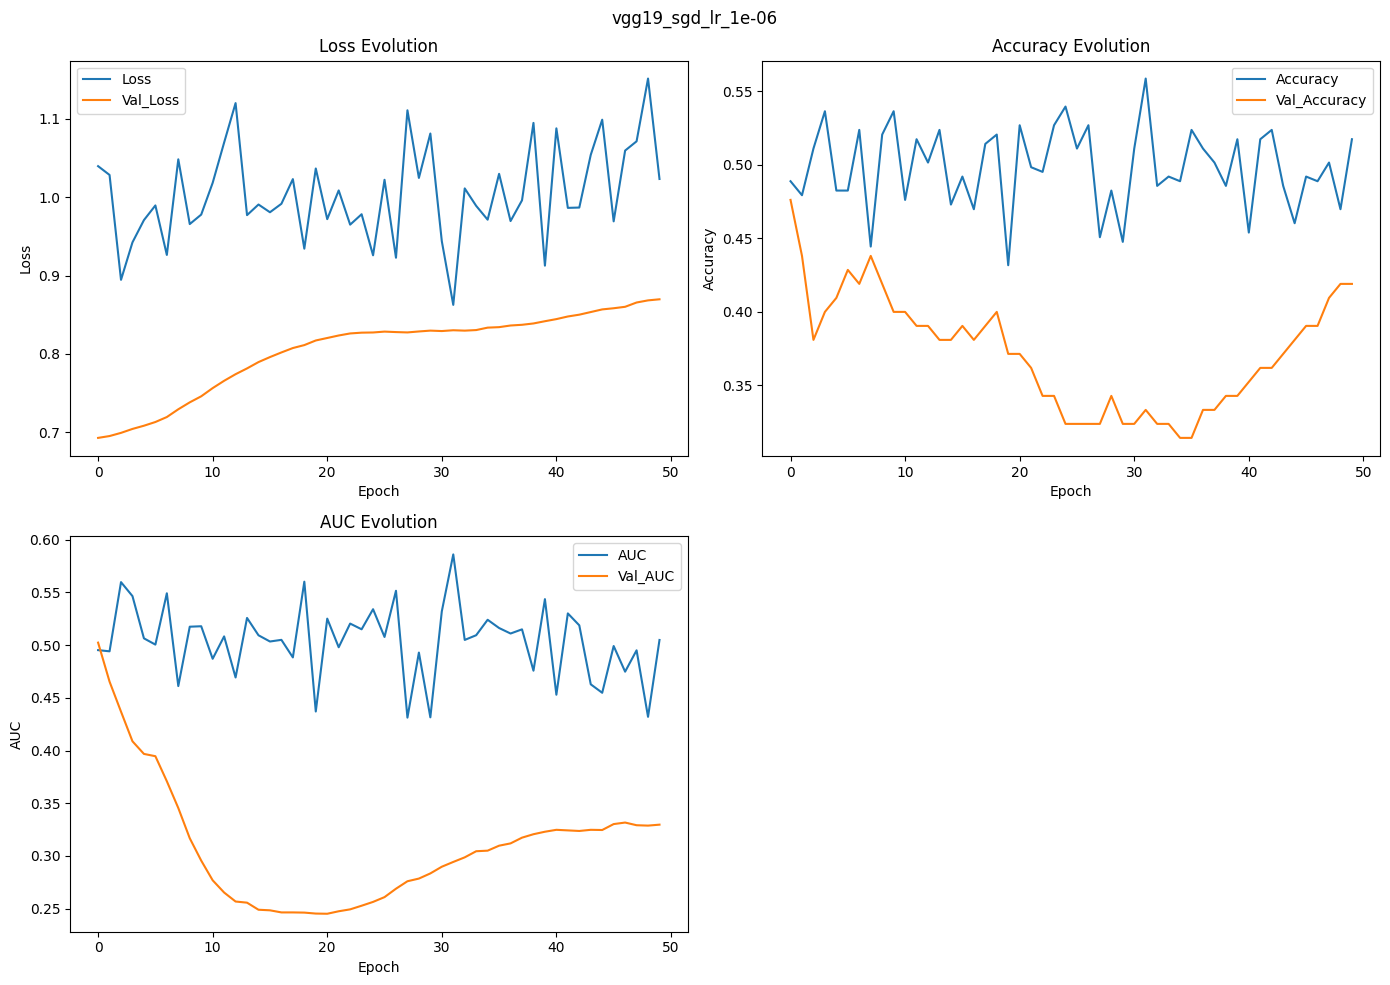

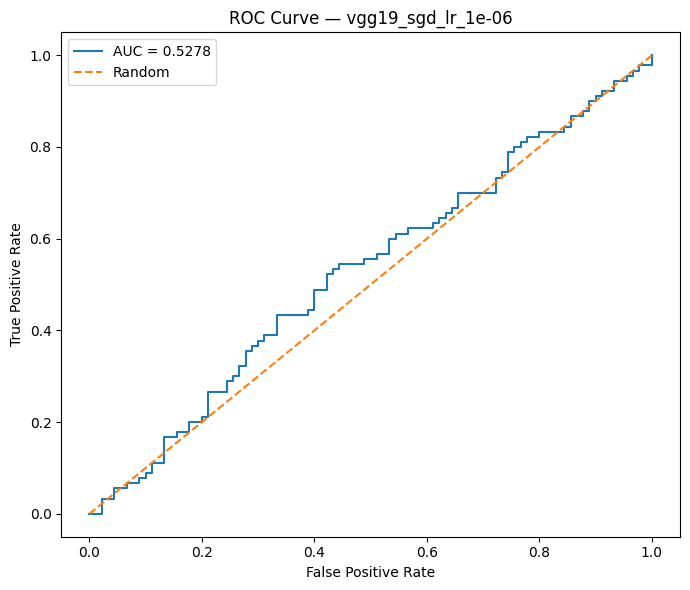

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,31,59
Actual With Disease,29,61


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,vgg19,sgd,0.000001,0.511111,0.508333,0.677778,0.344444,0.580952,0.527778,31,59,29,61,outputs_vgg19\plots\vgg19_sgd_lr_1e-06_history...,outputs_vgg19\plots\vgg19_sgd_lr_1e-06_roc.png,outputs_vgg19\reports\vgg19_sgd_lr_1e-06_class...,outputs_vgg19\confusion_matrices\vgg19_sgd_lr_...


,precision,recall,f1-score,support
Without Disease,0.516667,0.344444,0.413333,90.000000
With Disease,0.508333,0.677778,0.580952,90.000000
accuracy,0.511111,0.511111,0.511111,0.511111
macro avg,0.512500,0.511111,0.497143,180.000000
weighted avg,0.512500,0.511111,0.497143,180.000000


Incomplete or missing run, will run: vgg19_rmsprop_lr_0p0001
Missing: outputs_vgg19\plots\vgg19_rmsprop_lr_0p0001_history.png
Missing: outputs_vgg19\plots\vgg19_rmsprop_lr_0p0001_roc.png
Missing: outputs_vgg19\reports\vgg19_rmsprop_lr_0p0001_classification_report.csv
Missing: outputs_vgg19\confusion_matrices\vgg19_rmsprop_lr_0p0001_confusion_matrix.csv

Running: vgg19_rmsprop_lr_0p0001
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 42s 4s/step - accuracy: 0.4984 - auc: 0.5102 - loss: 0.9035 - precision: 0.5000 - recall: 0.5000 - val_accuracy: 0.4000 - val_auc: 0.3775 - val_loss: 0.7007 - val_precision: 0.4267 - val_recall: 0.6154
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 40s 4s/step - accuracy: 0.5492 - auc: 0.5471 - loss: 0.8326 - precision: 0.5513 - recall: 0.5443 - val_accuracy: 0.4095 - val_auc: 0.3540 - val_loss: 0.7022 - val_precision: 0.4390 - val_recall: 0.6923
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 42s 4s/step - accuracy: 0.5460 - auc: 0.5562 - loss: 0.8553 - precision: 0.5497 - recall: 0.5

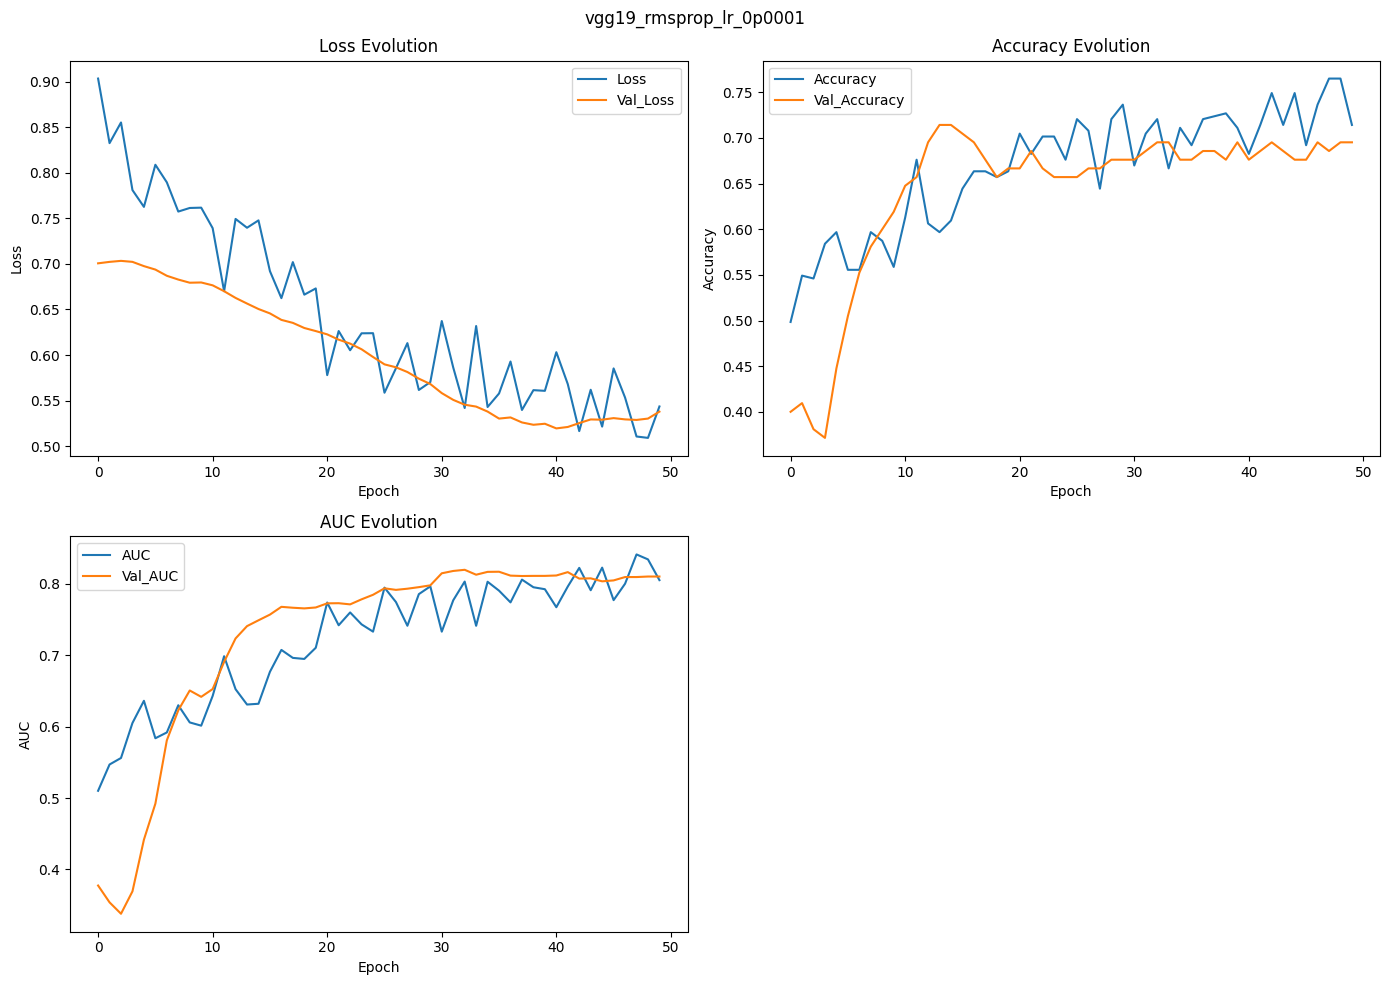

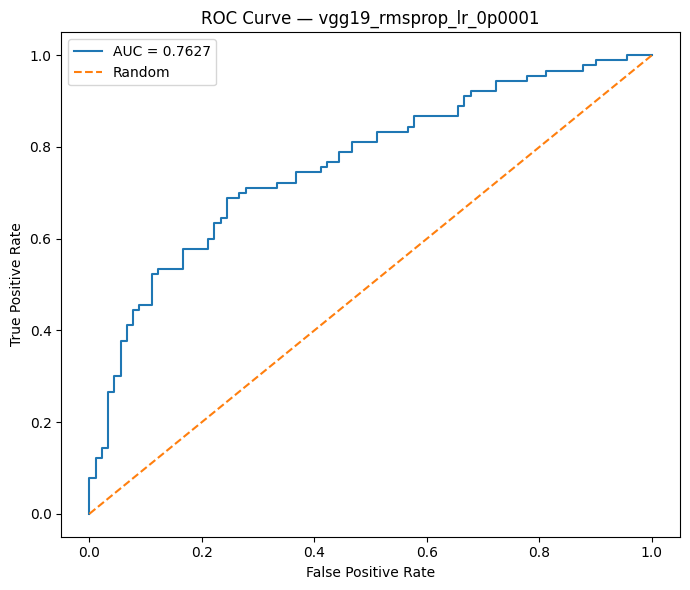

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,68,22
Actual With Disease,32,58


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,vgg19,rmsprop,0.0001,0.7,0.725,0.644444,0.755556,0.682353,0.762716,68,22,32,58,outputs_vgg19\plots\vgg19_rmsprop_lr_0p0001_hi...,outputs_vgg19\plots\vgg19_rmsprop_lr_0p0001_ro...,outputs_vgg19\reports\vgg19_rmsprop_lr_0p0001_...,outputs_vgg19\confusion_matrices\vgg19_rmsprop...


,precision,recall,f1-score,support
Without Disease,0.6800,0.755556,0.715789,90.0
With Disease,0.7250,0.644444,0.682353,90.0
accuracy,0.7000,0.700000,0.700000,0.7
macro avg,0.7025,0.700000,0.699071,180.0
weighted avg,0.7025,0.700000,0.699071,180.0


Incomplete or missing run, will run: vgg19_rmsprop_lr_1e-05
Missing: outputs_vgg19\plots\vgg19_rmsprop_lr_1e-05_history.png
Missing: outputs_vgg19\plots\vgg19_rmsprop_lr_1e-05_roc.png
Missing: outputs_vgg19\reports\vgg19_rmsprop_lr_1e-05_classification_report.csv
Missing: outputs_vgg19\confusion_matrices\vgg19_rmsprop_lr_1e-05_confusion_matrix.csv

Running: vgg19_rmsprop_lr_1e-05
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 44s 4s/step - accuracy: 0.5111 - auc: 0.5185 - loss: 0.9072 - precision: 0.5128 - recall: 0.5063 - val_accuracy: 0.5524 - val_auc: 0.5147 - val_loss: 0.6926 - val_precision: 1.0000 - val_recall: 0.0962
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 38s 4s/step - accuracy: 0.4952 - auc: 0.5017 - loss: 0.9201 - precision: 0.4969 - recall: 0.5063 - val_accuracy: 0.5429 - val_auc: 0.5112 - val_loss: 0.6938 - val_precision: 1.0000 - val_recall: 0.0769
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 38s 4s/step - accuracy: 0.5365 - auc: 0.5365 - loss: 0.8950 - precision: 0.5405 - recall: 0.5063 - 

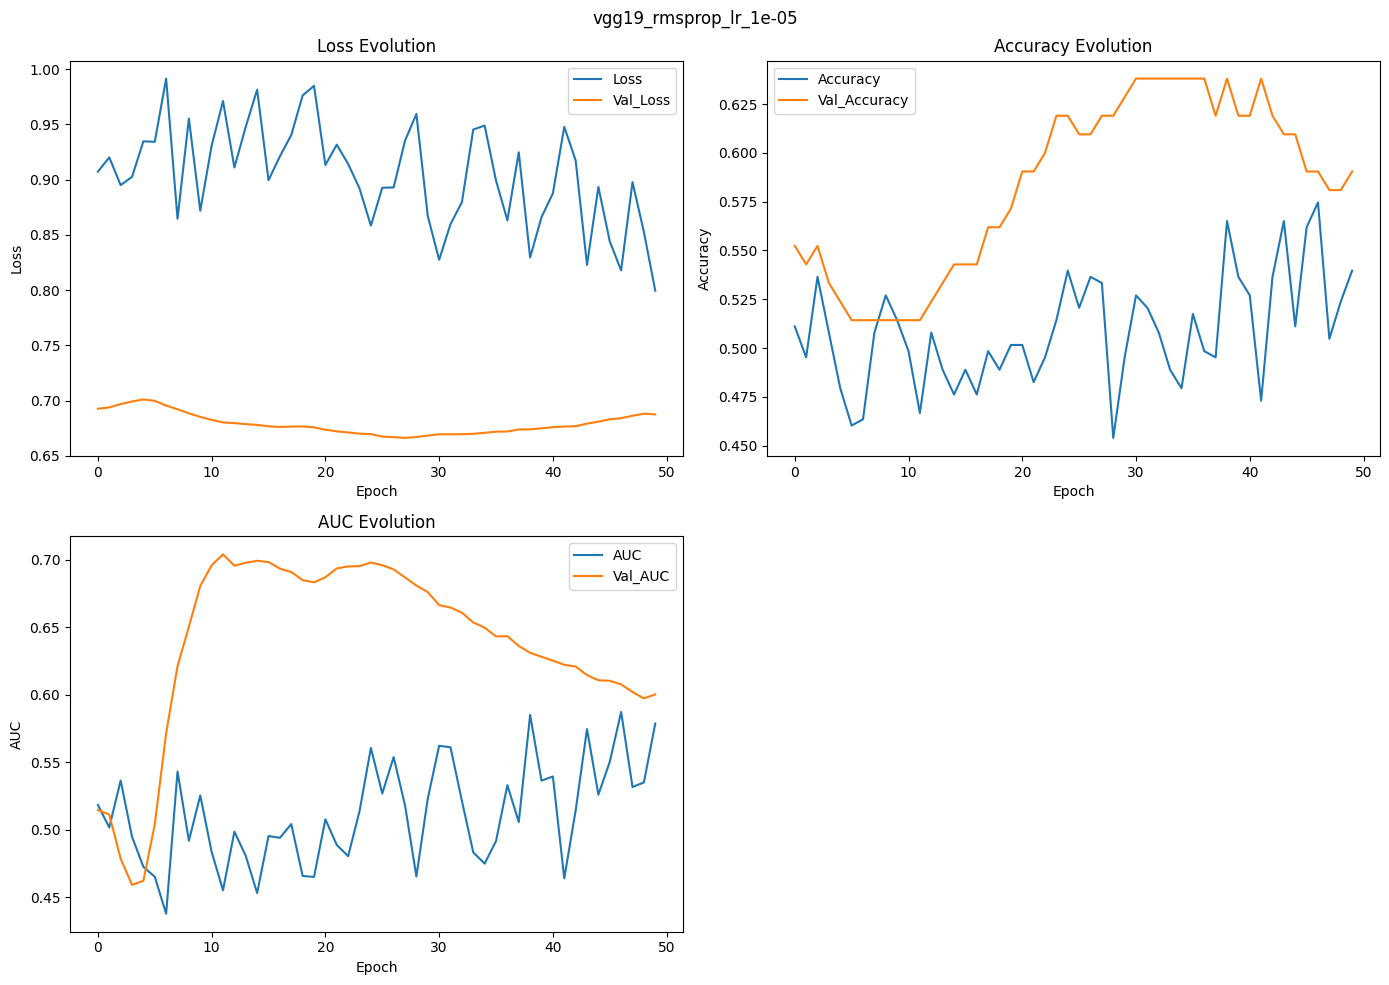

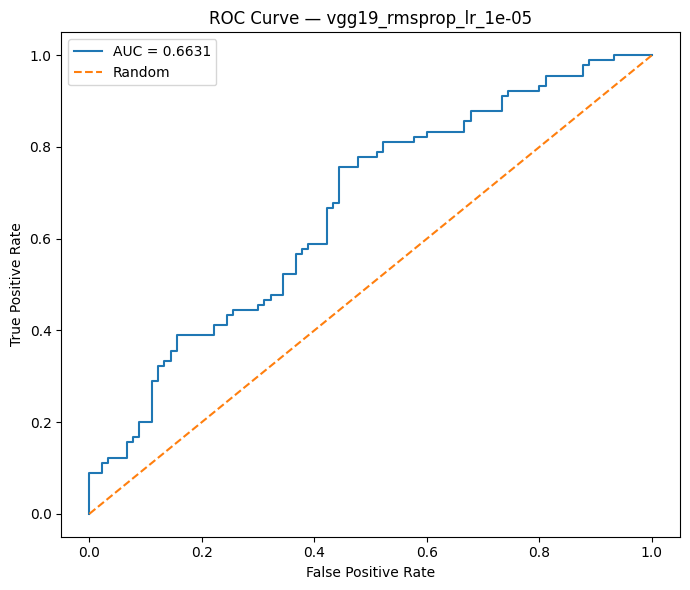

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,38,52
Actual With Disease,17,73


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,vgg19,rmsprop,0.00001,0.616667,0.584,0.811111,0.422222,0.67907,0.663086,38,52,17,73,outputs_vgg19\plots\vgg19_rmsprop_lr_1e-05_his...,outputs_vgg19\plots\vgg19_rmsprop_lr_1e-05_roc...,outputs_vgg19\reports\vgg19_rmsprop_lr_1e-05_c...,outputs_vgg19\confusion_matrices\vgg19_rmsprop...


,precision,recall,f1-score,support
Without Disease,0.690909,0.422222,0.524138,90.000000
With Disease,0.584000,0.811111,0.679070,90.000000
accuracy,0.616667,0.616667,0.616667,0.616667
macro avg,0.637455,0.616667,0.601604,180.000000
weighted avg,0.637455,0.616667,0.601604,180.000000


Incomplete or missing run, will run: vgg19_rmsprop_lr_1e-06
Missing: outputs_vgg19\plots\vgg19_rmsprop_lr_1e-06_history.png
Missing: outputs_vgg19\plots\vgg19_rmsprop_lr_1e-06_roc.png
Missing: outputs_vgg19\reports\vgg19_rmsprop_lr_1e-06_classification_report.csv
Missing: outputs_vgg19\confusion_matrices\vgg19_rmsprop_lr_1e-06_confusion_matrix.csv

Running: vgg19_rmsprop_lr_1e-06
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 47s 5s/step - accuracy: 0.4762 - auc: 0.4904 - loss: 0.9299 - precision: 0.4765 - recall: 0.4494 - val_accuracy: 0.4857 - val_auc: 0.4122 - val_loss: 0.7128 - val_precision: 0.4904 - val_recall: 0.9808
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 39s 4s/step - accuracy: 0.4571 - auc: 0.4649 - loss: 1.0237 - precision: 0.4586 - recall: 0.4557 - val_accuracy: 0.4857 - val_auc: 0.4236 - val_loss: 0.7129 - val_precision: 0.4904 - val_recall: 0.9808
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 38s 4s/step - accuracy: 0.5238 - auc: 0.5214 - loss: 0.8867 - precision: 0.5244 - recall: 0.5443 - 

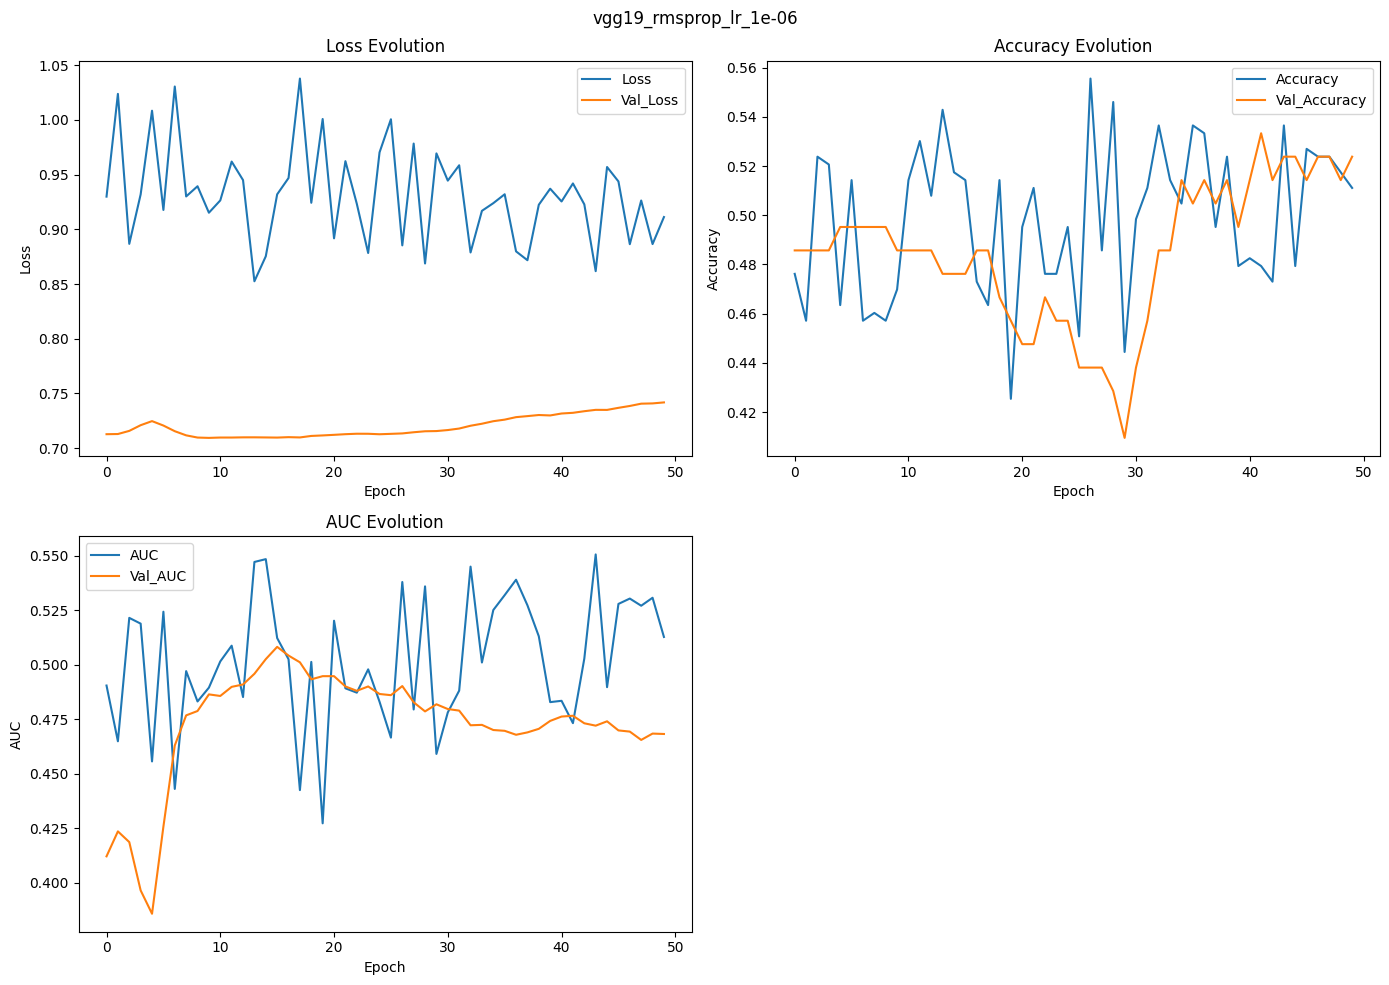

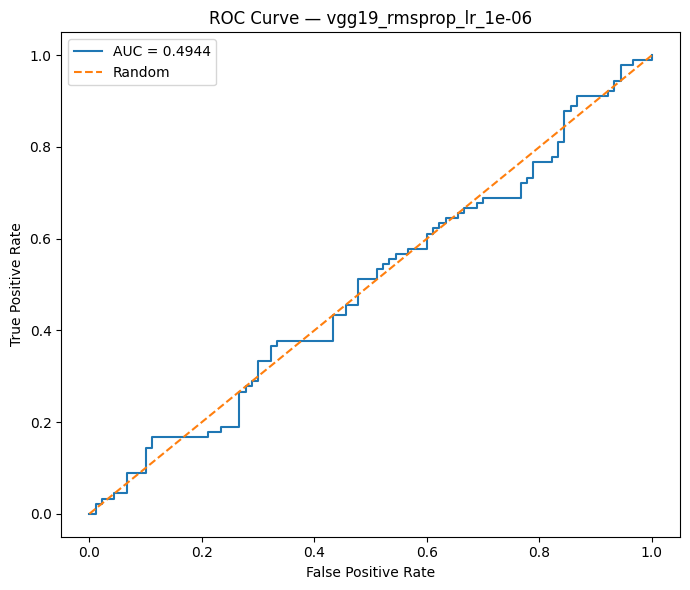

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,57,33
Actual With Disease,56,34


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,vgg19,rmsprop,0.000001,0.505556,0.507463,0.377778,0.633333,0.433121,0.494444,57,33,56,34,outputs_vgg19\plots\vgg19_rmsprop_lr_1e-06_his...,outputs_vgg19\plots\vgg19_rmsprop_lr_1e-06_roc...,outputs_vgg19\reports\vgg19_rmsprop_lr_1e-06_c...,outputs_vgg19\confusion_matrices\vgg19_rmsprop...


,precision,recall,f1-score,support
Without Disease,0.504425,0.633333,0.561576,90.000000
With Disease,0.507463,0.377778,0.433121,90.000000
accuracy,0.505556,0.505556,0.505556,0.505556
macro avg,0.505944,0.505556,0.497349,180.000000
weighted avg,0.505944,0.505556,0.497349,180.000000


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,vgg19,adadelta,0.000010,0.527778,0.514970,0.955556,0.100000,0.669261,0.609630,9,81,4,86,outputs_vgg19\plots\vgg19_adadelta_lr_1e-05_hi...,outputs_vgg19\plots\vgg19_adadelta_lr_1e-05_ro...,outputs_vgg19\reports\vgg19_adadelta_lr_1e-05_...,outputs_vgg19\confusion_matrices\vgg19_adadelt...
1,vgg19,adadelta,0.000001,0.372222,0.350649,0.300000,0.444444,0.323353,0.358519,40,50,63,27,outputs_vgg19\plots\vgg19_adadelta_lr_1e-06_hi...,outputs_vgg19\plots\vgg19_adadelta_lr_1e-06_ro...,outputs_vgg19\reports\vgg19_adadelta_lr_1e-06_...,outputs_vgg19\confusion_matrices\vgg19_adadelt...
2,vgg19,sgd,0.000100,0.494444,0.496689,0.833333,0.155556,0.622407,0.573086,14,76,15,75,outputs_vgg19\plots\vgg19_sgd_lr_0p0001_histor...,outputs_vgg19\plots\vgg19_sgd_lr_0p0001_roc.png,outputs_vgg19\reports\vgg19_sgd_lr_0p0001_clas...,outputs_vgg19\confusion_matrices\vgg19_sgd_lr_...
3,vgg19,sgd,0.000010,0.472222,0.471910,0.466667,0.477778,0.469274,0.458395,43,47,48,42,outputs_vgg19\plots\vgg19_sgd_lr_1e-05_history...,outputs_vgg19\plots\vgg19_sgd_lr_1e-05_roc.png,outputs_vgg19\reports\vgg19_sgd_lr_1e-05_class...,outputs_vgg19\confusion_matrices\vgg19_sgd_lr_...
4,vgg19,sgd,0.000001,0.511111,0.508333,0.677778,0.344444,0.580952,0.527778,31,59,29,61,outputs_vgg19\plots\vgg19_sgd_lr_1e-06_history...,outputs_vgg19\plots\vgg19_sgd_lr_1e-06_roc.png,outputs_vgg19\reports\vgg19_sgd_lr_1e-06_class...,outputs_vgg19\confusion_matrices\vgg19_sgd_lr_...
5,vgg19,rmsprop,0.000100,0.700000,0.725000,0.644444,0.755556,0.682353,0.762716,68,22,32,58,outputs_vgg19\plots\vgg19_rmsprop_lr_0p0001_hi...,outputs_vgg19\plots\vgg19_rmsprop_lr_0p0001_ro...,outputs_vgg19\reports\vgg19_rmsprop_lr_0p0001_...,outputs_vgg19\confusion_matrices\vgg19_rmsprop...
6,vgg19,rmsprop,0.000010,0.616667,0.584000,0.811111,0.422222,0.679070,0.663086,38,52,17,73,outputs_vgg19\plots\vgg19_rmsprop_lr_1e-05_his...,outputs_vgg19\plots\vgg19_rmsprop_lr_1e-05_roc...,outputs_vgg19\reports\vgg19_rmsprop_lr_1e-05_c...,outputs_vgg19\confusion_matrices\vgg19_rmsprop...
7,vgg19,rmsprop,0.000001,0.505556,0.507463,0.377778,0.633333,0.433121,0.494444,57,33,56,34,outputs_vgg19\plots\vgg19_rmsprop_lr_1e-06_his...,outputs_vgg19\plots\vgg19_rmsprop_lr_1e-06_roc...,outputs_vgg19\reports\vgg19_rmsprop_lr_1e-06_c...,outputs_vgg19\confusion_matrices\vgg19_rmsprop...


Incomplete or missing run, will run: efficientnetb3_adam_lr_0p0001
Missing: outputs_efficientnetb3\plots\efficientnetb3_adam_lr_0p0001_history.png
Missing: outputs_efficientnetb3\plots\efficientnetb3_adam_lr_0p0001_roc.png
Missing: outputs_efficientnetb3\reports\efficientnetb3_adam_lr_0p0001_classification_report.csv
Missing: outputs_efficientnetb3\confusion_matrices\efficientnetb3_adam_lr_0p0001_confusion_matrix.csv

Running: efficientnetb3_adam_lr_0p0001
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 46s 4s/step - accuracy: 0.5429 - auc: 0.5418 - loss: 0.9435 - precision: 0.5407 - recall: 0.5886 - val_accuracy: 0.6095 - val_auc: 0.6538 - val_loss: 0.6822 - val_precision: 0.6279 - val_recall: 0.5192
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step - accuracy: 0.4952 - auc: 0.4743 - loss: 1.0458 - precision: 0.4970 - recall: 0.5190 - val_accuracy: 0.5048 - val_auc: 0.5751 - val_loss: 0.6908 - val_precision: 0.5000 - val_recall: 0.8846
Epoch 3/

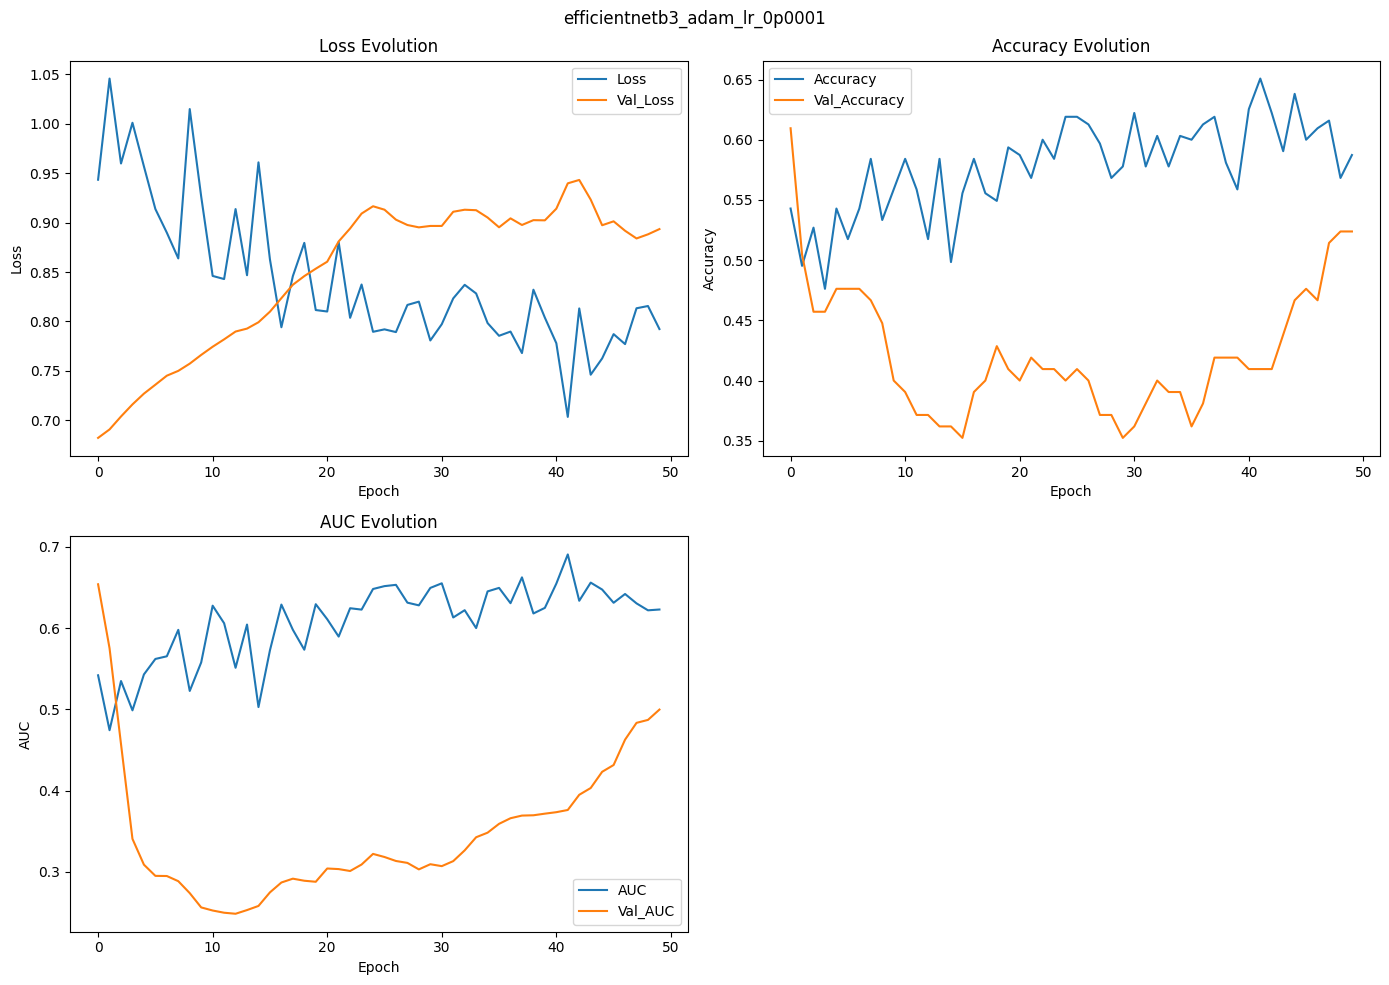

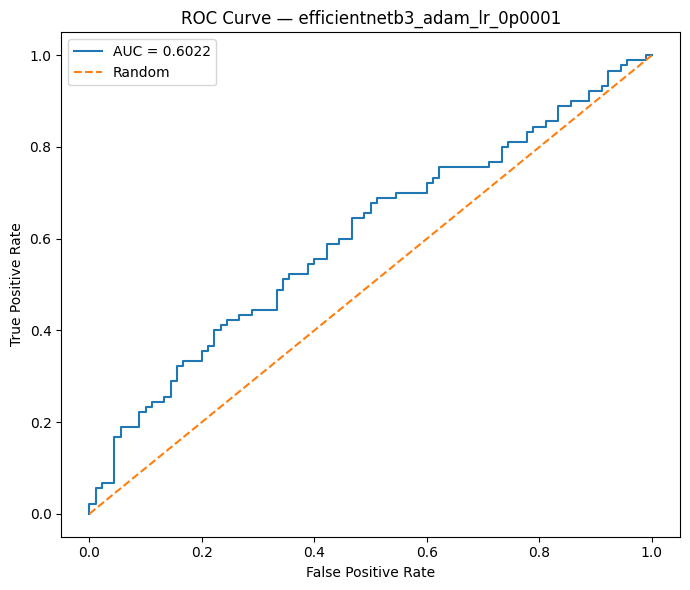

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,68,22
Actual With Disease,53,37


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,efficientnetb3,adam,0.0001,0.583333,0.627119,0.411111,0.755556,0.496644,0.602222,68,22,53,37,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\reports\efficientnetb3_...,outputs_efficientnetb3\confusion_matrices\effi...


,precision,recall,f1-score,support
Without Disease,0.561983,0.755556,0.644550,90.000000
With Disease,0.627119,0.411111,0.496644,90.000000
accuracy,0.583333,0.583333,0.583333,0.583333
macro avg,0.594551,0.583333,0.570597,180.000000
weighted avg,0.594551,0.583333,0.570597,180.000000


Incomplete or missing run, will run: efficientnetb3_adam_lr_1e-05
Missing: outputs_efficientnetb3\plots\efficientnetb3_adam_lr_1e-05_history.png
Missing: outputs_efficientnetb3\plots\efficientnetb3_adam_lr_1e-05_roc.png
Missing: outputs_efficientnetb3\reports\efficientnetb3_adam_lr_1e-05_classification_report.csv
Missing: outputs_efficientnetb3\confusion_matrices\efficientnetb3_adam_lr_1e-05_confusion_matrix.csv

Running: efficientnetb3_adam_lr_1e-05
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 45s 4s/step - accuracy: 0.4349 - auc: 0.3975 - loss: 1.0846 - precision: 0.4390 - recall: 0.4557 - val_accuracy: 0.6952 - val_auc: 0.8456 - val_loss: 0.6620 - val_precision: 0.8846 - val_recall: 0.4423
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - accuracy: 0.4476 - auc: 0.4698 - loss: 0.9353 - precision: 0.4487 - recall: 0.4430 - val_accuracy: 0.7429 - val_auc: 0.8705 - val_loss: 0.6572 - val_precision: 0.8788 - val_recall: 0.5577
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - accuracy: 0.4

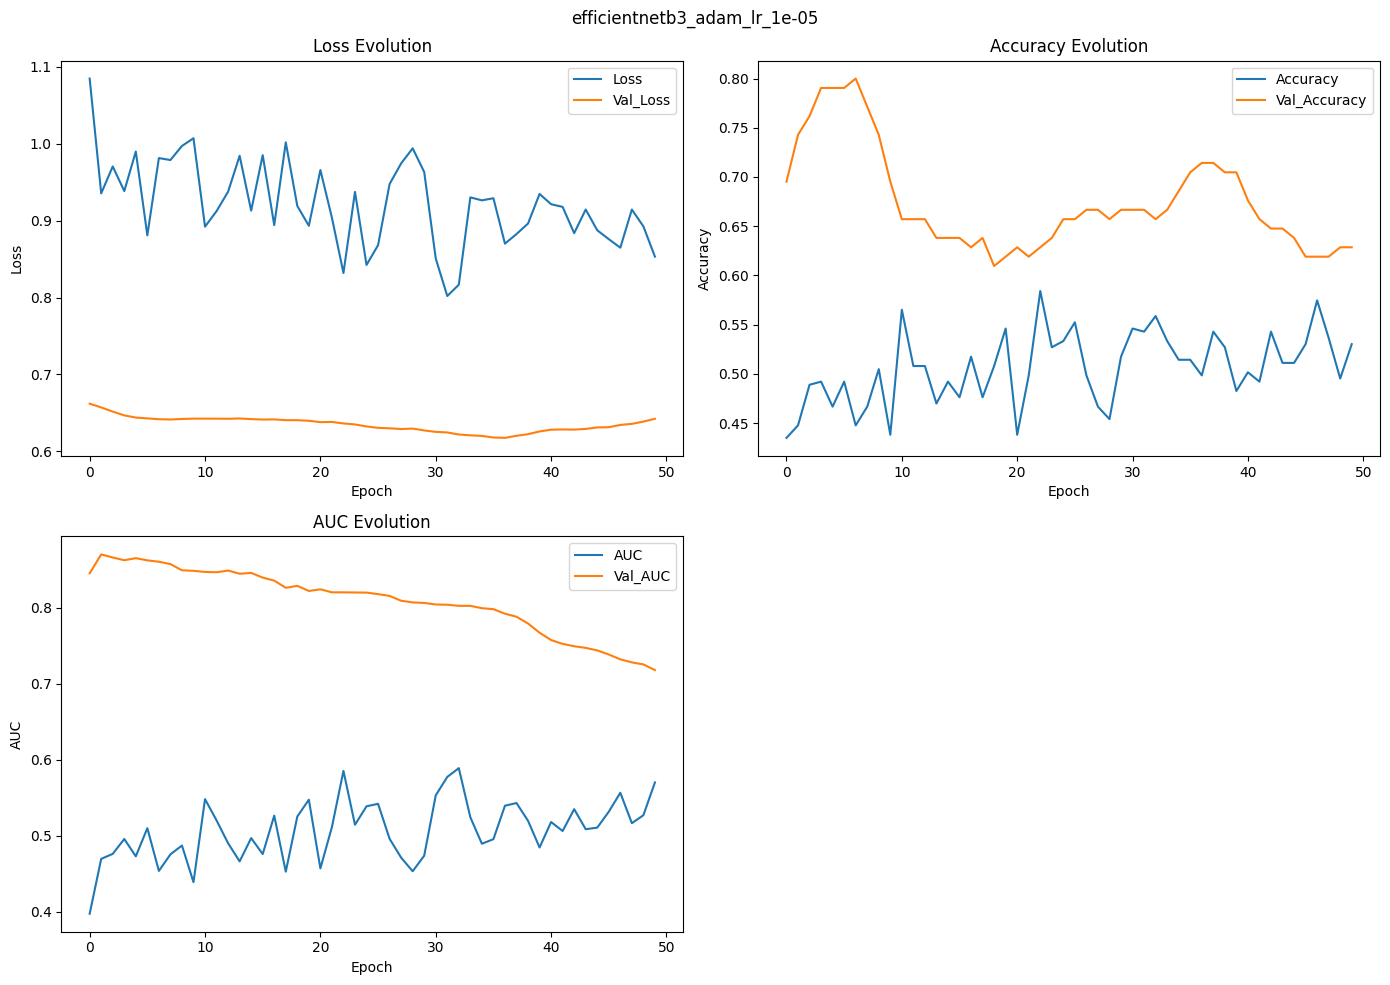

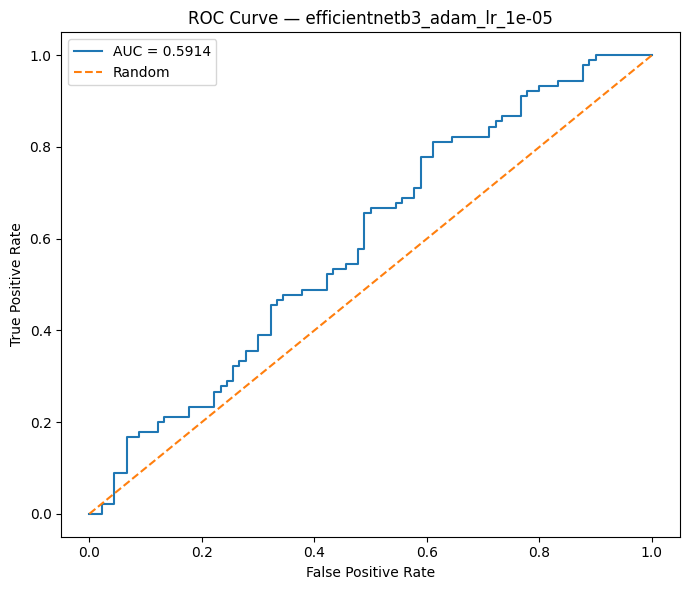

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,63,27
Actual With Disease,56,34


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,efficientnetb3,adam,0.00001,0.538889,0.557377,0.377778,0.7,0.450331,0.591358,63,27,56,34,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\reports\efficientnetb3_...,outputs_efficientnetb3\confusion_matrices\effi...


,precision,recall,f1-score,support
Without Disease,0.529412,0.700000,0.602871,90.000000
With Disease,0.557377,0.377778,0.450331,90.000000
accuracy,0.538889,0.538889,0.538889,0.538889
macro avg,0.543394,0.538889,0.526601,180.000000
weighted avg,0.543394,0.538889,0.526601,180.000000


Incomplete or missing run, will run: efficientnetb3_adam_lr_1e-06
Missing: outputs_efficientnetb3\plots\efficientnetb3_adam_lr_1e-06_history.png
Missing: outputs_efficientnetb3\plots\efficientnetb3_adam_lr_1e-06_roc.png
Missing: outputs_efficientnetb3\reports\efficientnetb3_adam_lr_1e-06_classification_report.csv
Missing: outputs_efficientnetb3\confusion_matrices\efficientnetb3_adam_lr_1e-06_confusion_matrix.csv

Running: efficientnetb3_adam_lr_1e-06
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 45s 4s/step - accuracy: 0.5238 - auc: 0.5345 - loss: 0.9919 - precision: 0.5241 - recall: 0.5506 - val_accuracy: 0.4952 - val_auc: 0.5158 - val_loss: 0.6971 - val_precision: 0.4945 - val_recall: 0.8654
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - accuracy: 0.4667 - auc: 0.4405 - loss: 1.1882 - precision: 0.4699 - recall: 0.4937 - val_accuracy: 0.5048 - val_auc: 0.5136 - val_loss: 0.6977 - val_precision: 0.5000 - val_recall: 0.7885
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - accuracy: 0.4

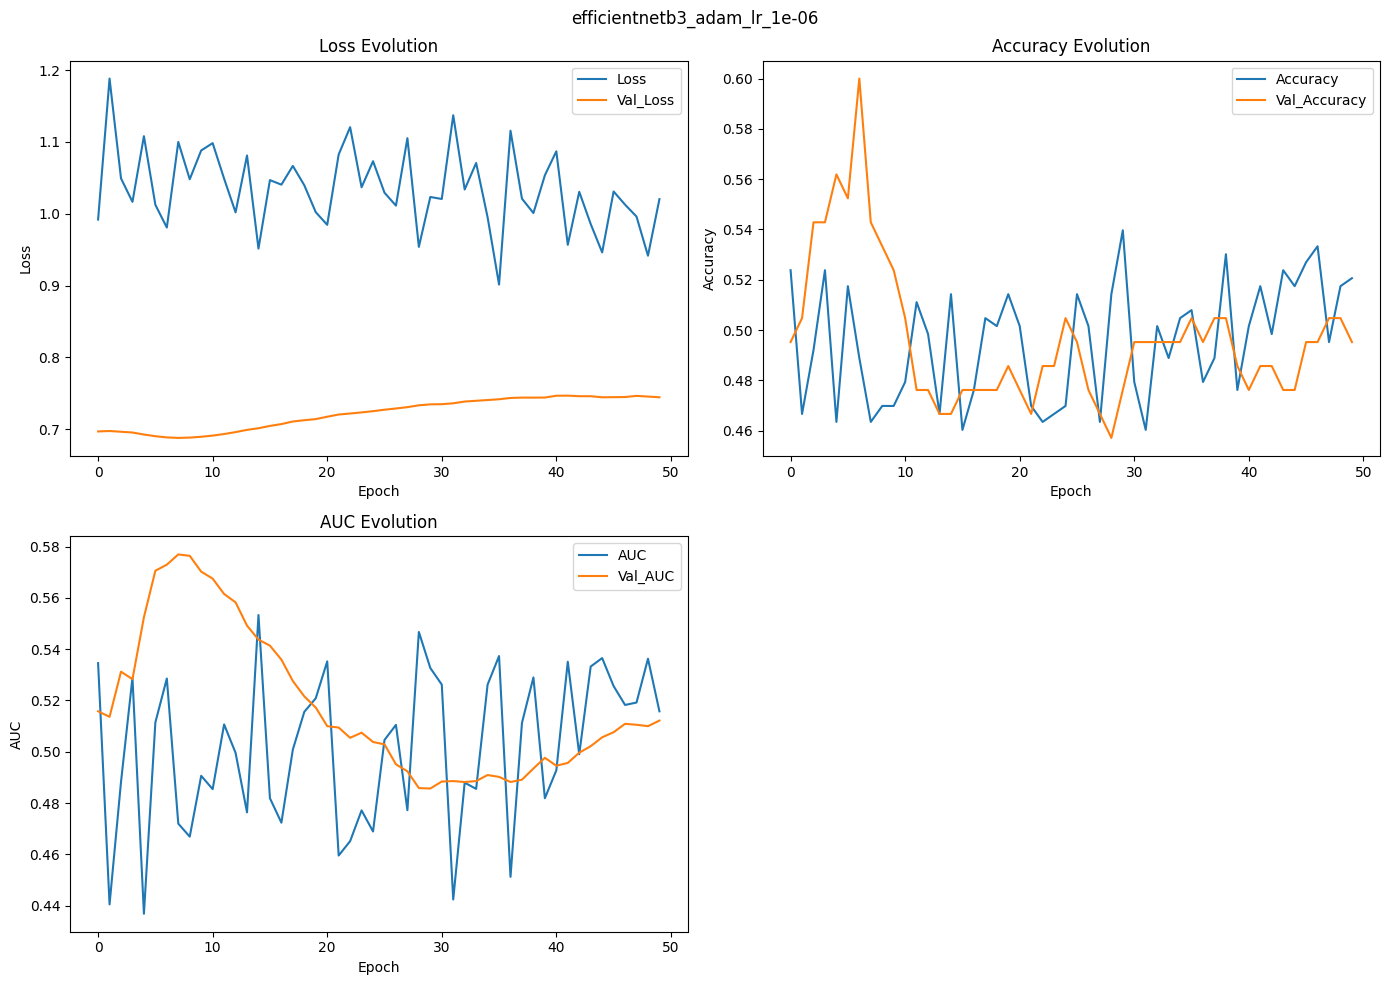

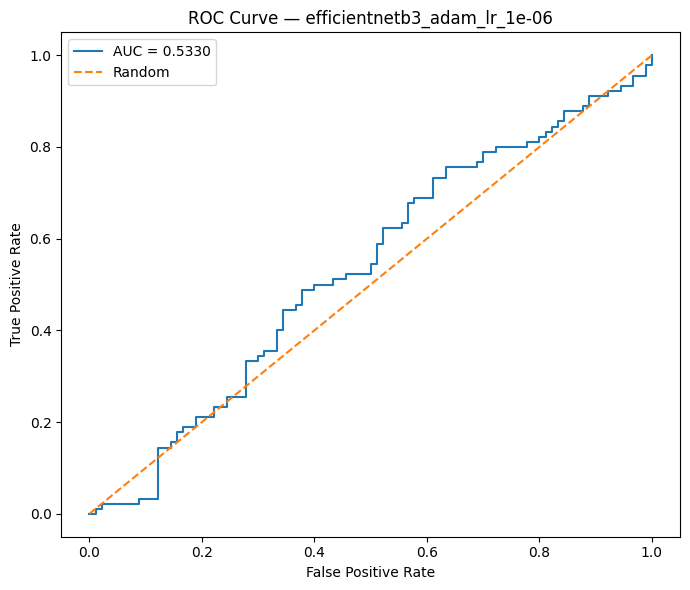

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,36,54
Actual With Disease,28,62


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,efficientnetb3,adam,0.000001,0.544444,0.534483,0.688889,0.4,0.601942,0.532963,36,54,28,62,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\reports\efficientnetb3_...,outputs_efficientnetb3\confusion_matrices\effi...


,precision,recall,f1-score,support
Without Disease,0.562500,0.400000,0.467532,90.000000
With Disease,0.534483,0.688889,0.601942,90.000000
accuracy,0.544444,0.544444,0.544444,0.544444
macro avg,0.548491,0.544444,0.534737,180.000000
weighted avg,0.548491,0.544444,0.534737,180.000000


Incomplete or missing run, will run: efficientnetb3_adagrad_lr_0p0001
Missing: outputs_efficientnetb3\plots\efficientnetb3_adagrad_lr_0p0001_history.png
Missing: outputs_efficientnetb3\plots\efficientnetb3_adagrad_lr_0p0001_roc.png
Missing: outputs_efficientnetb3\reports\efficientnetb3_adagrad_lr_0p0001_classification_report.csv
Missing: outputs_efficientnetb3\confusion_matrices\efficientnetb3_adagrad_lr_0p0001_confusion_matrix.csv

Running: efficientnetb3_adagrad_lr_0p0001
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 45s 4s/step - accuracy: 0.5429 - auc: 0.5650 - loss: 0.9154 - precision: 0.5479 - recall: 0.5063 - val_accuracy: 0.3619 - val_auc: 0.3380 - val_loss: 0.7090 - val_precision: 0.3973 - val_recall: 0.5577
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step - accuracy: 0.5111 - auc: 0.4976 - loss: 1.0064 - precision: 0.5133 - recall: 0.4873 - val_accuracy: 0.4190 - val_auc: 0.3979 - val_loss: 0.7036 - val_precision: 0.4151 - val_recall: 0.4231
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 32s

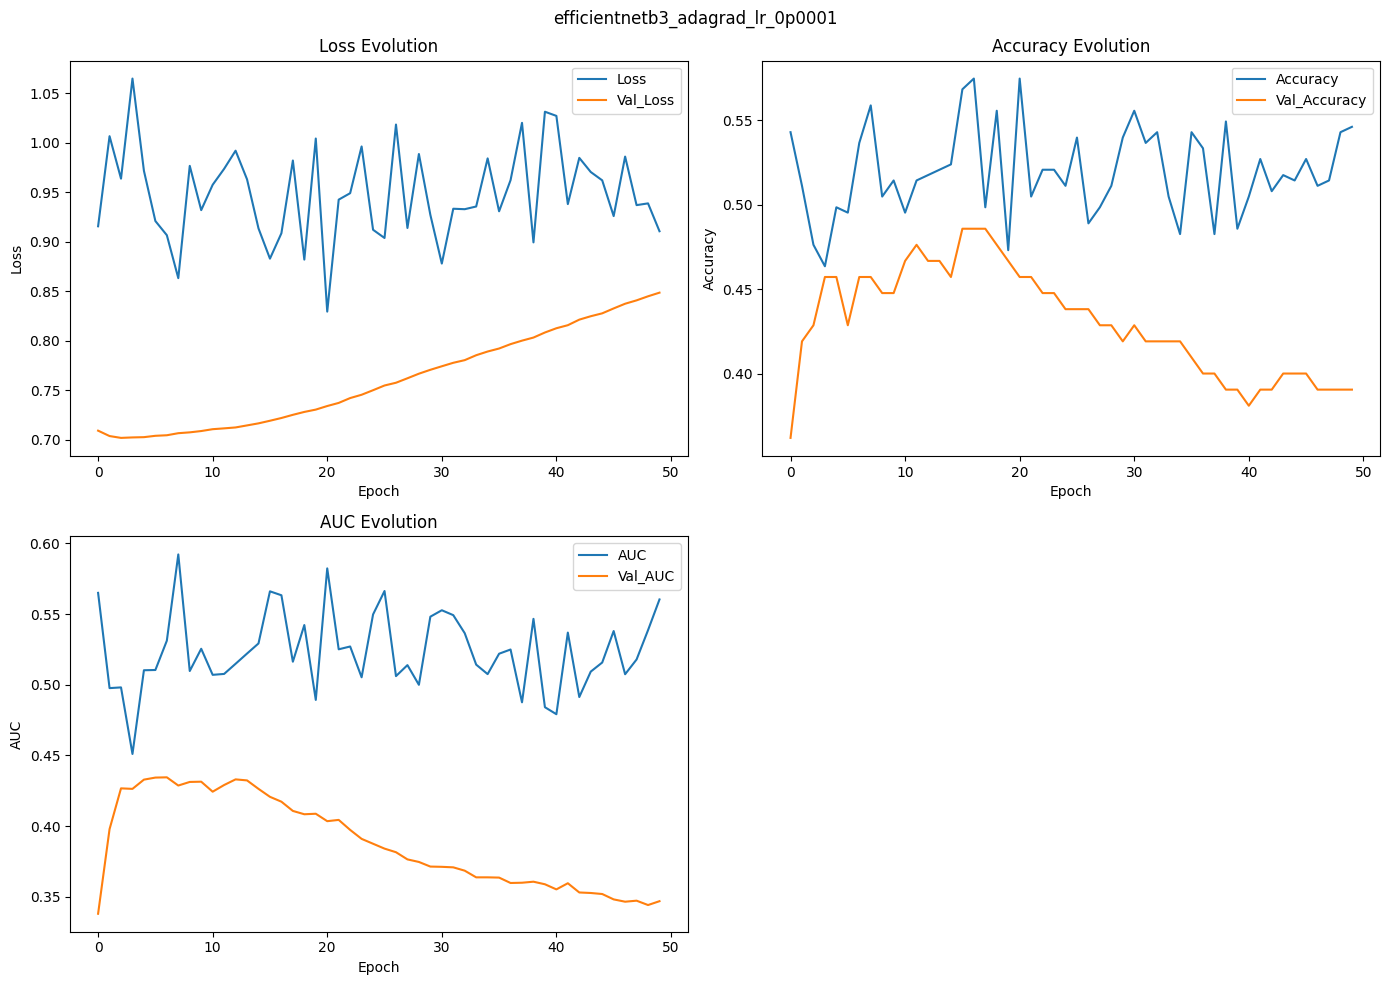

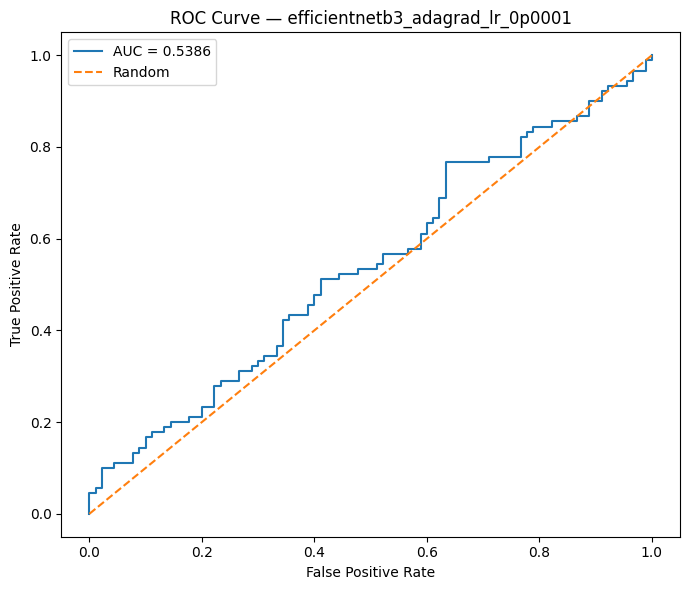

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,33,57
Actual With Disease,22,68


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,efficientnetb3,adagrad,0.0001,0.561111,0.544,0.755556,0.366667,0.632558,0.538642,33,57,22,68,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\reports\efficientnetb3_...,outputs_efficientnetb3\confusion_matrices\effi...


,precision,recall,f1-score,support
Without Disease,0.600000,0.366667,0.455172,90.000000
With Disease,0.544000,0.755556,0.632558,90.000000
accuracy,0.561111,0.561111,0.561111,0.561111
macro avg,0.572000,0.561111,0.543865,180.000000
weighted avg,0.572000,0.561111,0.543865,180.000000


Incomplete or missing run, will run: efficientnetb3_adagrad_lr_1e-05
Missing: outputs_efficientnetb3\plots\efficientnetb3_adagrad_lr_1e-05_history.png
Missing: outputs_efficientnetb3\plots\efficientnetb3_adagrad_lr_1e-05_roc.png
Missing: outputs_efficientnetb3\reports\efficientnetb3_adagrad_lr_1e-05_classification_report.csv
Missing: outputs_efficientnetb3\confusion_matrices\efficientnetb3_adagrad_lr_1e-05_confusion_matrix.csv

Running: efficientnetb3_adagrad_lr_1e-05
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 46s 4s/step - accuracy: 0.5079 - auc: 0.4828 - loss: 0.9833 - precision: 0.5090 - recall: 0.5380 - val_accuracy: 0.5048 - val_auc: 0.5740 - val_loss: 0.6949 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step - accuracy: 0.5175 - auc: 0.5378 - loss: 0.9148 - precision: 0.5185 - recall: 0.5316 - val_accuracy: 0.5048 - val_auc: 0.6050 - val_loss: 0.6905 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/50
10/10 ━━━━━━━━━━━━━━

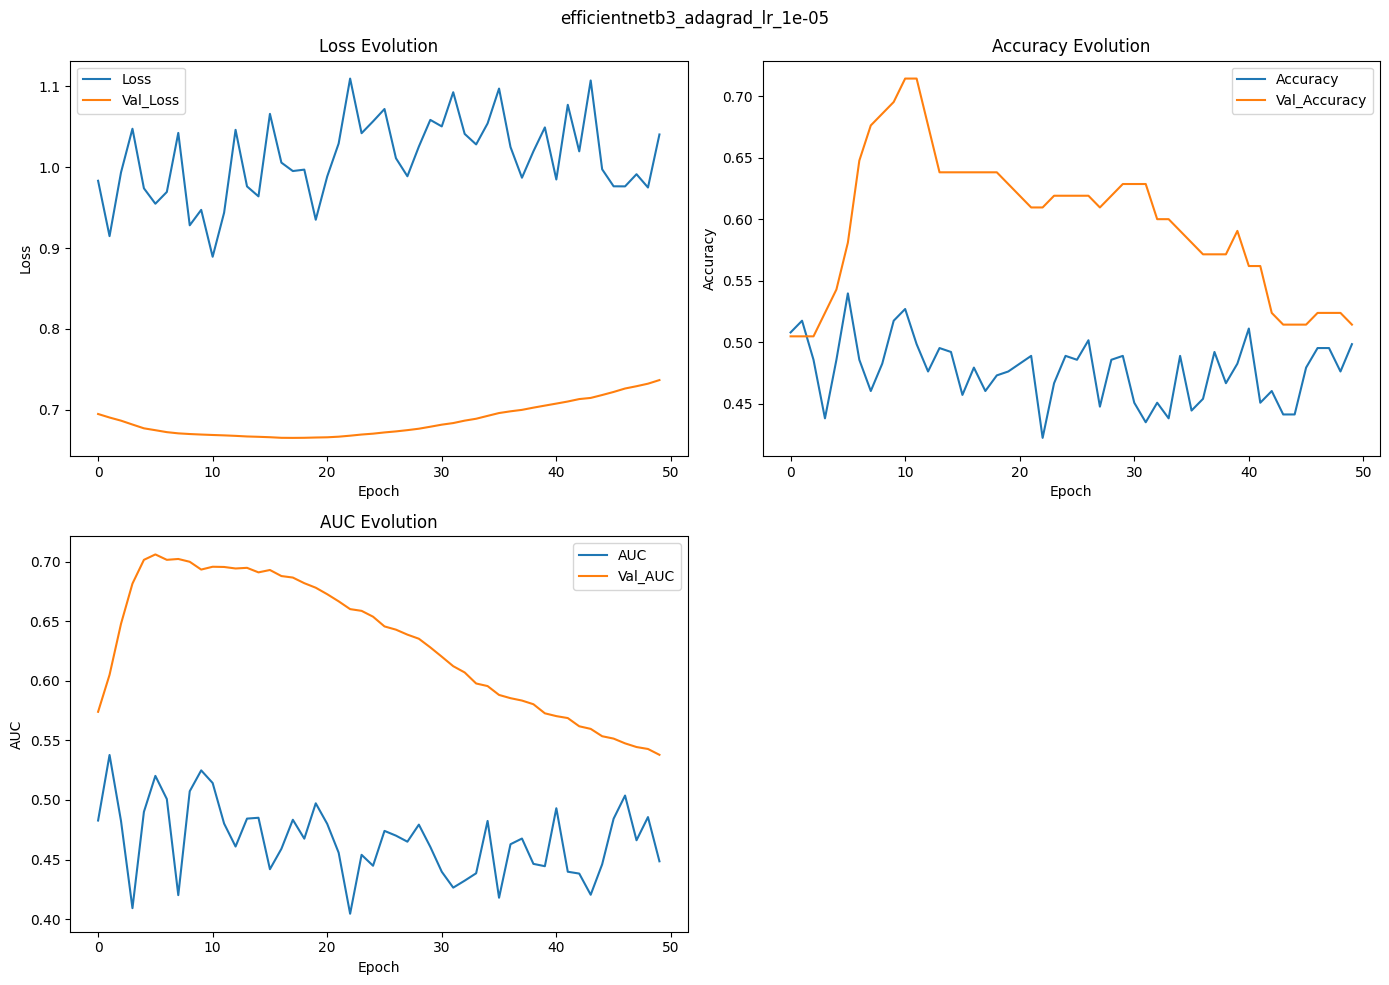

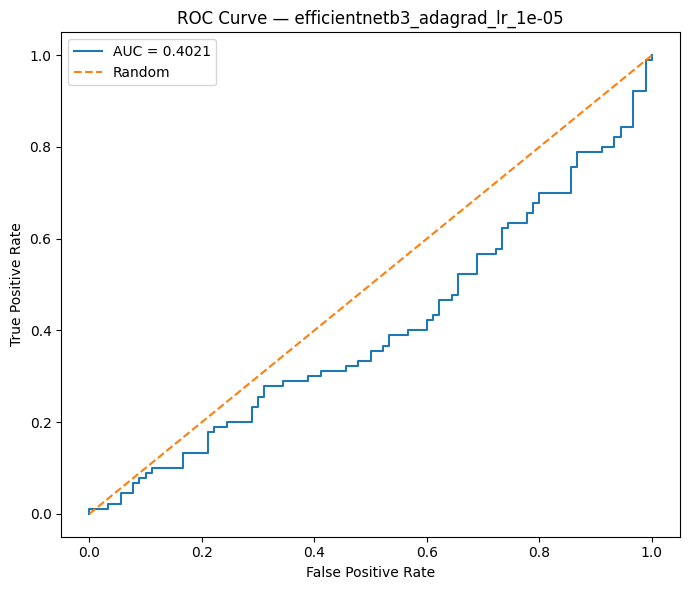

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,70,20
Actual With Disease,73,17


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,efficientnetb3,adagrad,0.00001,0.483333,0.459459,0.188889,0.777778,0.267717,0.402099,70,20,73,17,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\reports\efficientnetb3_...,outputs_efficientnetb3\confusion_matrices\effi...


,precision,recall,f1-score,support
Without Disease,0.489510,0.777778,0.600858,90.000000
With Disease,0.459459,0.188889,0.267717,90.000000
accuracy,0.483333,0.483333,0.483333,0.483333
macro avg,0.474485,0.483333,0.434287,180.000000
weighted avg,0.474485,0.483333,0.434287,180.000000


Incomplete or missing run, will run: efficientnetb3_adagrad_lr_1e-06
Missing: outputs_efficientnetb3\plots\efficientnetb3_adagrad_lr_1e-06_history.png
Missing: outputs_efficientnetb3\plots\efficientnetb3_adagrad_lr_1e-06_roc.png
Missing: outputs_efficientnetb3\reports\efficientnetb3_adagrad_lr_1e-06_classification_report.csv
Missing: outputs_efficientnetb3\confusion_matrices\efficientnetb3_adagrad_lr_1e-06_confusion_matrix.csv

Running: efficientnetb3_adagrad_lr_1e-06
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 46s 4s/step - accuracy: 0.5016 - auc: 0.4881 - loss: 1.0172 - precision: 0.5033 - recall: 0.4873 - val_accuracy: 0.5905 - val_auc: 0.6861 - val_loss: 0.6792 - val_precision: 0.6800 - val_recall: 0.3269
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step - accuracy: 0.5587 - auc: 0.5269 - loss: 0.9776 - precision: 0.5638 - recall: 0.5316 - val_accuracy: 0.6952 - val_auc: 0.6987 - val_loss: 0.6755 - val_precision: 0.7174 - val_recall: 0.6346
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/st

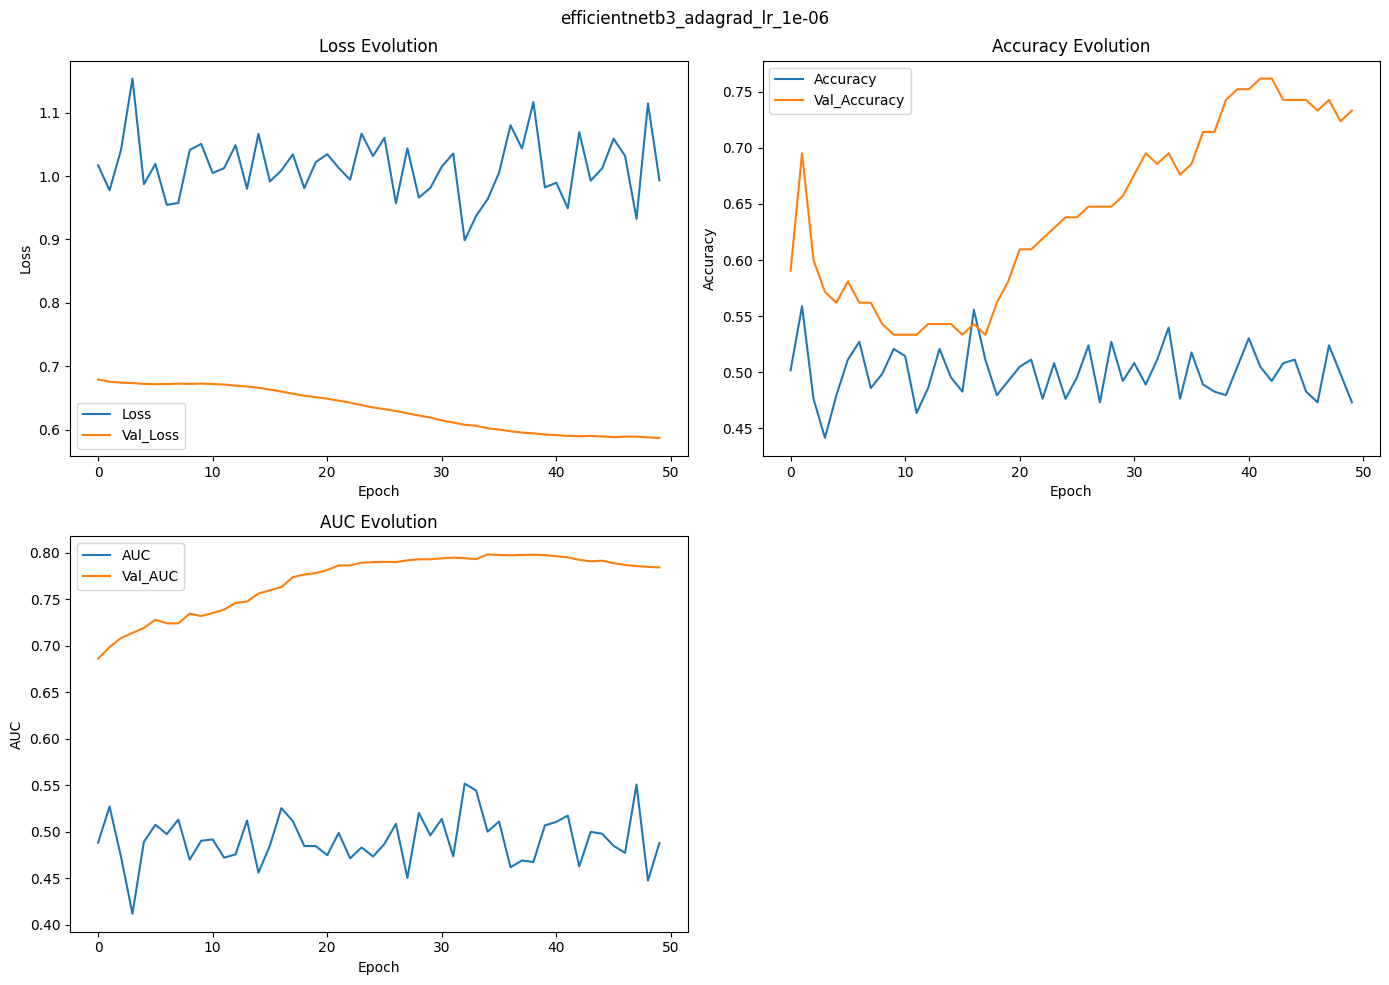

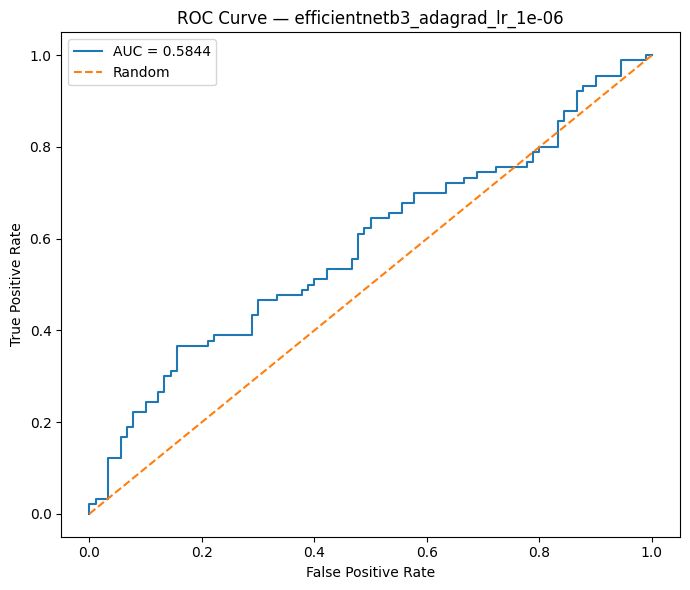

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,69,21
Actual With Disease,55,35


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,efficientnetb3,adagrad,0.000001,0.577778,0.625,0.388889,0.766667,0.479452,0.584444,69,21,55,35,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\reports\efficientnetb3_...,outputs_efficientnetb3\confusion_matrices\effi...


,precision,recall,f1-score,support
Without Disease,0.556452,0.766667,0.644860,90.000000
With Disease,0.625000,0.388889,0.479452,90.000000
accuracy,0.577778,0.577778,0.577778,0.577778
macro avg,0.590726,0.577778,0.562156,180.000000
weighted avg,0.590726,0.577778,0.562156,180.000000


Incomplete or missing run, will run: efficientnetb3_adamax_lr_0p0001
Missing: outputs_efficientnetb3\plots\efficientnetb3_adamax_lr_0p0001_history.png
Missing: outputs_efficientnetb3\plots\efficientnetb3_adamax_lr_0p0001_roc.png
Missing: outputs_efficientnetb3\reports\efficientnetb3_adamax_lr_0p0001_classification_report.csv
Missing: outputs_efficientnetb3\confusion_matrices\efficientnetb3_adamax_lr_0p0001_confusion_matrix.csv

Running: efficientnetb3_adamax_lr_0p0001
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 47s 4s/step - accuracy: 0.5333 - auc: 0.5487 - loss: 0.8975 - precision: 0.5329 - recall: 0.5633 - val_accuracy: 0.4000 - val_auc: 0.3645 - val_loss: 0.7039 - val_precision: 0.3333 - val_recall: 0.2115
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step - accuracy: 0.4857 - auc: 0.5072 - loss: 0.9880 - precision: 0.4875 - recall: 0.4937 - val_accuracy: 0.5048 - val_auc: 0.3371 - val_loss: 0.7088 - val_precision: 0.5000 - val_recall: 0.0385
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/st

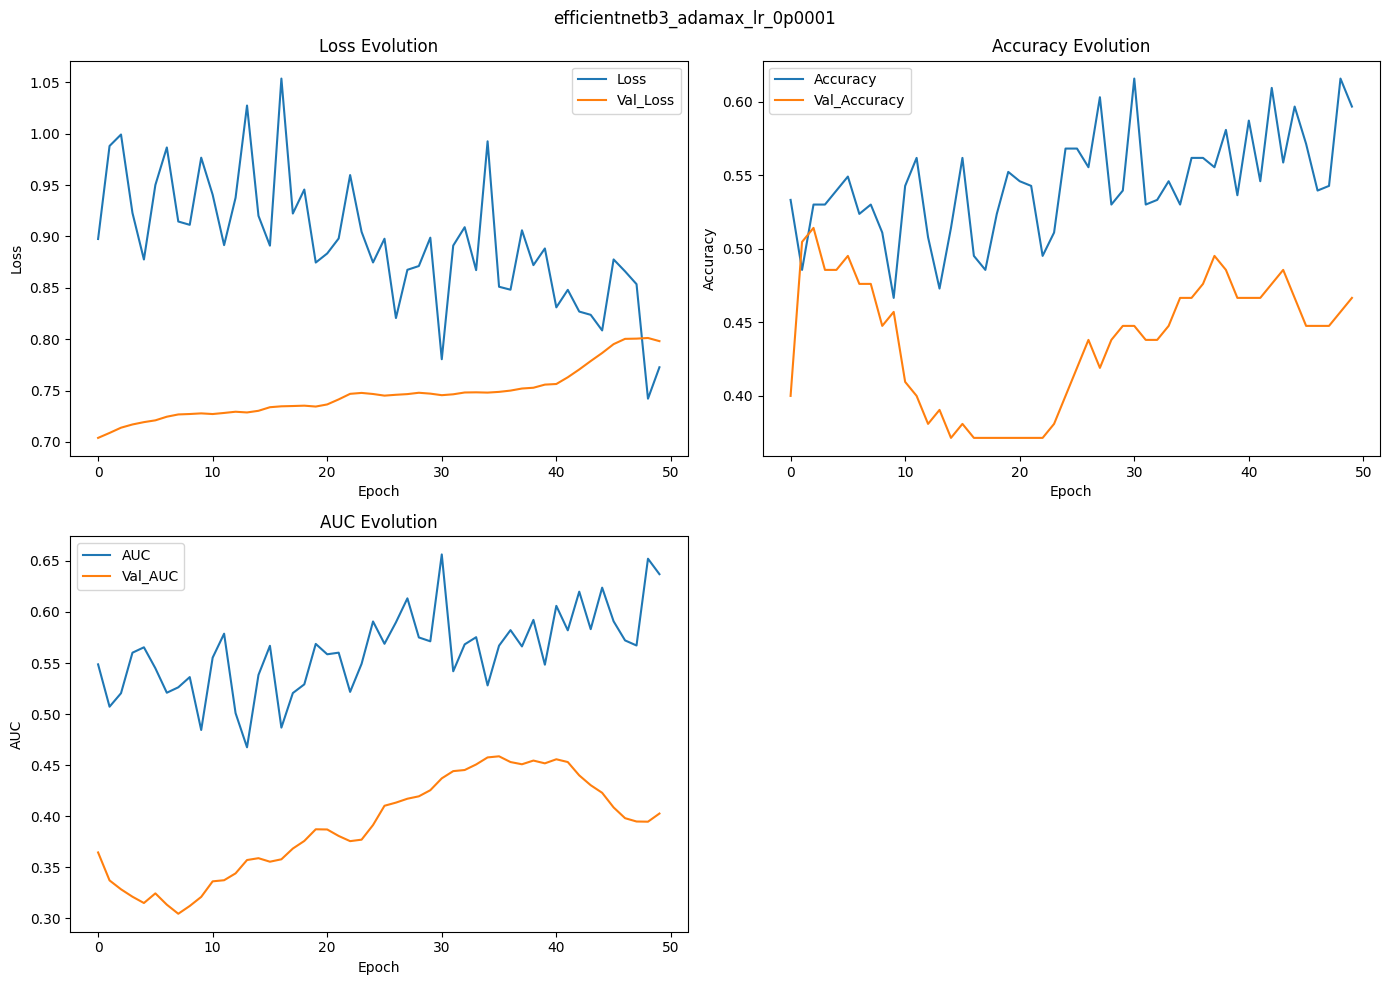

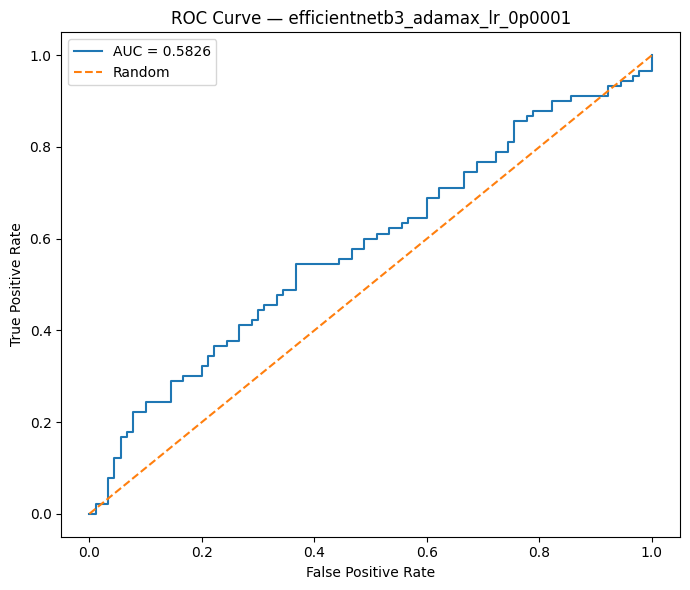

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,38,52
Actual With Disease,32,58


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,efficientnetb3,adamax,0.0001,0.533333,0.527273,0.644444,0.422222,0.58,0.582593,38,52,32,58,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\reports\efficientnetb3_...,outputs_efficientnetb3\confusion_matrices\effi...


,precision,recall,f1-score,support
Without Disease,0.542857,0.422222,0.475000,90.000000
With Disease,0.527273,0.644444,0.580000,90.000000
accuracy,0.533333,0.533333,0.533333,0.533333
macro avg,0.535065,0.533333,0.527500,180.000000
weighted avg,0.535065,0.533333,0.527500,180.000000


Incomplete or missing run, will run: efficientnetb3_adamax_lr_1e-05
Missing: outputs_efficientnetb3\plots\efficientnetb3_adamax_lr_1e-05_history.png
Missing: outputs_efficientnetb3\plots\efficientnetb3_adamax_lr_1e-05_roc.png
Missing: outputs_efficientnetb3\reports\efficientnetb3_adamax_lr_1e-05_classification_report.csv
Missing: outputs_efficientnetb3\confusion_matrices\efficientnetb3_adamax_lr_1e-05_confusion_matrix.csv

Running: efficientnetb3_adamax_lr_1e-05
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 46s 4s/step - accuracy: 0.4667 - auc: 0.4627 - loss: 1.0331 - precision: 0.4648 - recall: 0.4177 - val_accuracy: 0.4762 - val_auc: 0.4033 - val_loss: 0.7069 - val_precision: 0.4854 - val_recall: 0.9615
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step - accuracy: 0.5175 - auc: 0.5155 - loss: 1.0001 - precision: 0.5214 - recall: 0.4620 - val_accuracy: 0.4476 - val_auc: 0.3442 - val_loss: 0.7094 - val_precision: 0.4667 - val_recall: 0.8077
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - a

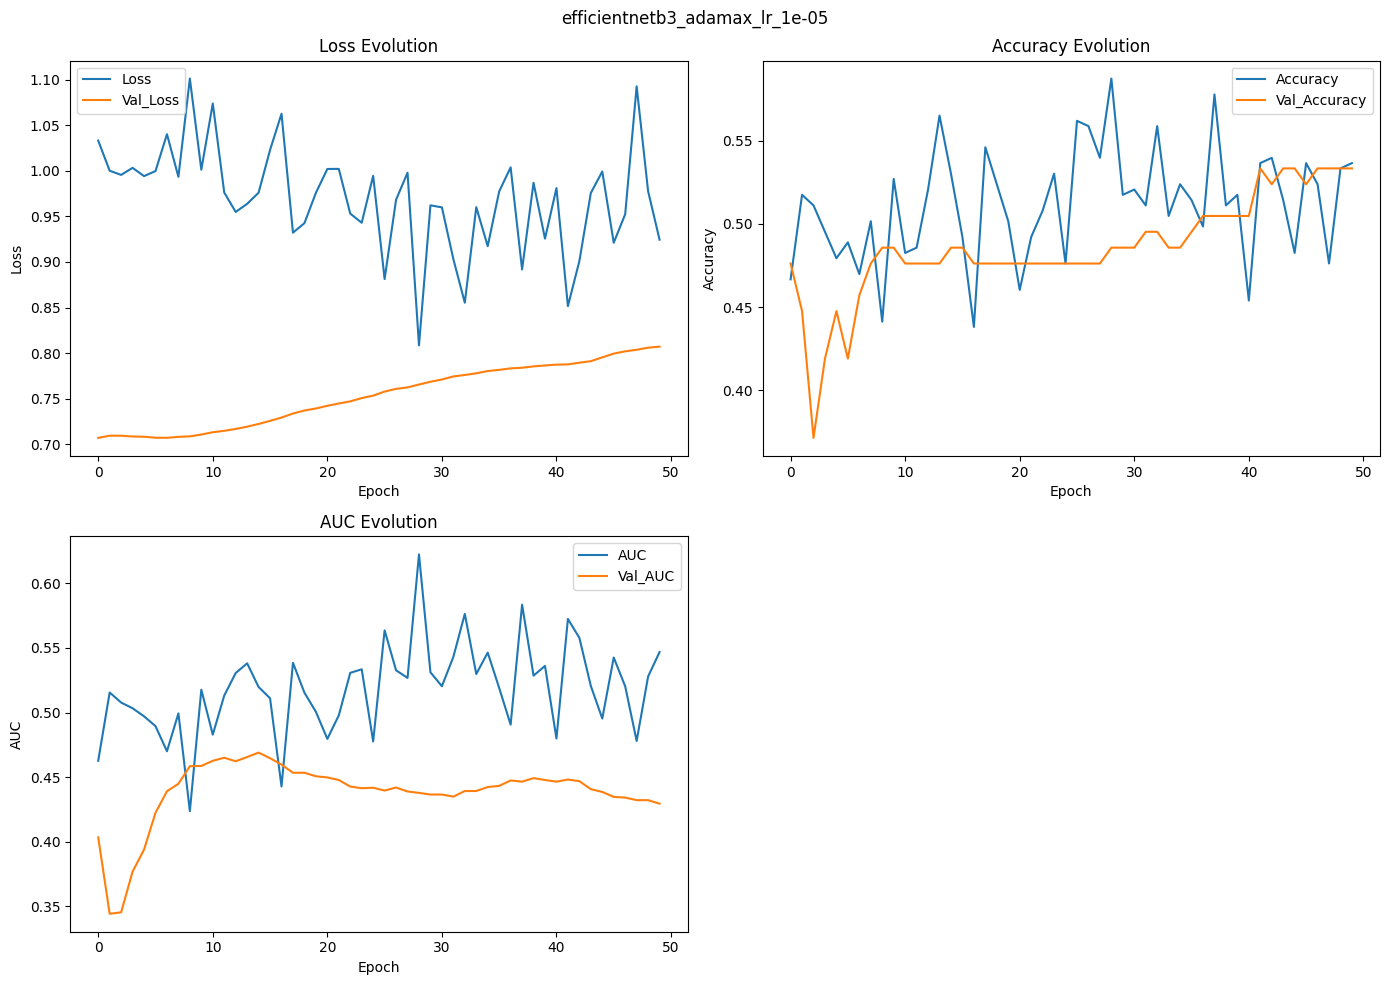

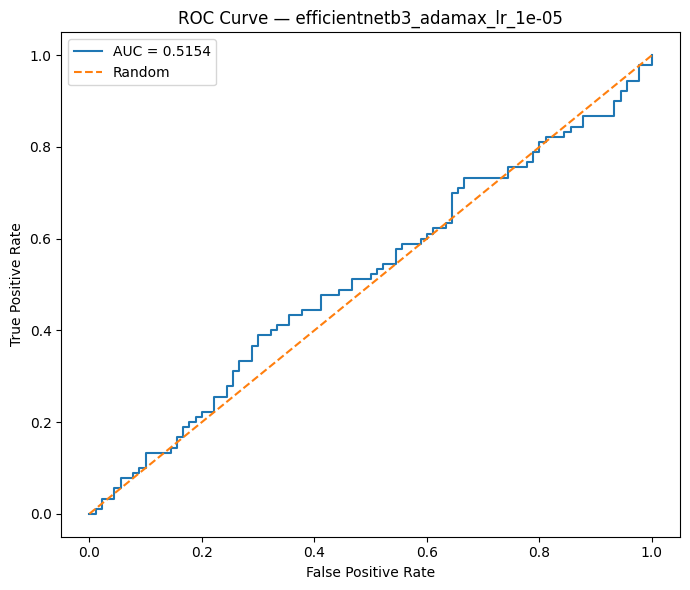

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,13,77
Actual With Disease,15,75


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,efficientnetb3,adamax,0.00001,0.488889,0.493421,0.833333,0.144444,0.619835,0.515432,13,77,15,75,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\reports\efficientnetb3_...,outputs_efficientnetb3\confusion_matrices\effi...


,precision,recall,f1-score,support
Without Disease,0.464286,0.144444,0.220339,90.000000
With Disease,0.493421,0.833333,0.619835,90.000000
accuracy,0.488889,0.488889,0.488889,0.488889
macro avg,0.478853,0.488889,0.420087,180.000000
weighted avg,0.478853,0.488889,0.420087,180.000000


Incomplete or missing run, will run: efficientnetb3_adamax_lr_1e-06
Missing: outputs_efficientnetb3\plots\efficientnetb3_adamax_lr_1e-06_history.png
Missing: outputs_efficientnetb3\plots\efficientnetb3_adamax_lr_1e-06_roc.png
Missing: outputs_efficientnetb3\reports\efficientnetb3_adamax_lr_1e-06_classification_report.csv
Missing: outputs_efficientnetb3\confusion_matrices\efficientnetb3_adamax_lr_1e-06_confusion_matrix.csv

Running: efficientnetb3_adamax_lr_1e-06
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 46s 4s/step - accuracy: 0.4603 - auc: 0.4550 - loss: 1.0211 - precision: 0.4615 - recall: 0.4557 - val_accuracy: 0.4952 - val_auc: 0.4873 - val_loss: 0.6937 - val_precision: 0.4932 - val_recall: 0.6923
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step - accuracy: 0.5079 - auc: 0.5135 - loss: 0.9234 - precision: 0.5092 - recall: 0.5253 - val_accuracy: 0.4762 - val_auc: 0.4871 - val_loss: 0.6939 - val_precision: 0.4694 - val_recall: 0.4423
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step - a

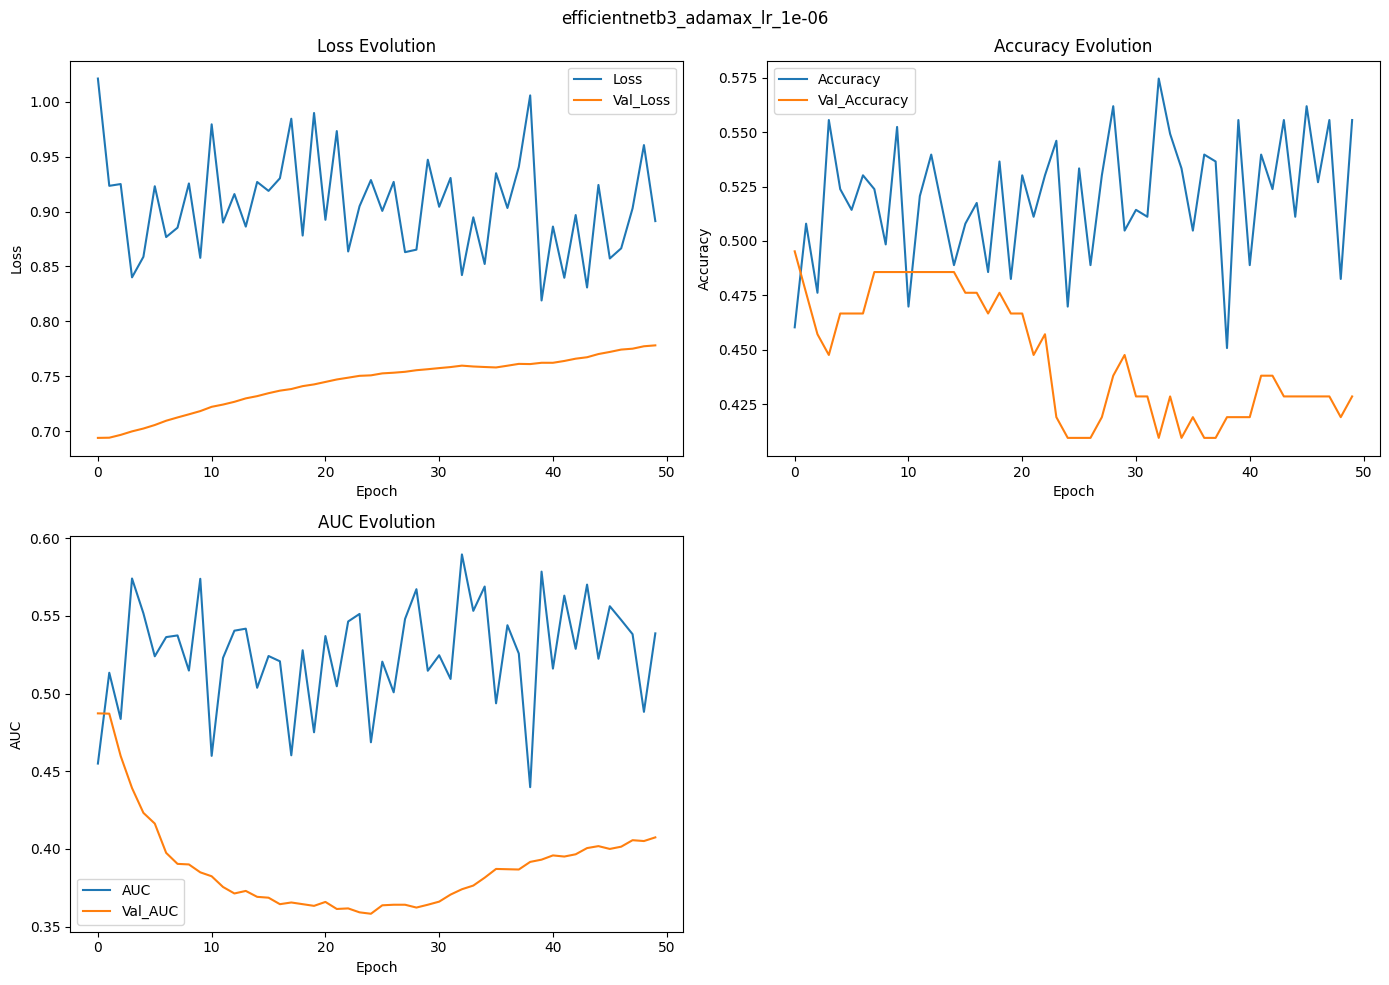

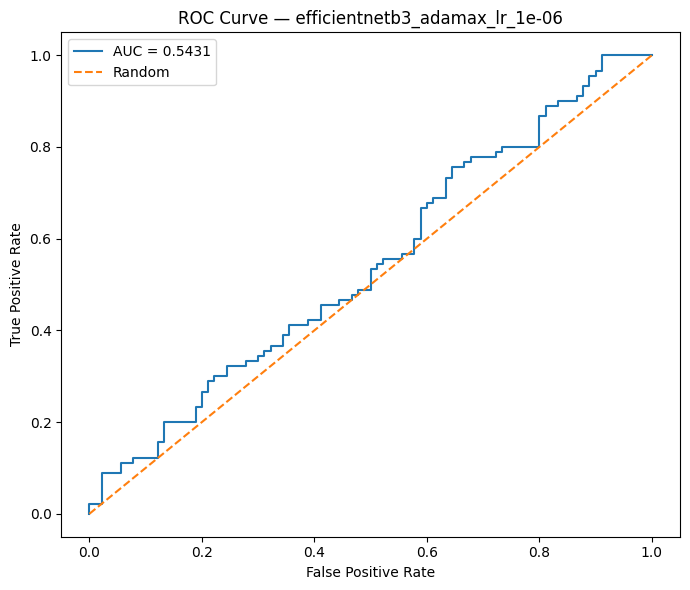

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,27,63
Actual With Disease,20,70


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,efficientnetb3,adamax,0.000001,0.538889,0.526316,0.777778,0.3,0.627803,0.543086,27,63,20,70,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\reports\efficientnetb3_...,outputs_efficientnetb3\confusion_matrices\effi...


,precision,recall,f1-score,support
Without Disease,0.574468,0.300000,0.394161,90.000000
With Disease,0.526316,0.777778,0.627803,90.000000
accuracy,0.538889,0.538889,0.538889,0.538889
macro avg,0.550392,0.538889,0.510982,180.000000
weighted avg,0.550392,0.538889,0.510982,180.000000


Incomplete or missing run, will run: efficientnetb3_adadelta_lr_0p0001
Missing: outputs_efficientnetb3\plots\efficientnetb3_adadelta_lr_0p0001_history.png
Missing: outputs_efficientnetb3\plots\efficientnetb3_adadelta_lr_0p0001_roc.png
Missing: outputs_efficientnetb3\reports\efficientnetb3_adadelta_lr_0p0001_classification_report.csv
Missing: outputs_efficientnetb3\confusion_matrices\efficientnetb3_adadelta_lr_0p0001_confusion_matrix.csv

Running: efficientnetb3_adadelta_lr_0p0001
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 46s 4s/step - accuracy: 0.4571 - auc: 0.4506 - loss: 1.0222 - precision: 0.4552 - recall: 0.4177 - val_accuracy: 0.5619 - val_auc: 0.5840 - val_loss: 0.6886 - val_precision: 0.5536 - val_recall: 0.5962
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step - accuracy: 0.4825 - auc: 0.4750 - loss: 0.9922 - precision: 0.4841 - recall: 0.4810 - val_accuracy: 0.5905 - val_auc: 0.6096 - val_loss: 0.6857 - val_precision: 0.6154 - val_recall: 0.4615
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━

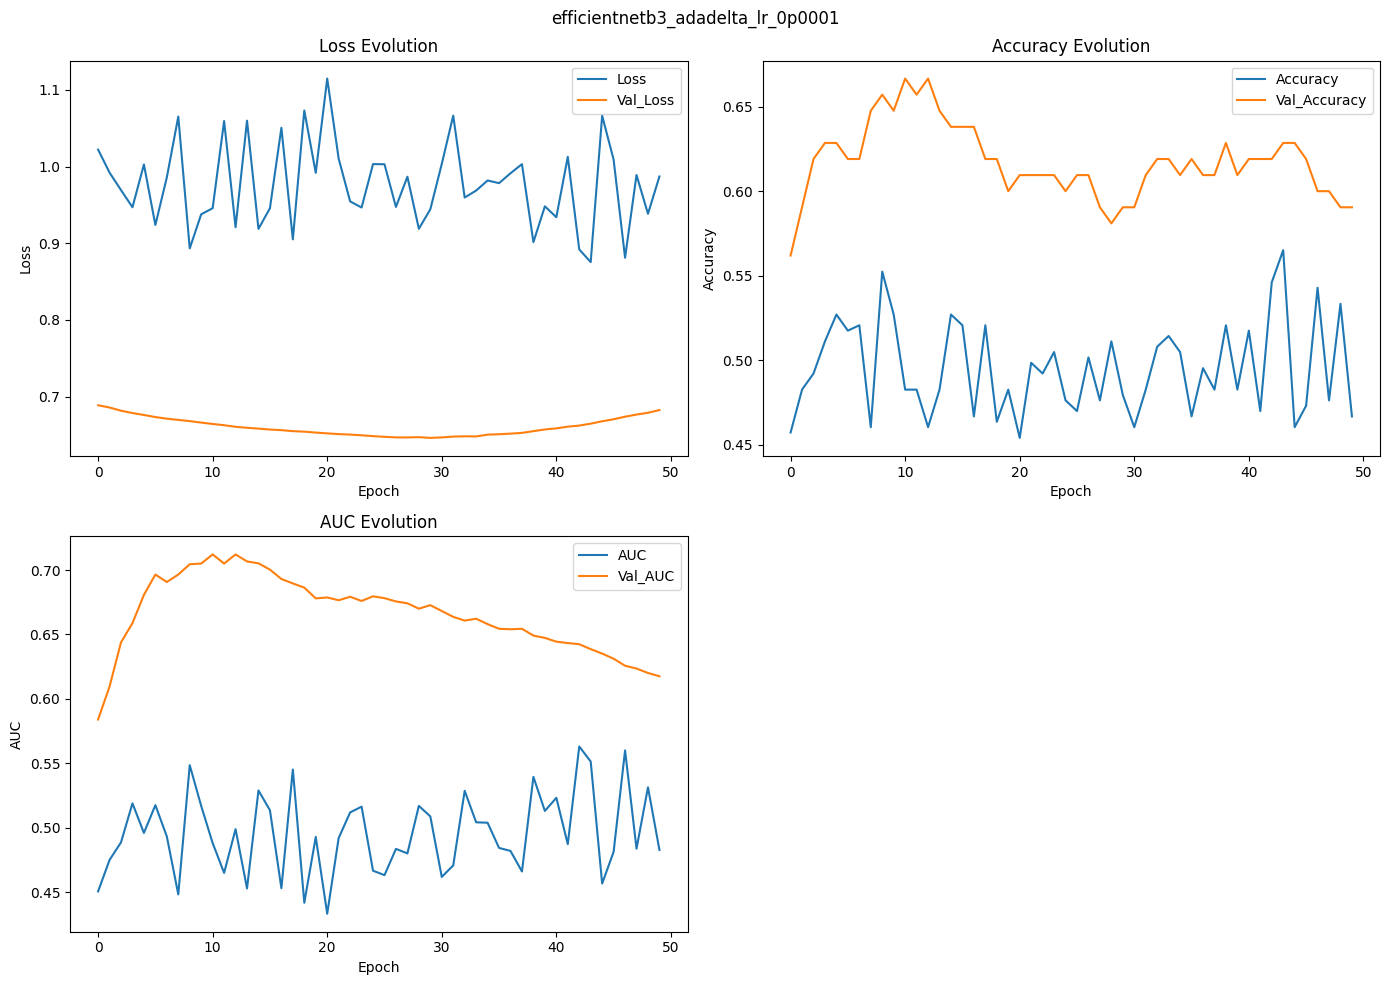

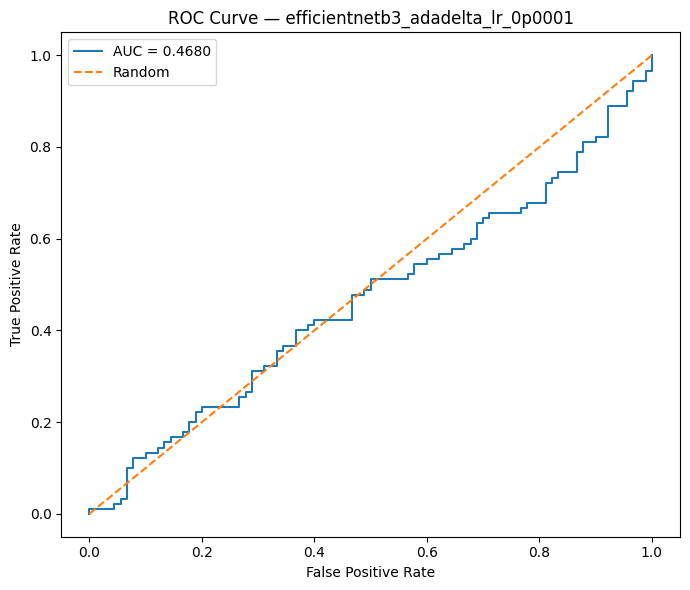

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,48,42
Actual With Disease,50,40


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,efficientnetb3,adadelta,0.0001,0.488889,0.487805,0.444444,0.533333,0.465116,0.468025,48,42,50,40,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\reports\efficientnetb3_...,outputs_efficientnetb3\confusion_matrices\effi...


,precision,recall,f1-score,support
Without Disease,0.489796,0.533333,0.510638,90.000000
With Disease,0.487805,0.444444,0.465116,90.000000
accuracy,0.488889,0.488889,0.488889,0.488889
macro avg,0.488800,0.488889,0.487877,180.000000
weighted avg,0.488800,0.488889,0.487877,180.000000


Incomplete or missing run, will run: efficientnetb3_adadelta_lr_1e-05
Missing: outputs_efficientnetb3\plots\efficientnetb3_adadelta_lr_1e-05_history.png
Missing: outputs_efficientnetb3\plots\efficientnetb3_adadelta_lr_1e-05_roc.png
Missing: outputs_efficientnetb3\reports\efficientnetb3_adadelta_lr_1e-05_classification_report.csv
Missing: outputs_efficientnetb3\confusion_matrices\efficientnetb3_adadelta_lr_1e-05_confusion_matrix.csv

Running: efficientnetb3_adadelta_lr_1e-05
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 46s 4s/step - accuracy: 0.5619 - auc: 0.5799 - loss: 0.8342 - precision: 0.5649 - recall: 0.5506 - val_accuracy: 0.4476 - val_auc: 0.3124 - val_loss: 0.7205 - val_precision: 0.4634 - val_recall: 0.7308
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step - accuracy: 0.5397 - auc: 0.5560 - loss: 0.8925 - precision: 0.5394 - recall: 0.5633 - val_accuracy: 0.4476 - val_auc: 0.3191 - val_loss: 0.7222 - val_precision: 0.4667 - val_recall: 0.8077
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 32s

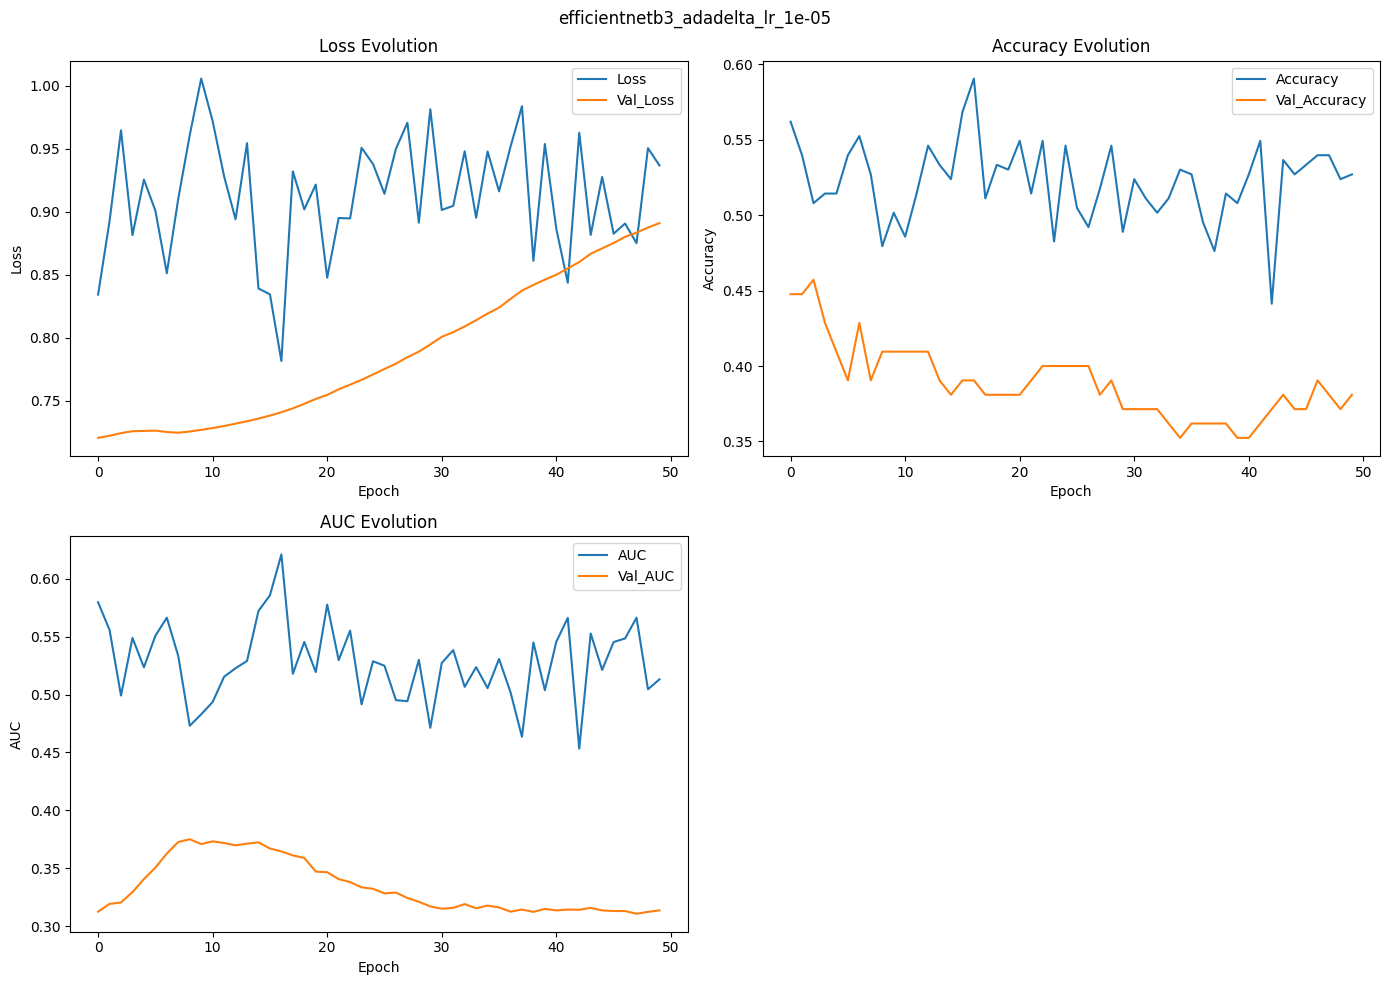

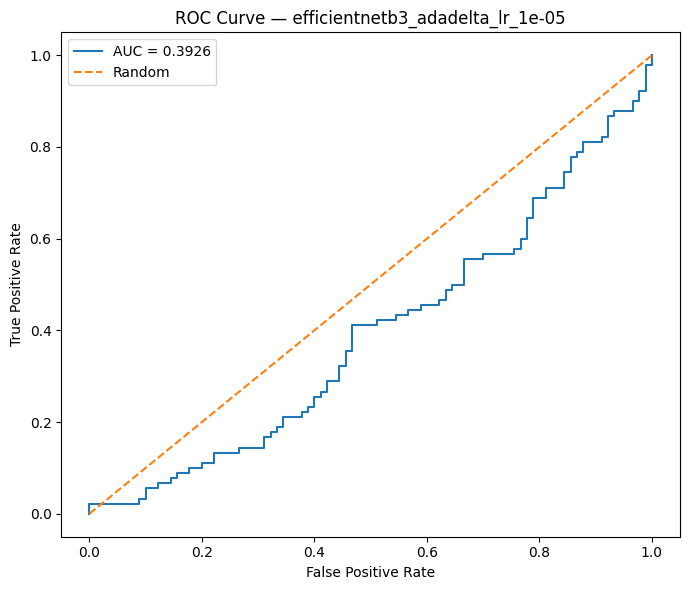

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,50,40
Actual With Disease,64,26


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,efficientnetb3,adadelta,0.00001,0.422222,0.393939,0.288889,0.555556,0.333333,0.392593,50,40,64,26,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\reports\efficientnetb3_...,outputs_efficientnetb3\confusion_matrices\effi...


,precision,recall,f1-score,support
Without Disease,0.438596,0.555556,0.490196,90.000000
With Disease,0.393939,0.288889,0.333333,90.000000
accuracy,0.422222,0.422222,0.422222,0.422222
macro avg,0.416268,0.422222,0.411765,180.000000
weighted avg,0.416268,0.422222,0.411765,180.000000


Incomplete or missing run, will run: efficientnetb3_adadelta_lr_1e-06
Missing: outputs_efficientnetb3\plots\efficientnetb3_adadelta_lr_1e-06_history.png
Missing: outputs_efficientnetb3\plots\efficientnetb3_adadelta_lr_1e-06_roc.png
Missing: outputs_efficientnetb3\reports\efficientnetb3_adadelta_lr_1e-06_classification_report.csv
Missing: outputs_efficientnetb3\confusion_matrices\efficientnetb3_adadelta_lr_1e-06_confusion_matrix.csv

Running: efficientnetb3_adadelta_lr_1e-06
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 51s 4s/step - accuracy: 0.5048 - auc: 0.4907 - loss: 0.9257 - precision: 0.5060 - recall: 0.5316 - val_accuracy: 0.5048 - val_auc: 0.7161 - val_loss: 0.6812 - val_precision: 0.5000 - val_recall: 0.0192
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 38s 4s/step - accuracy: 0.4952 - auc: 0.4708 - loss: 0.9516 - precision: 0.4970 - recall: 0.5316 - val_accuracy: 0.5238 - val_auc: 0.6684 - val_loss: 0.6830 - val_precision: 0.6667 - val_recall: 0.0769
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 38s

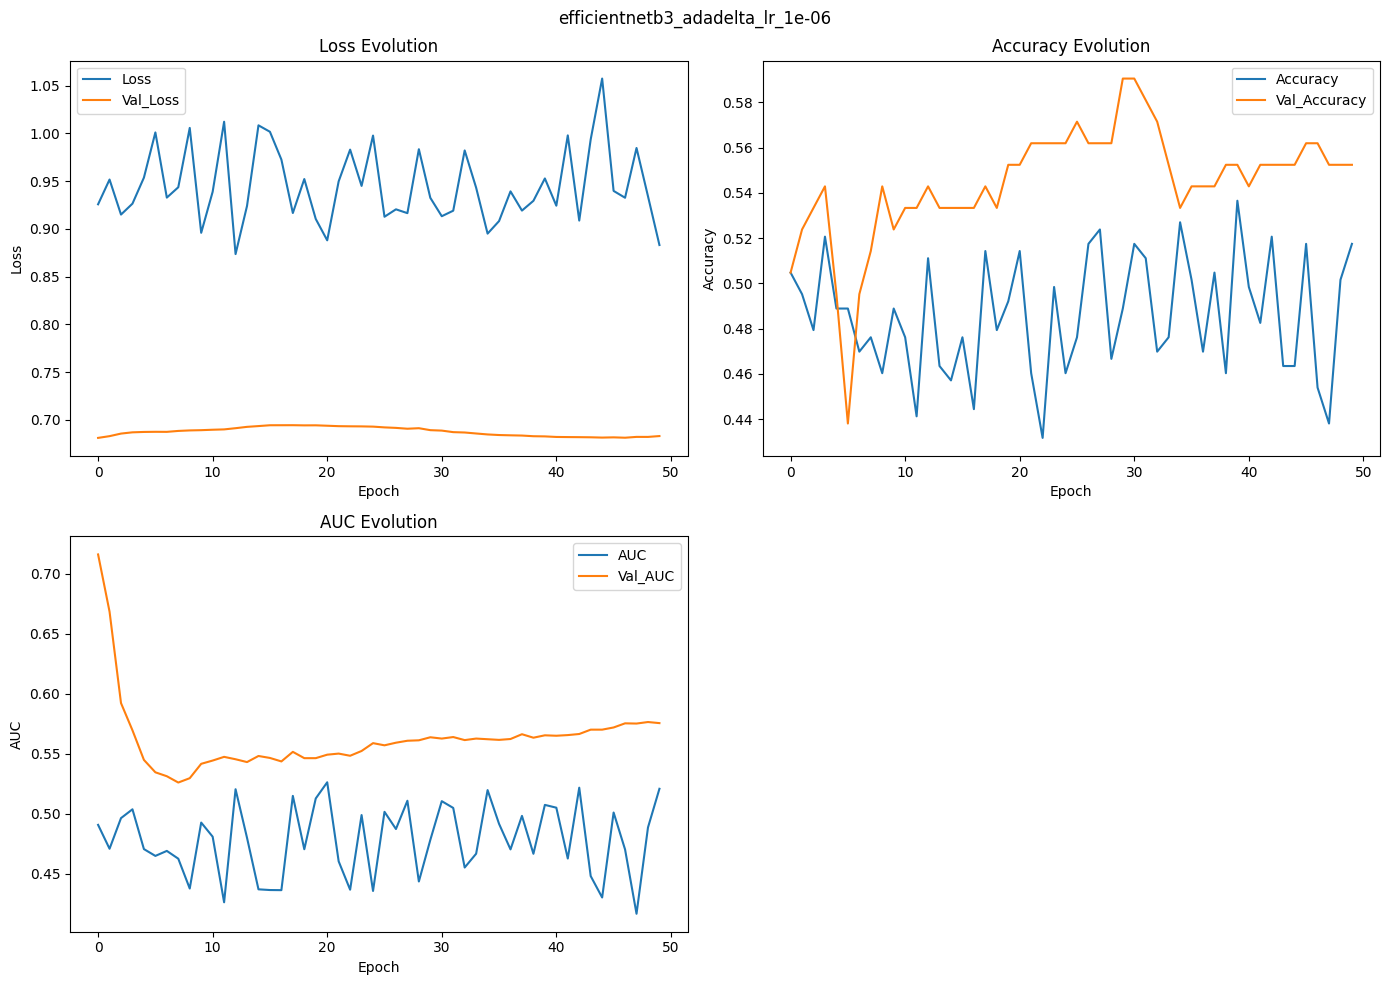

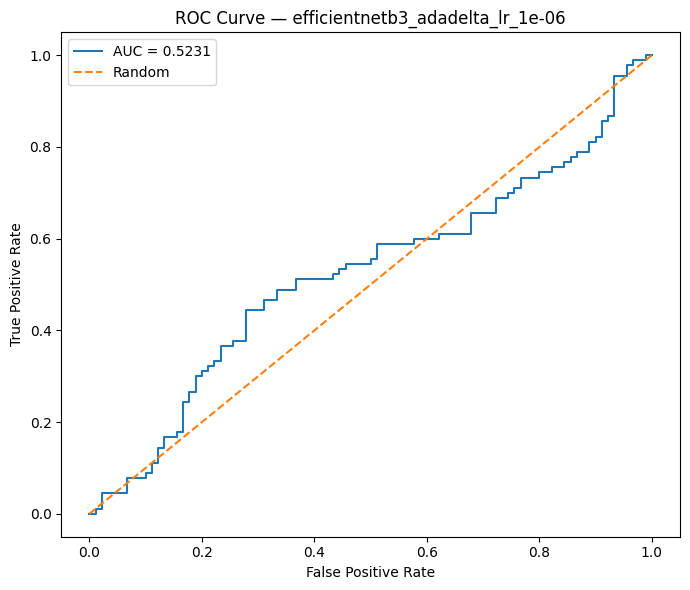

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,73,17
Actual With Disease,66,24


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,efficientnetb3,adadelta,0.000001,0.538889,0.585366,0.266667,0.811111,0.366412,0.523086,73,17,66,24,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\reports\efficientnetb3_...,outputs_efficientnetb3\confusion_matrices\effi...


,precision,recall,f1-score,support
Without Disease,0.525180,0.811111,0.637555,90.000000
With Disease,0.585366,0.266667,0.366412,90.000000
accuracy,0.538889,0.538889,0.538889,0.538889
macro avg,0.555273,0.538889,0.501983,180.000000
weighted avg,0.555273,0.538889,0.501983,180.000000


Incomplete or missing run, will run: efficientnetb3_sgd_lr_0p0001
Missing: outputs_efficientnetb3\plots\efficientnetb3_sgd_lr_0p0001_history.png
Missing: outputs_efficientnetb3\plots\efficientnetb3_sgd_lr_0p0001_roc.png
Missing: outputs_efficientnetb3\reports\efficientnetb3_sgd_lr_0p0001_classification_report.csv
Missing: outputs_efficientnetb3\confusion_matrices\efficientnetb3_sgd_lr_0p0001_confusion_matrix.csv

Running: efficientnetb3_sgd_lr_0p0001
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 62s 5s/step - accuracy: 0.5270 - auc: 0.5654 - loss: 0.8753 - precision: 0.5290 - recall: 0.5190 - val_accuracy: 0.5429 - val_auc: 0.6101 - val_loss: 0.6853 - val_precision: 0.5909 - val_recall: 0.2500
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 36s 4s/step - accuracy: 0.5143 - auc: 0.5082 - loss: 0.9403 - precision: 0.5163 - recall: 0.5000 - val_accuracy: 0.4762 - val_auc: 0.5633 - val_loss: 0.6900 - val_precision: 0.2000 - val_recall: 0.0192
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 37s 4s/step - accuracy: 0.4

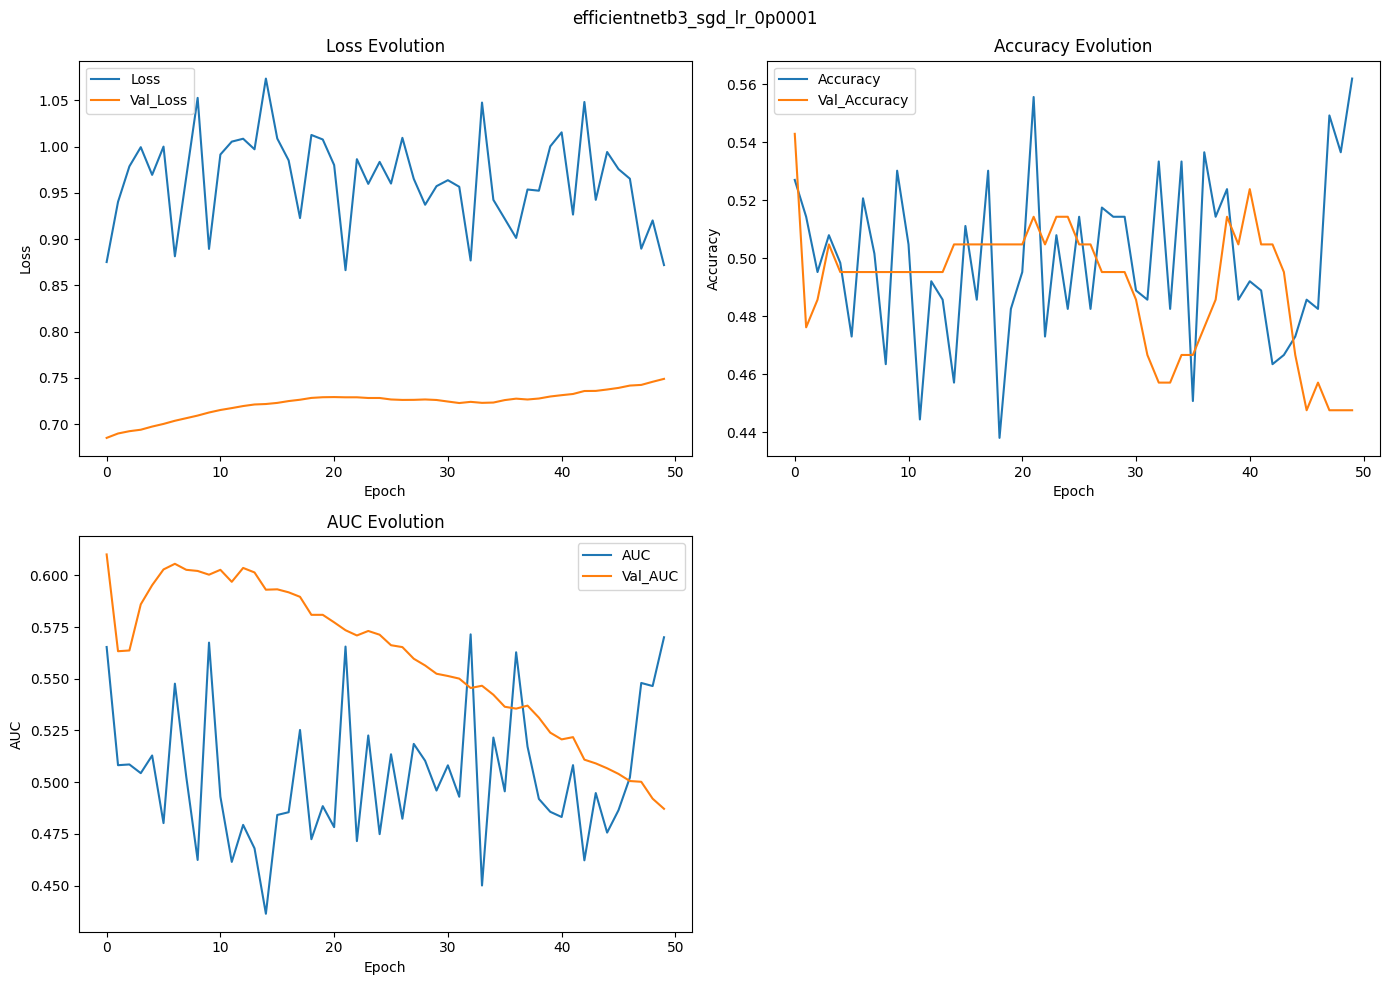

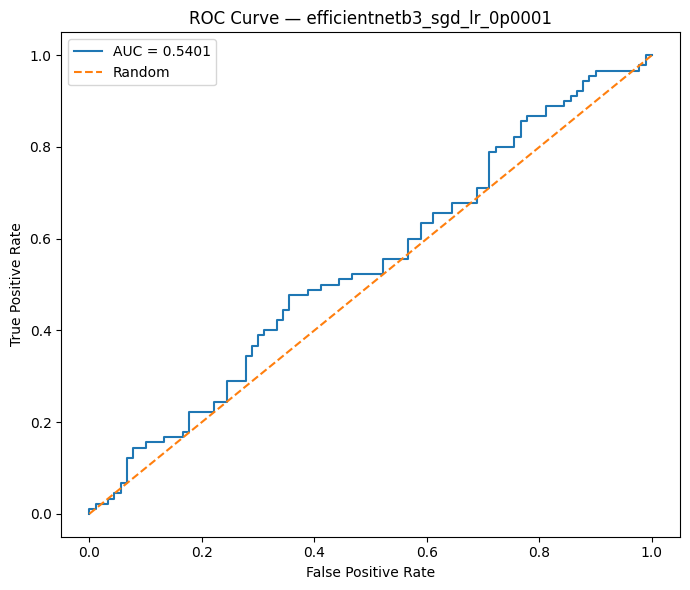

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,20,70
Actual With Disease,12,78


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,efficientnetb3,sgd,0.0001,0.544444,0.527027,0.866667,0.222222,0.655462,0.540123,20,70,12,78,outputs_efficientnetb3\plots\efficientnetb3_sg...,outputs_efficientnetb3\plots\efficientnetb3_sg...,outputs_efficientnetb3\reports\efficientnetb3_...,outputs_efficientnetb3\confusion_matrices\effi...


,precision,recall,f1-score,support
Without Disease,0.625000,0.222222,0.327869,90.000000
With Disease,0.527027,0.866667,0.655462,90.000000
accuracy,0.544444,0.544444,0.544444,0.544444
macro avg,0.576014,0.544444,0.491666,180.000000
weighted avg,0.576014,0.544444,0.491666,180.000000


Incomplete or missing run, will run: efficientnetb3_sgd_lr_1e-05
Missing: outputs_efficientnetb3\plots\efficientnetb3_sgd_lr_1e-05_history.png
Missing: outputs_efficientnetb3\plots\efficientnetb3_sgd_lr_1e-05_roc.png
Missing: outputs_efficientnetb3\reports\efficientnetb3_sgd_lr_1e-05_classification_report.csv
Missing: outputs_efficientnetb3\confusion_matrices\efficientnetb3_sgd_lr_1e-05_confusion_matrix.csv

Running: efficientnetb3_sgd_lr_1e-05
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 57s 5s/step - accuracy: 0.5111 - auc: 0.5028 - loss: 0.9901 - precision: 0.5125 - recall: 0.5190 - val_accuracy: 0.4857 - val_auc: 0.5118 - val_loss: 0.6940 - val_precision: 0.4861 - val_recall: 0.6731
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 36s 4s/step - accuracy: 0.4508 - auc: 0.4464 - loss: 1.0313 - precision: 0.4528 - recall: 0.4557 - val_accuracy: 0.4762 - val_auc: 0.4853 - val_loss: 0.6948 - val_precision: 0.4400 - val_recall: 0.2115
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 38s 4s/step - accuracy: 0.4667 - 

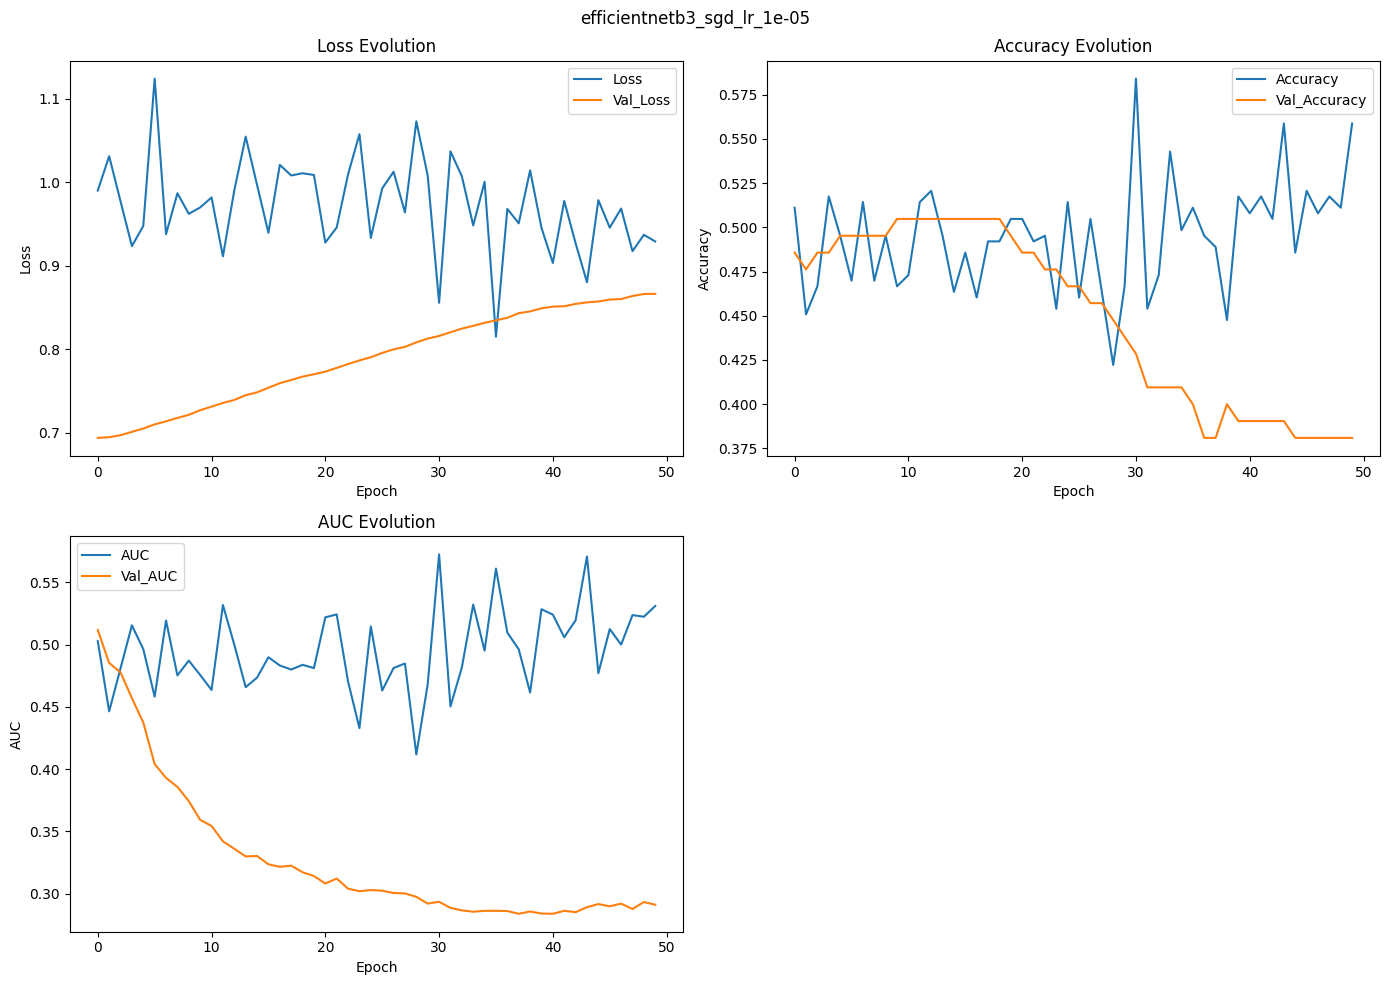

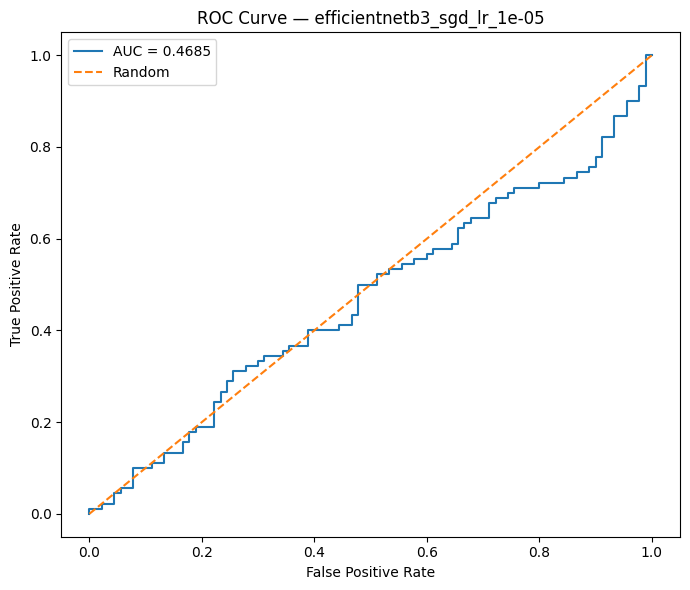

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,6,84
Actual With Disease,15,75


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,efficientnetb3,sgd,0.00001,0.45,0.471698,0.833333,0.066667,0.60241,0.468519,6,84,15,75,outputs_efficientnetb3\plots\efficientnetb3_sg...,outputs_efficientnetb3\plots\efficientnetb3_sg...,outputs_efficientnetb3\reports\efficientnetb3_...,outputs_efficientnetb3\confusion_matrices\effi...


,precision,recall,f1-score,support
Without Disease,0.285714,0.066667,0.108108,90.00
With Disease,0.471698,0.833333,0.602410,90.00
accuracy,0.450000,0.450000,0.450000,0.45
macro avg,0.378706,0.450000,0.355259,180.00
weighted avg,0.378706,0.450000,0.355259,180.00


Incomplete or missing run, will run: efficientnetb3_sgd_lr_1e-06
Missing: outputs_efficientnetb3\plots\efficientnetb3_sgd_lr_1e-06_history.png
Missing: outputs_efficientnetb3\plots\efficientnetb3_sgd_lr_1e-06_roc.png
Missing: outputs_efficientnetb3\reports\efficientnetb3_sgd_lr_1e-06_classification_report.csv
Missing: outputs_efficientnetb3\confusion_matrices\efficientnetb3_sgd_lr_1e-06_confusion_matrix.csv

Running: efficientnetb3_sgd_lr_1e-06
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 53s 4s/step - accuracy: 0.4762 - auc: 0.4609 - loss: 1.0212 - precision: 0.4774 - recall: 0.4684 - val_accuracy: 0.5238 - val_auc: 0.4690 - val_loss: 0.6997 - val_precision: 0.5098 - val_recall: 1.0000
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.4762 - auc: 0.4719 - loss: 0.9827 - precision: 0.4755 - recall: 0.4304 - val_accuracy: 0.4952 - val_auc: 0.4401 - val_loss: 0.6992 - val_precision: 0.4940 - val_recall: 0.7885
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 36s 4s/step - accuracy: 0.5429 - 

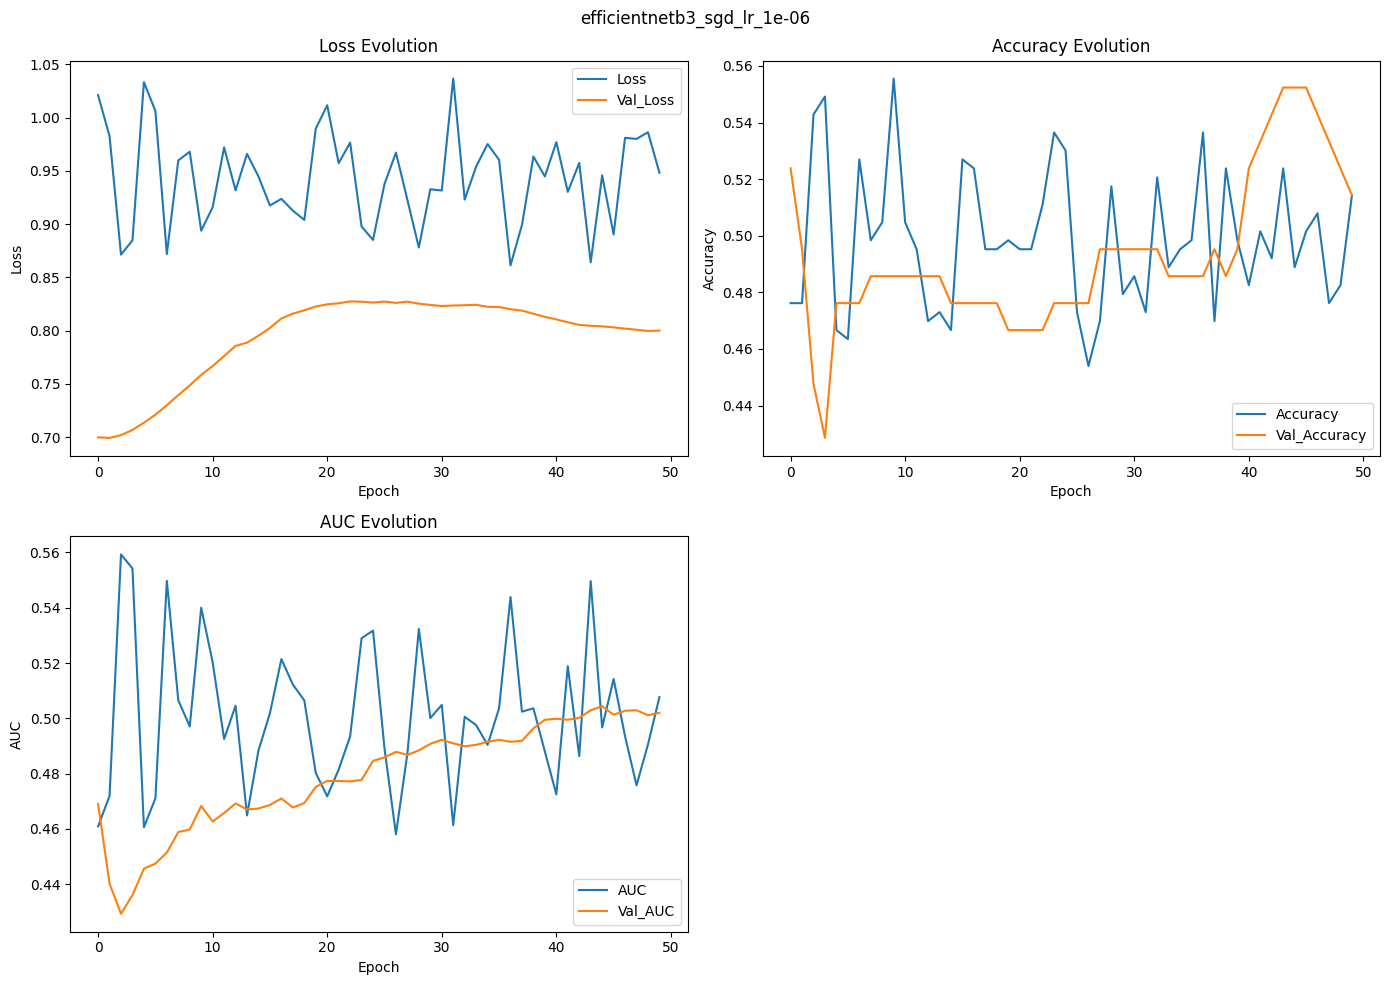

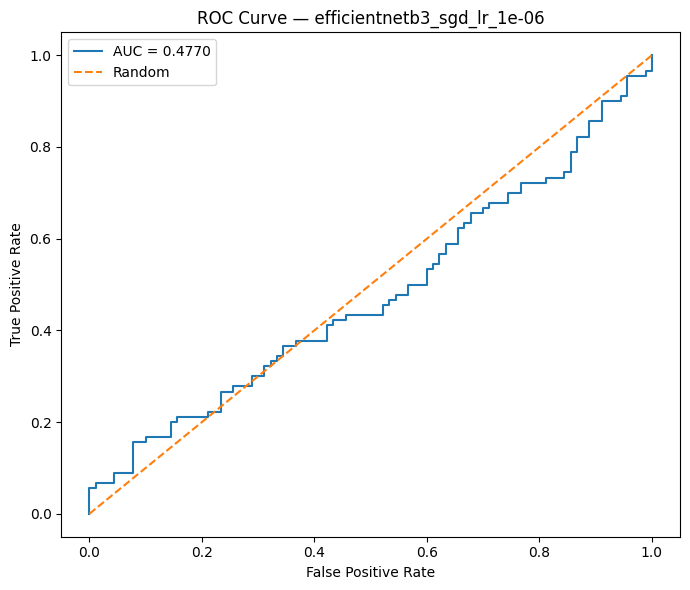

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,6,84
Actual With Disease,9,81


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,efficientnetb3,sgd,0.000001,0.483333,0.490909,0.9,0.066667,0.635294,0.477037,6,84,9,81,outputs_efficientnetb3\plots\efficientnetb3_sg...,outputs_efficientnetb3\plots\efficientnetb3_sg...,outputs_efficientnetb3\reports\efficientnetb3_...,outputs_efficientnetb3\confusion_matrices\effi...


,precision,recall,f1-score,support
Without Disease,0.400000,0.066667,0.114286,90.000000
With Disease,0.490909,0.900000,0.635294,90.000000
accuracy,0.483333,0.483333,0.483333,0.483333
macro avg,0.445455,0.483333,0.374790,180.000000
weighted avg,0.445455,0.483333,0.374790,180.000000


Incomplete or missing run, will run: efficientnetb3_rmsprop_lr_0p0001
Missing: outputs_efficientnetb3\plots\efficientnetb3_rmsprop_lr_0p0001_history.png
Missing: outputs_efficientnetb3\plots\efficientnetb3_rmsprop_lr_0p0001_roc.png
Missing: outputs_efficientnetb3\reports\efficientnetb3_rmsprop_lr_0p0001_classification_report.csv
Missing: outputs_efficientnetb3\confusion_matrices\efficientnetb3_rmsprop_lr_0p0001_confusion_matrix.csv

Running: efficientnetb3_rmsprop_lr_0p0001
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 55s 4s/step - accuracy: 0.5714 - auc: 0.6011 - loss: 0.8178 - precision: 0.5793 - recall: 0.5316 - val_accuracy: 0.4190 - val_auc: 0.5016 - val_loss: 0.6938 - val_precision: 0.2632 - val_recall: 0.0962
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.5079 - auc: 0.5322 - loss: 0.8953 - precision: 0.5099 - recall: 0.4873 - val_accuracy: 0.4857 - val_auc: 0.5185 - val_loss: 0.6944 - val_precision: 0.3750 - val_recall: 0.0577
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 34s

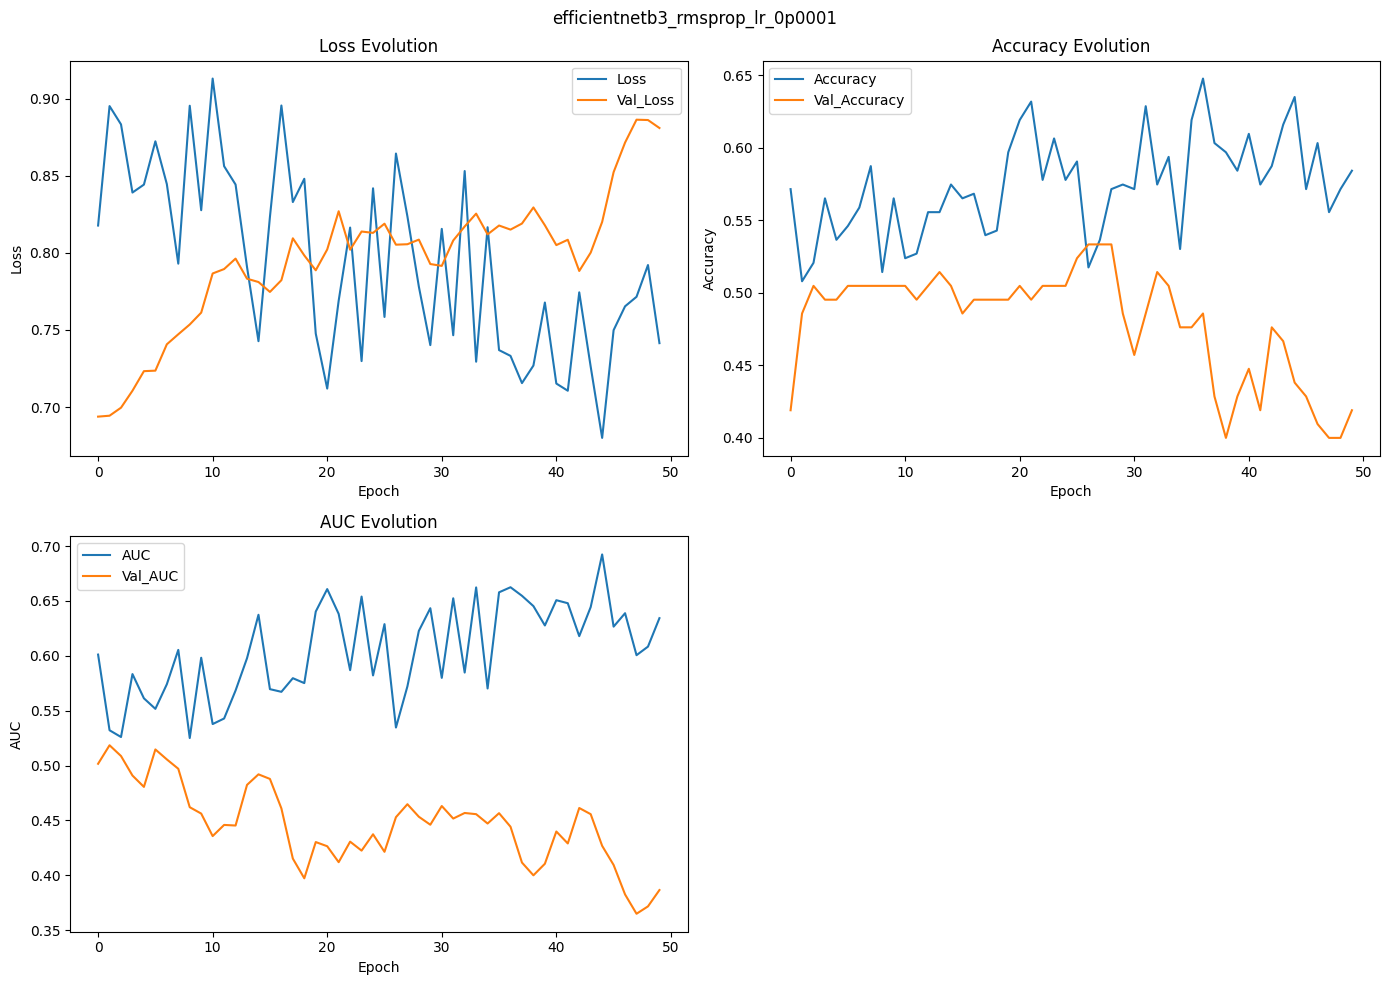

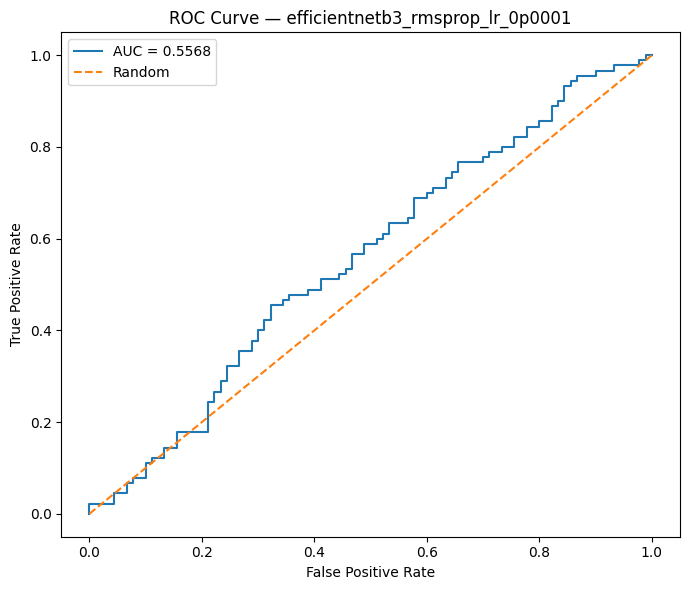

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,31,59
Actual With Disease,21,69


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,efficientnetb3,rmsprop,0.0001,0.555556,0.539062,0.766667,0.344444,0.633028,0.55679,31,59,21,69,outputs_efficientnetb3\plots\efficientnetb3_rm...,outputs_efficientnetb3\plots\efficientnetb3_rm...,outputs_efficientnetb3\reports\efficientnetb3_...,outputs_efficientnetb3\confusion_matrices\effi...


,precision,recall,f1-score,support
Without Disease,0.596154,0.344444,0.436620,90.000000
With Disease,0.539062,0.766667,0.633028,90.000000
accuracy,0.555556,0.555556,0.555556,0.555556
macro avg,0.567608,0.555556,0.534824,180.000000
weighted avg,0.567608,0.555556,0.534824,180.000000


Incomplete or missing run, will run: efficientnetb3_rmsprop_lr_1e-05
Missing: outputs_efficientnetb3\plots\efficientnetb3_rmsprop_lr_1e-05_history.png
Missing: outputs_efficientnetb3\plots\efficientnetb3_rmsprop_lr_1e-05_roc.png
Missing: outputs_efficientnetb3\reports\efficientnetb3_rmsprop_lr_1e-05_classification_report.csv
Missing: outputs_efficientnetb3\confusion_matrices\efficientnetb3_rmsprop_lr_1e-05_confusion_matrix.csv

Running: efficientnetb3_rmsprop_lr_1e-05
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 58s 5s/step - accuracy: 0.5143 - auc: 0.5024 - loss: 0.9667 - precision: 0.5153 - recall: 0.5316 - val_accuracy: 0.5143 - val_auc: 0.5468 - val_loss: 0.6909 - val_precision: 0.5068 - val_recall: 0.7115
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 36s 4s/step - accuracy: 0.5079 - auc: 0.5138 - loss: 0.9498 - precision: 0.5093 - recall: 0.5190 - val_accuracy: 0.5048 - val_auc: 0.4503 - val_loss: 0.7010 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 36s 4s/st

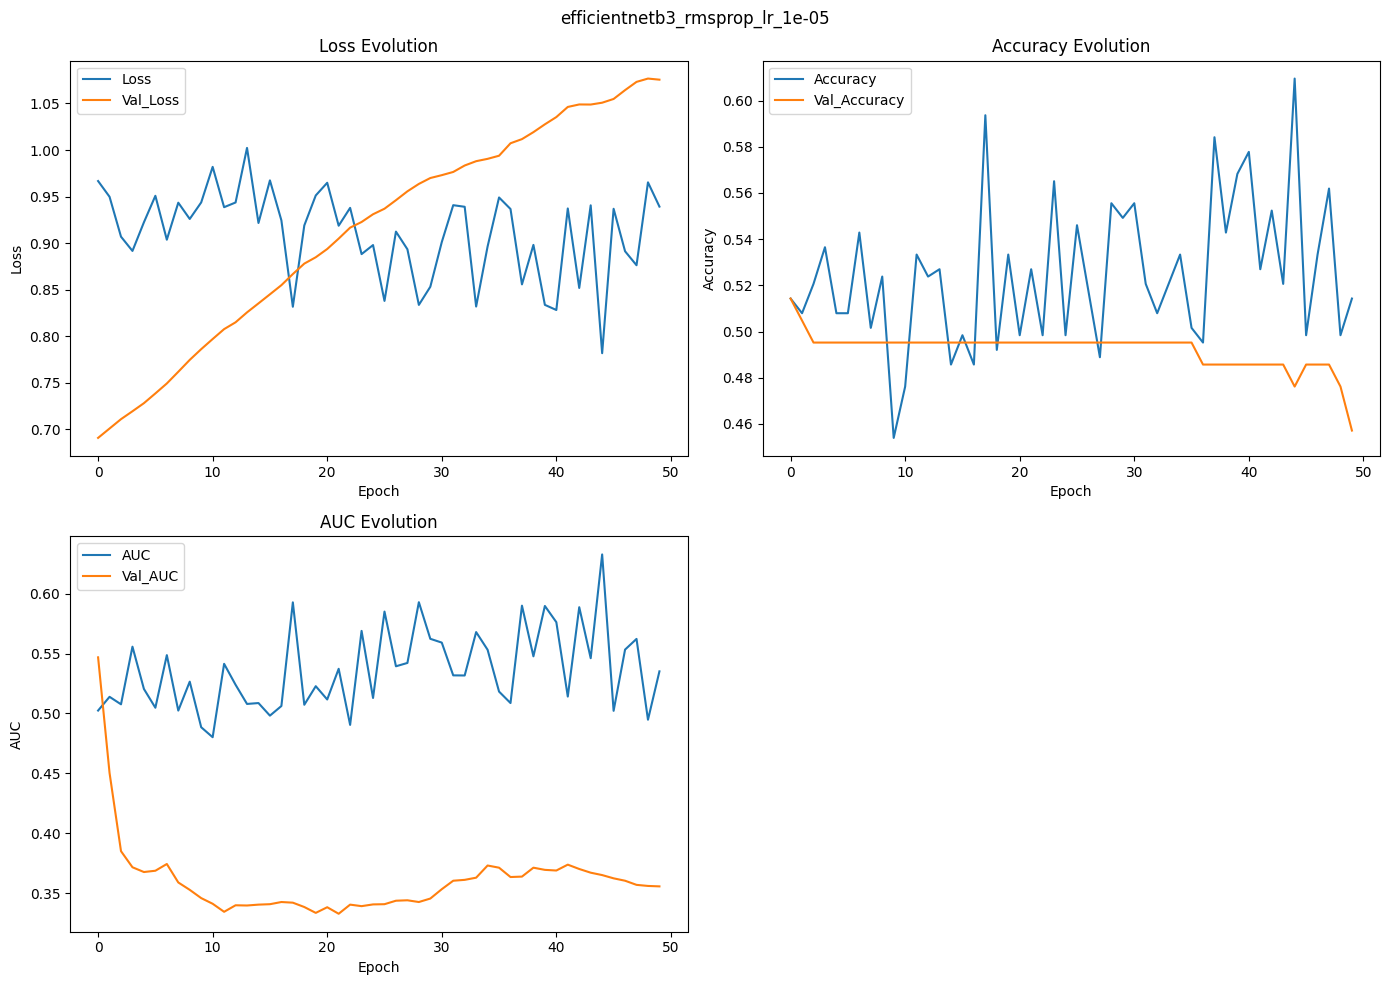

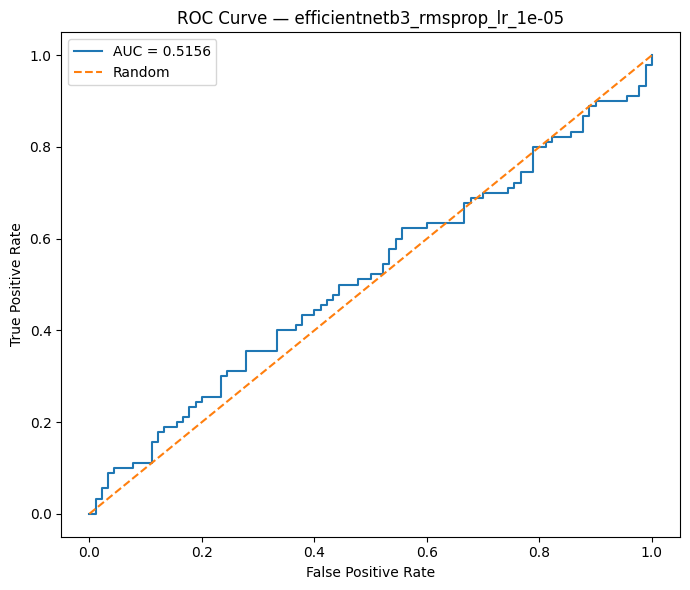

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,83,7
Actual With Disease,80,10


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,efficientnetb3,rmsprop,0.00001,0.516667,0.588235,0.111111,0.922222,0.186916,0.515556,83,7,80,10,outputs_efficientnetb3\plots\efficientnetb3_rm...,outputs_efficientnetb3\plots\efficientnetb3_rm...,outputs_efficientnetb3\reports\efficientnetb3_...,outputs_efficientnetb3\confusion_matrices\effi...


,precision,recall,f1-score,support
Without Disease,0.509202,0.922222,0.656126,90.000000
With Disease,0.588235,0.111111,0.186916,90.000000
accuracy,0.516667,0.516667,0.516667,0.516667
macro avg,0.548719,0.516667,0.421521,180.000000
weighted avg,0.548719,0.516667,0.421521,180.000000


Incomplete or missing run, will run: efficientnetb3_rmsprop_lr_1e-06
Missing: outputs_efficientnetb3\plots\efficientnetb3_rmsprop_lr_1e-06_history.png
Missing: outputs_efficientnetb3\plots\efficientnetb3_rmsprop_lr_1e-06_roc.png
Missing: outputs_efficientnetb3\reports\efficientnetb3_rmsprop_lr_1e-06_classification_report.csv
Missing: outputs_efficientnetb3\confusion_matrices\efficientnetb3_rmsprop_lr_1e-06_confusion_matrix.csv

Running: efficientnetb3_rmsprop_lr_1e-06
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 66s 5s/step - accuracy: 0.5111 - auc: 0.4920 - loss: 0.9614 - precision: 0.5128 - recall: 0.5063 - val_accuracy: 0.5524 - val_auc: 0.5931 - val_loss: 0.6883 - val_precision: 0.6667 - val_recall: 0.1923
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 40s 4s/step - accuracy: 0.4952 - auc: 0.4980 - loss: 0.9410 - precision: 0.4966 - recall: 0.4620 - val_accuracy: 0.4857 - val_auc: 0.4501 - val_loss: 0.6998 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 4

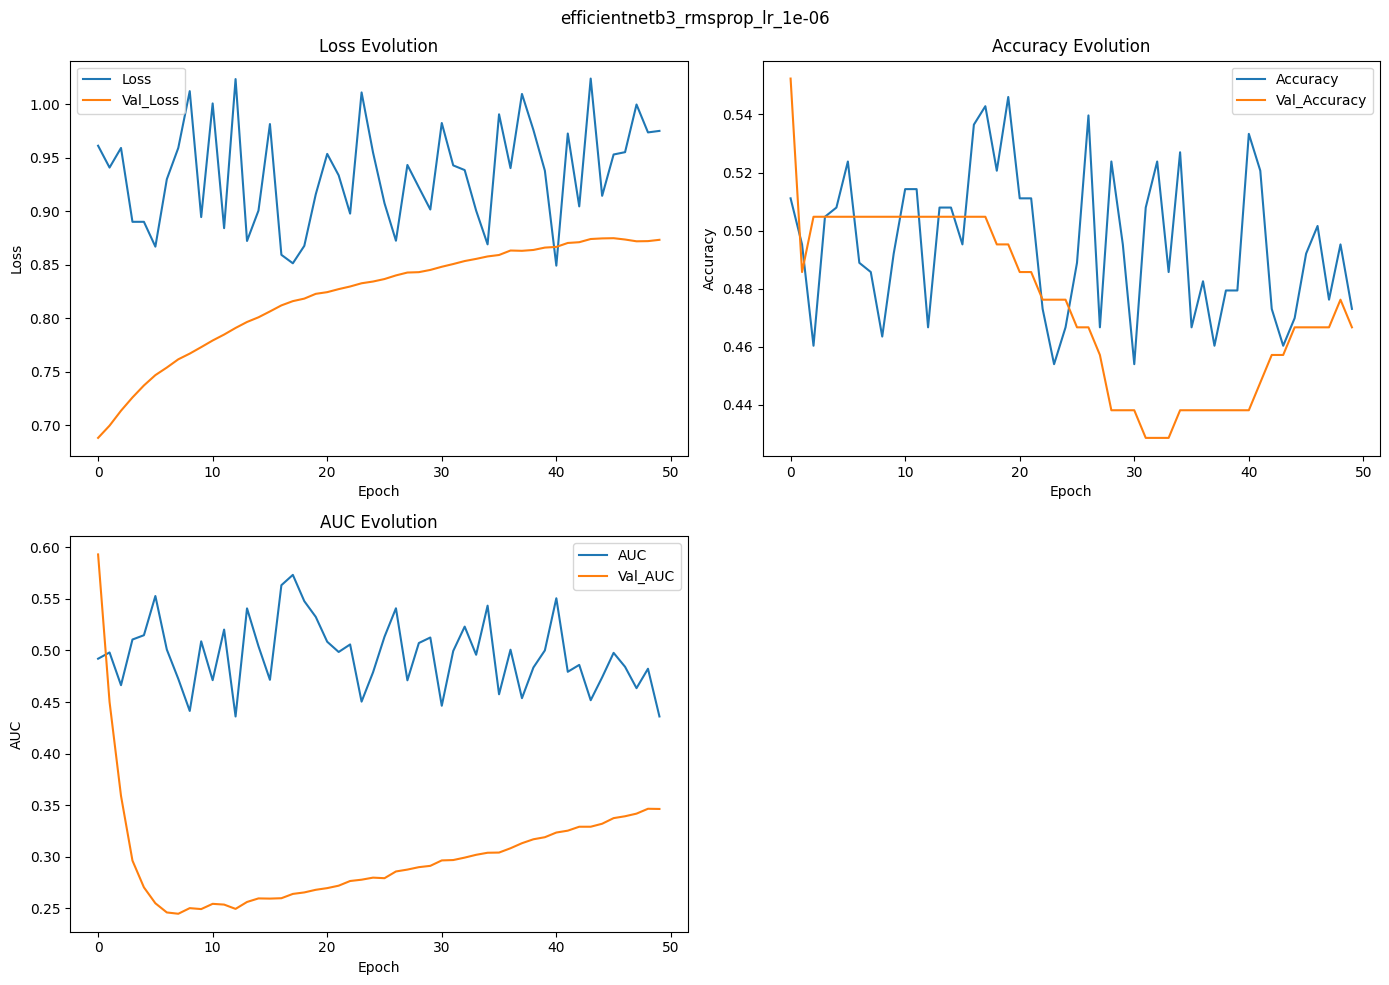

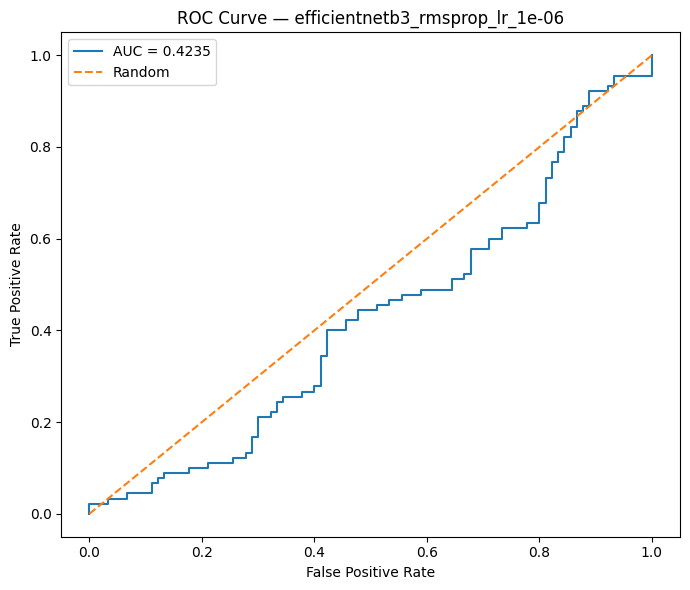

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,8,82
Actual With Disease,7,83


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,efficientnetb3,rmsprop,0.000001,0.505556,0.50303,0.922222,0.088889,0.65098,0.423457,8,82,7,83,outputs_efficientnetb3\plots\efficientnetb3_rm...,outputs_efficientnetb3\plots\efficientnetb3_rm...,outputs_efficientnetb3\reports\efficientnetb3_...,outputs_efficientnetb3\confusion_matrices\effi...


,precision,recall,f1-score,support
Without Disease,0.533333,0.088889,0.152381,90.000000
With Disease,0.503030,0.922222,0.650980,90.000000
accuracy,0.505556,0.505556,0.505556,0.505556
macro avg,0.518182,0.505556,0.401681,180.000000
weighted avg,0.518182,0.505556,0.401681,180.000000


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,efficientnetb3,adam,0.000100,0.583333,0.627119,0.411111,0.755556,0.496644,0.602222,68,22,53,37,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\reports\efficientnetb3_...,outputs_efficientnetb3\confusion_matrices\effi...
1,efficientnetb3,adam,0.000010,0.538889,0.557377,0.377778,0.700000,0.450331,0.591358,63,27,56,34,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\reports\efficientnetb3_...,outputs_efficientnetb3\confusion_matrices\effi...
2,efficientnetb3,adam,0.000001,0.544444,0.534483,0.688889,0.400000,0.601942,0.532963,36,54,28,62,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\reports\efficientnetb3_...,outputs_efficientnetb3\confusion_matrices\effi...
3,efficientnetb3,adagrad,0.000100,0.561111,0.544000,0.755556,0.366667,0.632558,0.538642,33,57,22,68,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\reports\efficientnetb3_...,outputs_efficientnetb3\confusion_matrices\effi...
4,efficientnetb3,adagrad,0.000010,0.483333,0.459459,0.188889,0.777778,0.267717,0.402099,70,20,73,17,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\reports\efficientnetb3_...,outputs_efficientnetb3\confusion_matrices\effi...
5,efficientnetb3,adagrad,0.000001,0.577778,0.625000,0.388889,0.766667,0.479452,0.584444,69,21,55,35,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\reports\efficientnetb3_...,outputs_efficientnetb3\confusion_matrices\effi...
6,efficientnetb3,adamax,0.000100,0.533333,0.527273,0.644444,0.422222,0.580000,0.582593,38,52,32,58,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\reports\efficientnetb3_...,outputs_efficientnetb3\confusion_matrices\effi...
7,efficientnetb3,adamax,0.000010,0.488889,0.493421,0.833333,0.144444,0.619835,0.515432,13,77,15,75,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\reports\efficientnetb3_...,outputs_efficientnetb3\confusion_matrices\effi...
8,efficientnetb3,adamax,0.000001,0.538889,0.526316,0.777778,0.300000,0.627803,0.543086,27,63,20,70,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\reports\efficientnetb3_...,outputs_efficientnetb3\confusion_matrices\effi...
9,efficientnetb3,adadelta,0.000100,0.488889,0.487805,0.444444,0.533333,0.465116,0.468025,48,42,50,40,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\reports\efficientnetb3_...,outputs_efficientnetb3\confusion_matrices\effi...


Saved combined new results to: outputs_summaries\all_new_results_summary.csv


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,vgg19,adadelta,0.000010,0.527778,0.514970,0.955556,0.100000,0.669261,0.609630,9,81,4,86,outputs_vgg19\plots\vgg19_adadelta_lr_1e-05_hi...,outputs_vgg19\plots\vgg19_adadelta_lr_1e-05_ro...,outputs_vgg19\reports\vgg19_adadelta_lr_1e-05_...,outputs_vgg19\confusion_matrices\vgg19_adadelt...
1,vgg19,adadelta,0.000001,0.372222,0.350649,0.300000,0.444444,0.323353,0.358519,40,50,63,27,outputs_vgg19\plots\vgg19_adadelta_lr_1e-06_hi...,outputs_vgg19\plots\vgg19_adadelta_lr_1e-06_ro...,outputs_vgg19\reports\vgg19_adadelta_lr_1e-06_...,outputs_vgg19\confusion_matrices\vgg19_adadelt...
2,vgg19,sgd,0.000100,0.494444,0.496689,0.833333,0.155556,0.622407,0.573086,14,76,15,75,outputs_vgg19\plots\vgg19_sgd_lr_0p0001_histor...,outputs_vgg19\plots\vgg19_sgd_lr_0p0001_roc.png,outputs_vgg19\reports\vgg19_sgd_lr_0p0001_clas...,outputs_vgg19\confusion_matrices\vgg19_sgd_lr_...
3,vgg19,sgd,0.000010,0.472222,0.471910,0.466667,0.477778,0.469274,0.458395,43,47,48,42,outputs_vgg19\plots\vgg19_sgd_lr_1e-05_history...,outputs_vgg19\plots\vgg19_sgd_lr_1e-05_roc.png,outputs_vgg19\reports\vgg19_sgd_lr_1e-05_class...,outputs_vgg19\confusion_matrices\vgg19_sgd_lr_...
4,vgg19,sgd,0.000001,0.511111,0.508333,0.677778,0.344444,0.580952,0.527778,31,59,29,61,outputs_vgg19\plots\vgg19_sgd_lr_1e-06_history...,outputs_vgg19\plots\vgg19_sgd_lr_1e-06_roc.png,outputs_vgg19\reports\vgg19_sgd_lr_1e-06_class...,outputs_vgg19\confusion_matrices\vgg19_sgd_lr_...
5,vgg19,rmsprop,0.000100,0.700000,0.725000,0.644444,0.755556,0.682353,0.762716,68,22,32,58,outputs_vgg19\plots\vgg19_rmsprop_lr_0p0001_hi...,outputs_vgg19\plots\vgg19_rmsprop_lr_0p0001_ro...,outputs_vgg19\reports\vgg19_rmsprop_lr_0p0001_...,outputs_vgg19\confusion_matrices\vgg19_rmsprop...
6,vgg19,rmsprop,0.000010,0.616667,0.584000,0.811111,0.422222,0.679070,0.663086,38,52,17,73,outputs_vgg19\plots\vgg19_rmsprop_lr_1e-05_his...,outputs_vgg19\plots\vgg19_rmsprop_lr_1e-05_roc...,outputs_vgg19\reports\vgg19_rmsprop_lr_1e-05_c...,outputs_vgg19\confusion_matrices\vgg19_rmsprop...
7,vgg19,rmsprop,0.000001,0.505556,0.507463,0.377778,0.633333,0.433121,0.494444,57,33,56,34,outputs_vgg19\plots\vgg19_rmsprop_lr_1e-06_his...,outputs_vgg19\plots\vgg19_rmsprop_lr_1e-06_roc...,outputs_vgg19\reports\vgg19_rmsprop_lr_1e-06_c...,outputs_vgg19\confusion_matrices\vgg19_rmsprop...
8,efficientnetb3,adam,0.000100,0.583333,0.627119,0.411111,0.755556,0.496644,0.602222,68,22,53,37,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\reports\efficientnetb3_...,outputs_efficientnetb3\confusion_matrices\effi...
9,efficientnetb3,adam,0.000010,0.538889,0.557377,0.377778,0.700000,0.450331,0.591358,63,27,56,34,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\plots\efficientnetb3_ad...,outputs_efficientnetb3\reports\efficientnetb3_...,outputs_efficientnetb3\confusion_matrices\effi...


In [12]:
all_results = []

def get_run_name(model_name, optimizer_name, lr):
    return f"{model_name}_{optimizer_name}_lr_{lr:g}".replace(".", "p")


def run_outputs_exist(model_name, optimizer_name, lr):
    output_dir, plots_dir, reports_dir, confusion_dir = get_output_dirs(model_name)
    run_name = get_run_name(model_name, optimizer_name, lr)

    expected_files = [
        plots_dir / f"{run_name}_history.png",
        plots_dir / f"{run_name}_roc.png",
        reports_dir / f"{run_name}_classification_report.csv",
        confusion_dir / f"{run_name}_confusion_matrix.csv",
    ]

    missing_files = [file for file in expected_files if not file.exists()]

    if missing_files:
        print(f"Incomplete or missing run, will run: {run_name}")
        for file in missing_files:
            print(f"Missing: {file}")
        return False

    return True


for model_name in MODELS_TO_RUN:
    model_results = []

    output_dir, plots_dir, reports_dir, confusion_dir = get_output_dirs(model_name)

    for optimizer_name in OPTIMIZERS:
        for lr in LEARNING_RATES:
            run_name = get_run_name(model_name, optimizer_name, lr)

            if run_outputs_exist(model_name, optimizer_name, lr):
                print(f"Skipping completed run: {run_name}")
                continue

            result = run_experiment(model_name, optimizer_name, lr)
            model_results.append(result)
            all_results.append(result)

            partial_results_df = pd.DataFrame(model_results)
            partial_results_df.to_csv(
                output_dir / f"{model_name}_partial_results_summary.csv",
                index=False,
            )

    if model_results:
        model_results_df = pd.DataFrame(model_results)
        model_results_df.to_csv(
            output_dir / f"{model_name}_new_results_summary.csv",
            index=False,
        )
        display(model_results_df)

all_results_df = pd.DataFrame(all_results)

if not all_results_df.empty:
    combined_path = SUMMARY_DIR / "all_new_results_summary.csv"
    all_results_df.to_csv(combined_path, index=False)
    print(f"Saved combined new results to: {combined_path}")
    display(all_results_df)
else:
    print("No new runs were performed. All expected output files already exist.")


## Best Run Summary

This summary uses only the runs performed in the current session. If all runs were skipped because output files already exist, no new summary table will be displayed here.


In [13]:
if "all_results_df" in globals() and not all_results_df.empty:
    best_by_auc = all_results_df.sort_values("auc", ascending=False).head(1)
    best_by_accuracy = all_results_df.sort_values("accuracy", ascending=False).head(1)

    print("Best new run by AUC:")
    display(best_by_auc)

    print("Best new run by Accuracy:")
    display(best_by_accuracy)
else:
    print("No new results in this session. Check the model-specific output folders for existing completed runs.")


Best new run by AUC:


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
5,vgg19,rmsprop,0.0001,0.7,0.725,0.644444,0.755556,0.682353,0.762716,68,22,32,58,outputs_vgg19\plots\vgg19_rmsprop_lr_0p0001_hi...,outputs_vgg19\plots\vgg19_rmsprop_lr_0p0001_ro...,outputs_vgg19\reports\vgg19_rmsprop_lr_0p0001_...,outputs_vgg19\confusion_matrices\vgg19_rmsprop...


Best new run by Accuracy:


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
5,vgg19,rmsprop,0.0001,0.7,0.725,0.644444,0.755556,0.682353,0.762716,68,22,32,58,outputs_vgg19\plots\vgg19_rmsprop_lr_0p0001_hi...,outputs_vgg19\plots\vgg19_rmsprop_lr_0p0001_ro...,outputs_vgg19\reports\vgg19_rmsprop_lr_0p0001_...,outputs_vgg19\confusion_matrices\vgg19_rmsprop...
